<a href="https://colab.research.google.com/github/LinaGarcia1/ProyectoGrado_MCIC-UD/blob/main/Codigos%20/Cauca/Tratamiento_Precipitacion_Humedad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TRATAMIENTO CATALOGO DE DESLIZAMIENTOS**

In [ ]:
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio folium

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install geopandas
import geopandas as gpd
import pandas as pd


In [ ]:
RUTA_CATALOGO = '/content/drive/MyDrive/TESIS /CATALOGODESLIZAMIENTO/Catalogo_Cauca_D.shp'

In [ ]:
# Cargar el shapefile
gdfcatalogo = gpd.read_file(RUTA_CATALOGO)

# Ver primeras filas para confirmar el nombre de la columna de códigos
gdfcatalogo.head()


,Código_SI,Tipo_de_mo,Fecha_even,Departamen,Municipio,Vereda,Subtipo_de,Fecha_dili,Institucii,Sitio,Latitud__i,Longitud__,Altura__ms,Fecha_repo,geometry
0,50013,Deslizamiento,2000-01-01,CAUCA,CAJIBÍO,CAJIBÍO,None,2020-07-20,Universidad del Cauca,centroide,2.681106,-76.831350,0,2020-09-23,POINT (-76.83135 2.68111)
1,54205,Deslizamiento,2000-01-01,CAUCA,SOTARÁ (Paispamba),PIEDRELEON,Deslizamiento traslacional,2021-04-15,Universidad del Cauca,Corona,2.399769,-76.566936,1999,2020-09-16,POINT (-76.56694 2.39977)
2,54335,Deslizamiento,2000-01-01,CAUCA,LA SIERRA,LA SIERRA,Deslizamiento traslacional,2021-04-17,Universidad del Cauca,Centroide,2.159980,-76.766457,1595,2020-11-09,POINT (-76.76646 2.15998)
3,54267,Deslizamiento,2000-01-01,CAUCA,SOTARÁ (Paispamba),EL CRUCERO,Deslizamiento traslacional,2021-04-16,Universidad del Cauca,Corona,2.046192,-76.589732,2556,2020-09-19,POINT (-76.58973 2.04619)
4,50070,Deslizamiento,2000-01-01,CAUCA,SOTARÁ (Paispamba),CHAPA,Deslizamiento traslacional,2020-07-20,Universidad del Cauca,Cuerpo,2.253872,-76.602719,2665,2020-11-12,POINT (-76.60272 2.25387)


In [ ]:
# Contar cuántas veces aparece cada código
duplicados = gdfcatalogo.groupby("Código_SI").size().reset_index(name="Repeticiones")

# Filtrar solo los que tienen más de 1 repetición
duplicados = duplicados[duplicados["Repeticiones"] > 1]

# Mostrar resultados
duplicados


,Código_SI,Repeticiones
450,48955,2
451,48956,2
466,49052,2
482,49155,2
516,49538,2
530,49963,2
783,54108,2
808,54229,2
810,54232,2
849,54320,2


In [ ]:
# Eliminar duplicados conservando el primer registro encontrado
gdf_unicos = gdfcatalogo.drop_duplicates(subset=["Código_SI"], keep="first")

# Verificar cuántos registros quedaron
print(f"Registros originales: {len(gdfcatalogo)}")
print(f"Registros después de eliminar duplicados: {len(gdf_unicos)}")


Registros originales: 1610
Registros después de eliminar duplicados: 1592


In [ ]:
import os
import shutil
from google.colab import files

# Crear una carpeta temporal para guardar el shapefile limpio
output_folder = "shapefile_catalogo"
os.makedirs(output_folder, exist_ok=True)

# Convert date columns to string format for compatibility with shapefile
for col in ['Fecha_even', 'Fecha_dili', 'Fecha_repo']:
    if col in gdf_unicos.columns:
        # Convert to datetime first to handle potential mixed types, then to string
        gdf_unicos[col] = pd.to_datetime(gdf_unicos[col], errors='coerce').dt.strftime('%Y-%m-%d')
        # Fill potential NaT values (from coercion errors) with empty string or a placeholder
        gdf_unicos[col] = gdf_unicos[col].fillna('')


# Guardar shapefile sin duplicados dentro de la carpeta
output_path = os.path.join(output_folder, "Catalogo_CaucaD.shp")
gdf_unicos.to_file(output_path)

# Crear un ZIP con todos los componentes del shapefile
shutil.make_archive("Catalogo_CaucaD", "zip", output_folder)

# Descargar el ZIP completo
files.download("Catalogo_CaucaD.zip")

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
RUTACTL='/content/drive/MyDrive/TESIS /DESLIZAMIENTOCORDENADASF.csv'

# **Creación de tabla de fechas de acuerdo al dia del evento de deslizamiento de tierra**

**Se construirá guía de fechas, en donde se calcularan los raster de interpolación asociados a la precipitación **

In [ ]:
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio folium

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install geopandas
import geopandas as gpd
import pandas as pd


In [ ]:
Ruta_fechaeventos= '/content/drive/MyDrive/TESIS /FechasEventos.xlsx'

In [ ]:
#Carga tabla desde archivo excel
dfeventos= pd.read_excel(Ruta_fechaeventos)
dfeventos.head()

,Código_SIMMA,Fecha_even,Latitud__i,Longitud__
0,55482,2005-01-01,2.810006,-76.597045
1,55676,2005-01-01,2.740224,-76.567226
2,54533,2005-01-01,2.363611,-76.593889
3,55569,2005-01-01,2.700306,-76.715197
4,54265,2005-01-01,2.367753,-76.587750


In [ ]:
dfeventos['Fecha_even'] = pd.to_datetime(dfeventos['Fecha_even'], errors='coerce')

# 5. Crear columnas con fechas relativas teniendo en cuenta las ventanas temporales
dfeventos['Fecha_t0_1d']   = dfeventos['Fecha_even'] - pd.to_timedelta(1, unit='D')
dfeventos['Fecha_t0_3d']   = dfeventos['Fecha_even'] - pd.to_timedelta(3, unit='D')
dfeventos['Fecha_t0_5d']   = dfeventos['Fecha_even'] - pd.to_timedelta(5, unit='D')
dfeventos['Fecha_t0_7d']   = dfeventos['Fecha_even'] - pd.to_timedelta(7, unit='D')
dfeventos['Fecha_t0_15d']  = dfeventos['Fecha_even'] - pd.to_timedelta(15, unit='D')
dfeventos['Fecha_t0_30d']  = dfeventos['Fecha_even'] - pd.to_timedelta(30, unit='D')
dfeventos['Fecha_t0_180d'] = dfeventos['Fecha_even'] - pd.to_timedelta(180, unit='D')

In [ ]:
dfeventos.head(20)

,Código_SIMMA,Fecha_even,Latitud__i,Longitud__,Fecha_t0_1d,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d
0,55482,2005-01-01,2.810006,-76.597045,2004-12-31,2004-12-29,2004-12-27,2004-12-25,2004-12-17,2004-12-02,2004-07-05
1,55676,2005-01-01,2.740224,-76.567226,2004-12-31,2004-12-29,2004-12-27,2004-12-25,2004-12-17,2004-12-02,2004-07-05
2,54533,2005-01-01,2.363611,-76.593889,2004-12-31,2004-12-29,2004-12-27,2004-12-25,2004-12-17,2004-12-02,2004-07-05
3,55569,2005-01-01,2.700306,-76.715197,2004-12-31,2004-12-29,2004-12-27,2004-12-25,2004-12-17,2004-12-02,2004-07-05
4,54265,2005-01-01,2.367753,-76.587750,2004-12-31,2004-12-29,2004-12-27,2004-12-25,2004-12-17,2004-12-02,2004-07-05
5,54532,2005-01-01,2.381772,-76.615622,2004-12-31,2004-12-29,2004-12-27,2004-12-25,2004-12-17,2004-12-02,2004-07-05
6,54373,2005-01-01,2.193406,-76.795322,2004-12-31,2004-12-29,2004-12-27,2004-12-25,2004-12-17,2004-12-02,2004-07-05
7,49302,2005-01-01,2.723067,-76.771953,2004-12-31,2004-12-29,2004-12-27,2004-12-25,2004-12-17,2004-12-02,2004-07-05
8,54622,2005-01-01,2.611879,-76.719124,2004-12-31,2004-12-29,2004-12-27,2004-12-25,2004-12-17,2004-12-02,2004-07-05
9,54234,2005-01-01,2.256830,-76.669605,2004-12-31,2004-12-29,2004-12-27,2004-12-25,2004-12-17,2004-12-02,2004-07-05


In [ ]:
dfeventos = dfeventos[dfeventos['Fecha_t0_180d'] >= pd.Timestamp('2005-01-01')]


In [ ]:
dfeventos.tail(20)

,Código_SIMMA,Fecha_even,Latitud__i,Longitud__,Fecha_t0_1d,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d
1523,67578,2024-06-23,1.784000,-77.275000,2024-06-22,2024-06-20,2024-06-18,2024-06-16,2024-06-08,2024-05-24,2023-12-26
1524,70253,2024-12-06,2.405000,-76.505000,2024-12-05,2024-12-03,2024-12-01,2024-11-29,2024-11-21,2024-11-06,2024-06-09
1525,70265,2024-12-20,2.936000,-76.527000,2024-12-19,2024-12-17,2024-12-15,2024-12-13,2024-12-05,2024-11-20,2024-06-23
1526,70306,2025-01-04,1.818000,-76.978000,2025-01-03,2025-01-01,2024-12-30,2024-12-28,2024-12-20,2024-12-05,2024-07-08
1527,70312,2025-01-05,2.110667,-76.998000,2025-01-04,2025-01-02,2024-12-31,2024-12-29,2024-12-21,2024-12-06,2024-07-09
1528,70311,2025-01-05,2.132483,-77.046716,2025-01-04,2025-01-02,2024-12-31,2024-12-29,2024-12-21,2024-12-06,2024-07-09
1529,70317,2025-01-07,2.552000,-76.566000,2025-01-06,2025-01-04,2025-01-02,2024-12-31,2024-12-23,2024-12-08,2024-07-11
1530,70325,2025-01-09,2.132000,-76.776000,2025-01-08,2025-01-06,2025-01-04,2025-01-02,2024-12-25,2024-12-10,2024-07-13
1531,70328,2025-01-10,2.656000,-76.536000,2025-01-09,2025-01-07,2025-01-05,2025-01-03,2024-12-26,2024-12-11,2024-07-14
1532,70332,2025-01-12,1.397000,-76.513000,2025-01-11,2025-01-09,2025-01-07,2025-01-05,2024-12-28,2024-12-13,2024-07-16


In [ ]:
dfeventos1 = dfeventos[dfeventos['Fecha_even'] <= pd.Timestamp('2025-01-20')]


In [ ]:
print("Fecha máxima en df:", dfeventos['Fecha_even'].max())

Fecha máxima en df: 2025-04-30 00:00:00


In [ ]:
len(dfeventos1)

1517

In [ ]:
import os

output_dir = '/content/drive/MyDrive/TESIS/salida'
output_csv_path = os.path.join(output_dir, 'dfeventos1.csv')

# Save the DataFrame to a CSV file
dfeventos1.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"DataFrame saved successfully to: {output_csv_path}")

DataFrame saved successfully to: /content/drive/MyDrive/TESIS/salida/dfeventos1.csv


## **TRATAMIENTO PRECIPITACION**

Inicialmente se revisan los diferentes tipos de mediciones relacionadas con la
precipitación en donde, aunque hay una que representa la precipitación mensual, solo esta presente desde el 2012 en adelante y solo se cuenta con información en 5 de las 65 estaciones.
Por lo tanto, se decide utilizar los valores del día pluviometrico y sumarlos para conseguir así el acumulado mensual filtrando en un inicio de 1990 en adelante; sin embargo por la relación con otros datos

In [ ]:
RUTA_SHAPE = '/content/drive/MyDrive/TESIS /ESTACIONES_IDEAM_CAUCA.shp'
RUTA_CSV   = '/content/drive/MyDrive/TESIS /datos_precipitacion.csv'


In [ ]:
import geopandas as gpd
import pandas as pd

# Lee shapefile; geopandas detecta automáticamente el CRS
gdf = gpd.read_file(RUTA_SHAPE)


# Lee tabla de precipitaciones
df = pd.read_csv(RUTA_CSV)


In [ ]:
df.head(30)

,Fecha,Precipitacion,EstacionGrupo,EstacionID
29572,1959-01-01 07:00:00,0.0,PTPM_CON,21050070
29573,1959-01-02 07:00:00,0.0,PTPM_CON,21050070
29574,1959-01-03 07:00:00,0.0,PTPM_CON,21050070
29575,1959-01-04 07:00:00,0.0,PTPM_CON,21050070
29576,1959-01-05 07:00:00,0.0,PTPM_CON,21050070
29577,1959-01-06 07:00:00,0.0,PTPM_CON,21050070
29578,1959-01-07 07:00:00,0.0,PTPM_CON,21050070
29579,1959-01-08 07:00:00,0.0,PTPM_CON,21050070
29580,1959-01-09 07:00:00,0.0,PTPM_CON,21050070
29581,1959-01-10 07:00:00,0.0,PTPM_CON,21050070


In [ ]:
# Número de estaciones únicas por cada EstacionGrupo
conteo_estaciones = df.groupby('EstacionGrupo')['EstacionID'].nunique().reset_index()
conteo_estaciones.rename(columns={'EstacionID':'n_estaciones'}, inplace=True)

print(conteo_estaciones)


  EstacionGrupo  n_estaciones
0     PTPG_MX_D             5
1     PTPG_MX_M             5
2  PTPG_MX_TT_M             5
3     PTPG_TT_D             5
4     PTPG_TT_M             5
5      PTPM_CON            65
6  PTPM_MX_TT_M            65
7     PTPM_TT_M            65
8     PT_AUT_10             1


In [ ]:
resumen = (
    df.groupby('EstacionGrupo')
      .agg(
          n_estaciones = ('EstacionID', 'nunique'),
          n_registros  = ('EstacionID', 'size'),
          fecha_min    = ('Fecha', 'min'),
          fecha_max    = ('Fecha', 'max')
      )
      .reset_index()
)

print(resumen)


  EstacionGrupo  n_estaciones  n_registros            fecha_min  \
0     PTPG_MX_D             5        11523  2012-11-01 07:00:00   
1     PTPG_MX_M             5          413  2012-11-01 00:00:00   
2  PTPG_MX_TT_M             5          544  2012-11-01 00:00:00   
3     PTPG_TT_D             5        16548  2012-11-01 07:00:00   
4     PTPG_TT_M             5          544  2012-11-01 00:00:00   
5      PTPM_CON            65      1081876  1947-01-01 07:00:00   
6  PTPM_MX_TT_M            65        35603  1947-01-01 00:00:00   
7     PTPM_TT_M            65        37204  1947-01-01 00:00:00   
8     PT_AUT_10             1       204058  2017-04-29 17:50:00   

             fecha_max  
0  2024-12-31 07:00:00  
1  2024-12-01 00:00:00  
2  2024-12-01 00:00:00  
3  2024-12-31 07:00:00  
4  2024-12-01 00:00:00  
5  2025-01-22 07:00:00  
6  2025-01-01 00:00:00  
7  2025-01-01 00:00:00  
8  2022-10-19 05:00:00  


In [ ]:
# Primeras filas de la tabla de atributos
gdf.head(3)

,OBJECTID_1,CODIGO,nombre,CATEGORIA,TECNOLOGIA,ESTADO,FECHA_INST,altitud,latitud,longitud,...,AREA_OPERA,AREA_HIDRO,ZONA_HIDRO,observacio,CORRIENTE,FECHA_SUSP,SUBZONA_HI,ENTIDAD,subred,geometry
0,935,26010030,PURACE [26010030],Pluviométrica,Convencional,Activa,1959-05-15,2652,2.380861,-76.454778,...,Area Operativa 09 - Cauca-Valle-Caldas,Magdalena Cauca,Cauca,None,Negro,None,Alto Río Cauca,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,"Altiplano Nariñense-Pacifico,RED ALERTAS - ARE...",POINT (-76.45478 2.38086)
1,940,21050310,ESCUELA RIOSUCIO 2 [21050310],Pluviométrica,Convencional,Activa,1983-10-15,2750,2.446833,-76.168917,...,Area Operativa 04 - Huila-Caquetá,Magdalena Cauca,Alto Magdalena,None,Guayabero,None,Río Páez,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,None,POINT (-76.16892 2.44683)
2,946,26030050,TAMBO [26030050],Pluviométrica,Convencional,Activa,1953-01-15,1742,2.455972,-76.811111,...,Area Operativa 09 - Cauca-Valle-Caldas,Magdalena Cauca,Cauca,None,Aguacolorada,None,Rio Salado y otros directos Cauca,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,"Altiplano Nariñense-Pacifico,RED ALERTAS - ARE...",POINT (-76.81111 2.45597)


In [ ]:
# Columnas disponibles
gdf.columns


Index(['OBJECTID_1', 'CODIGO', 'nombre', 'CATEGORIA', 'TECNOLOGIA', 'ESTADO',
       'FECHA_INST', 'altitud', 'latitud', 'longitud', 'DEPARTAMEN',
       'MUNICIPIO', 'AREA_OPERA', 'AREA_HIDRO', 'ZONA_HIDRO', 'observacio',
       'CORRIENTE', 'FECHA_SUSP', 'SUBZONA_HI', 'ENTIDAD', 'subred',
       'geometry'],
      dtype='object')

In [ ]:
# Información general
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1388313 entries, 0 to 1388312
Data columns (total 4 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   Fecha          1388313 non-null  object 
 1   Precipitacion  1388313 non-null  float64
 2   EstacionGrupo  1388313 non-null  object 
 3   EstacionID     1388313 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 42.4+ MB


In [ ]:
tipos_validos = ['PTPM_CON']  # Día Pluviométrico

# Dejar solo los tipos indicados (si tu CSV tiene más códigos)
df = df[df['EstacionGrupo'].isin(tipos_validos)].copy()

# Normalizar tipos (optimiza memoria y joins)
df['EstacionGrupo'] = df['EstacionGrupo'].astype('category')
df['EstacionID']   = df['EstacionID'].astype('category')

In [ ]:
df.head(5)

,Fecha,Precipitacion,EstacionGrupo,EstacionID
29572,1959-01-01 07:00:00,0.0,PTPM_CON,21050070
29573,1959-01-02 07:00:00,0.0,PTPM_CON,21050070
29574,1959-01-03 07:00:00,0.0,PTPM_CON,21050070
29575,1959-01-04 07:00:00,0.0,PTPM_CON,21050070
29576,1959-01-05 07:00:00,0.0,PTPM_CON,21050070


In [ ]:
# Fecha mínima y máxima en tu DataFrame
print("Fecha mínima:", df['Fecha'].min())
print("Fecha máxima:", df['Fecha'].max())

Fecha mínima: 1947-01-01 07:00:00
Fecha máxima: 2025-01-22 07:00:00


In [ ]:
# 1. Asegura que Fecha sea datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# Select relevant columns from gdf and rename 'CODIGO' to 'EstacionID'
gdf_subsetdias = gdf[['CODIGO', 'nombre', 'geometry']].rename(columns={'CODIGO': 'EstacionID'})

# Merge df with the modified gdf subset
gjoindias = pd.merge(
    gdf_subsetdias, # Added comma here
    df,
    on='EstacionID',
    how='inner'
)


gjoindias = gjoindias[gjoindias['Fecha'] >= pd.Timestamp('2005-01-01')]

# Display the first few rows of the merged dataframe
display(gjoindias.head())



,EstacionID,nombre,geometry,Fecha,Precipitacion,EstacionGrupo
16518,26010030,PURACE [26010030],POINT (-76.45478 2.38086),2005-01-01 07:00:00,0.0,PTPM_CON
16519,26010030,PURACE [26010030],POINT (-76.45478 2.38086),2005-01-02 07:00:00,0.0,PTPM_CON
16520,26010030,PURACE [26010030],POINT (-76.45478 2.38086),2005-01-03 07:00:00,0.0,PTPM_CON
16521,26010030,PURACE [26010030],POINT (-76.45478 2.38086),2005-01-04 07:00:00,5.0,PTPM_CON
16522,26010030,PURACE [26010030],POINT (-76.45478 2.38086),2005-01-05 07:00:00,0.0,PTPM_CON


In [ ]:
print("Fecha máxima en df:", gjoindias['Fecha'].max())

Fecha máxima en df: 2025-01-22 07:00:00


In [ ]:
gdf_subsetdias.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   EstacionID  65 non-null     int64   
 1   nombre      65 non-null     object  
 2   geometry    65 non-null     geometry
dtypes: geometry(1), int64(1), object(1)
memory usage: 1.7+ KB


**gjoindias:** Es un archivo de tipo csv que contiene información de precipitación junto con geometría, nombre y codigo de estaciones.

In [ ]:
import os

output_dir = '/content/drive/MyDrive/TESIS/salida'
output_csv_path = os.path.join(output_dir, 'gjoindias.csv')

# Save the DataFrame to a CSV file
gjoindias.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"DataFrame saved successfully to: {output_csv_path}")

DataFrame saved successfully to: /content/drive/MyDrive/TESIS/salida/gjoindias.csv


In [ ]:
import os

gpkg_path = os.path.join('/content/drive/MyDrive/TESIS/salida', 'precipitacion_diaria.gpkg')

# Define the layer name
layer_name = 'precipitacion_diaria'

gjoindias.to_file(
    gpkg_path, layer=layer_name, driver='GPKG'
)

Aunque se tomará la información diaria para la interpolación, se estudia como es el comportamiento anual y mensual de la precipitación.

In [ ]:
# 1. Asegura que Fecha sea datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# 2. Crear columna año-mes
df['YYYYMM'] = df['Fecha'].dt.to_period('M')

# 3. Agrupar por estación y mes, sumando la precipitación
mensual = (
    df.groupby(['EstacionID','YYYYMM'], observed=True)['Precipitacion']
      .sum()
      .reset_index()
      .rename(columns={'Precipitacion':'Precipitacion_mensual'})
)

# 4. Convertir YYYYMM a fecha (primer día del mes) si lo prefieres
mensual['Fecha'] = mensual['YYYYMM'].dt.to_timestamp()

print(mensual.head())

  EstacionID   YYYYMM  Precipitacion_mensual      Fecha
0   21050070  1959-01                   10.0 1959-01-01
1   21050070  1959-02                   29.0 1959-02-01
2   21050070  1959-03                   80.0 1959-03-01
3   21050070  1959-04                  122.0 1959-04-01
4   21050070  1959-05                  183.0 1959-05-01


In [ ]:
mensual.head()

,EstacionID,YYYYMM,Precipitacion_mensual,Fecha
0,21050070,1959-01,10.0,1959-01-01
1,21050070,1959-02,29.0,1959-02-01
2,21050070,1959-03,80.0,1959-03-01
3,21050070,1959-04,122.0,1959-04-01
4,21050070,1959-05,183.0,1959-05-01


In [ ]:
mensual = mensual[mensual['Fecha'] >= pd.Timestamp('2000-01-01')]


In [ ]:
# Select relevant columns from gdf and rename 'CODIGO' to 'EstacionID'
gdf_subset = gdf[['CODIGO', 'nombre', 'geometry']].rename(columns={'CODIGO': 'EstacionID'})

# Merge df with the modified gdf subset
gjoin = pd.merge(
    gdf_subset,
    mensual,
    on='EstacionID',
    how='inner'
)

# Display the first few rows of the merged dataframe
display(gjoin.head())

,EstacionID,nombre,geometry,YYYYMM,Precipitacion_mensual,Fecha
0,26010030,PURACE [26010030],POINT (-76.45478 2.38086),2000-01,414.0,2000-01-01
1,26010030,PURACE [26010030],POINT (-76.45478 2.38086),2000-02,158.0,2000-02-01
2,26010030,PURACE [26010030],POINT (-76.45478 2.38086),2000-03,140.0,2000-03-01
3,26010030,PURACE [26010030],POINT (-76.45478 2.38086),2000-04,55.0,2000-04-01
4,26010030,PURACE [26010030],POINT (-76.45478 2.38086),2000-05,62.0,2000-05-01


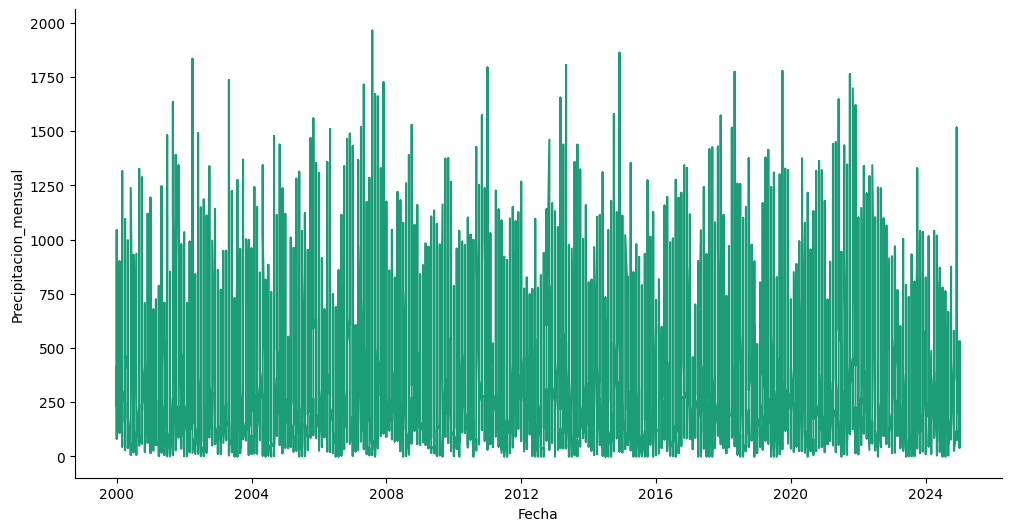

In [ ]:
# Histórico de precipitación mensual

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Fecha']
  ys = series['Precipitacion_mensual']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('Fecha', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Fecha')
_ = plt.ylabel('Precipitacion_mensual')

/tmp/ipython-input-948052539.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


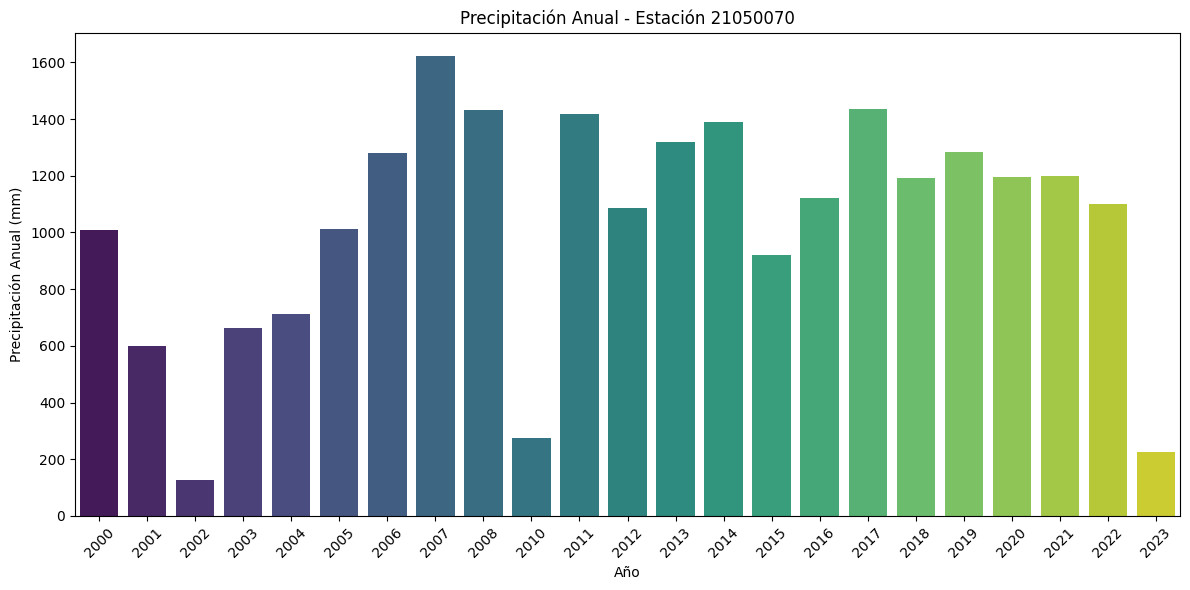

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estación específica
estacion_id = 21050070
gjoin_estacion = gjoin[gjoin['EstacionID'] == estacion_id]

# Agrupar por año y sumar la precipitación mensual
annual_precipitation = (
    gjoin_estacion
    .groupby(gjoin_estacion['Fecha'].dt.year)['Precipitacion_mensual']
    .sum()
    .reset_index()
)

# Renombrar la columna de año
annual_precipitation.rename(columns={'Fecha': 'Year'}, inplace=True)

# Graficar la precipitación anual para la estación seleccionada
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Year',
    y='Precipitacion_mensual',
    data=annual_precipitation,
    palette='viridis'
)

plt.xlabel('Año')
plt.ylabel('Precipitación Anual (mm)')
plt.title(f'Precipitación Anual - Estación {estacion_id}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import os

gpkg_path = os.path.join('/content/drive/MyDrive/TESIS/salida', 'precipitacion_mensualacumulada.gpkg')

# Define the layer name
layer_name = 'precipitacion_mensual'

gjoin.to_file(
    gpkg_path, layer=layer_name, driver='GPKG'
)

# **TRATAMIENTO HUMEDAD RELATIVA DEL SUELO Y TEMPERATURA DEL SUELO**

In [ ]:
!pip install geopandas
import geopandas as gpd
import pandas as pd


In [ ]:

from google.colab import drive
drive.mount('/content/drive')
RUTA_HUMEDAD = '/content/drive/MyDrive/TESIS /datos_humedad_Cauca.csv'
RUTA_SHAPE = '/content/drive/MyDrive/TESIS /IDEAM/catalogo_est_ideam.shp'
RUTA_HUMEDAD2 = '/content/drive/MyDrive/TESIS /humedad_suelo_unificado.csv'



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dfhumedad = pd.read_csv(RUTA_HUMEDAD)


In [ ]:
dfhumedad.head(5)

,Fecha,Humedad,EstacionGrupo,EstacionID
0,2005-11-24 00:00:00,69.770833,HRS30_MEDIA_D,21055070
1,2005-12-18 00:00:00,38.395833,HRS30_MEDIA_D,21055070
2,2005-12-19 00:00:00,72.562500,HRS30_MEDIA_D,21055070
3,2005-12-20 00:00:00,73.875000,HRS30_MEDIA_D,21055070
4,2005-12-21 00:00:00,74.000000,HRS30_MEDIA_D,21055070


In [ ]:
gdfestId= gpd.read_file(RUTA_SHAPE)

In [ ]:
gdfestId.head(3)

,Codigo,Nombre,Categoria,Tecnologia,Estado,Departamen,Municipio,Altitud,LONGITUD,LATITUD,Area_Opera,Corriente,Area_Hidro,Zona_Hidro,Subzona_hi,Entidad,geometry
0,21010240,VILLALOBOS TV [21010240],Pluviométrica,Convencional,Suspendida,Huila,Pitalito,2270,-76.233333,1.533333,Area Operativa 04 - Huila-Caquetá,None,Amazonas,Caquetá,Alto Caqueta,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (-76.23333 1.53333)
1,21050070,BELALCAZAR [21050070],Pluviométrica,Convencional,Activa,Cauca,Páez (Belalcázar),1439,-75.974972,2.657000,Area Operativa 04 - Huila-Caquetá,None,Magdalena Cauca,Alto Magdalena,Río Páez,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (-75.97497 2.657)
2,21050080,CAMP KM-48 [21050080],Pluviométrica,Convencional,Suspendida,Cauca,Inzá,3500,-76.200000,2.500000,Area Operativa 04 - Huila-Caquetá,None,Magdalena Cauca,Alto Magdalena,Río Páez,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (-76.2 2.5)


In [ ]:
# Columnas disponibles
gdfestId.columns

Index(['Codigo', 'Nombre', 'Categoria', 'Tecnologia', 'Estado', 'Departamen',
       'Municipio', 'Altitud', 'LONGITUD', 'LATITUD', 'Area_Opera',
       'Corriente', 'Area_Hidro', 'Zona_Hidro', 'Subzona_hi', 'Entidad',
       'geometry'],
      dtype='object')

In [ ]:
# Número de estaciones únicas por cada EstacionGrupo
conteo_estacionesh = dfhumedad.groupby('EstacionGrupo')['EstacionID'].nunique().reset_index()
conteo_estacionesh.rename(columns={'EstacionID':'n_estaciones'}, inplace=True)

print(conteo_estacionesh)


    EstacionGrupo  n_estaciones
0   HRS30_MEDIA_D            25
1      HRS30_MN_D            25
2      HRS30_MX_D            25
3   HRS50_MEDIA_D            17
4      HRS50_MN_D            17
5      HRS50_MX_D            17
6    TS10_MEDIA_D            16
7       TS10_MN_D            16
8       TS10_MX_D            16
9    TS30_MEDIA_D            16
10      TS30_MN_D            16
11      TS30_MX_D            16
12   TS50_MEDIA_D            16
13      TS50_MN_D            16
14      TS50_MX_D            16


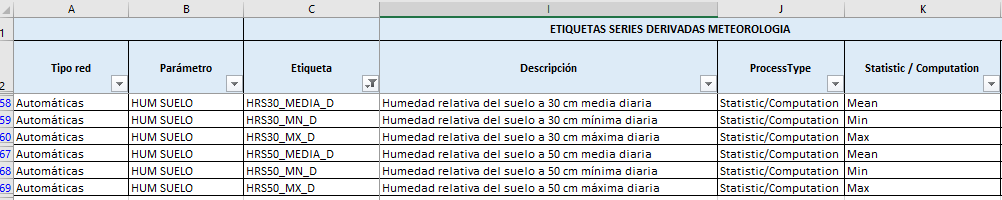

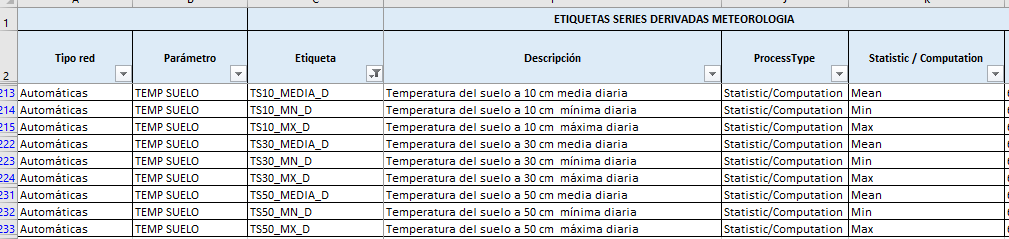

In [ ]:
resumenhumedad = (
    dfhumedad.groupby('EstacionGrupo')
      .agg(
          n_estaciones = ('EstacionID', 'nunique'),
          n_registros  = ('EstacionID', 'size'),
          fecha_min    = ('Fecha', 'min'),
          fecha_max    = ('Fecha', 'max')
      )
      .reset_index()
)

print(resumenhumedad)


    EstacionGrupo  n_estaciones  n_registros            fecha_min  \
0   HRS30_MEDIA_D            25        87559  2005-01-31 00:00:00   
1      HRS30_MN_D            25        87559  2005-01-31 00:00:00   
2      HRS30_MX_D            25        87559  2005-01-31 00:00:00   
3   HRS50_MEDIA_D            17        60617  2005-01-31 00:00:00   
4      HRS50_MN_D            17        60617  2005-01-31 00:00:00   
5      HRS50_MX_D            17        60617  2005-01-31 00:00:00   
6    TS10_MEDIA_D            16        60362  2005-01-31 00:00:00   
7       TS10_MN_D            16        60362  2005-01-31 00:00:00   
8       TS10_MX_D            16        60362  2005-01-31 00:00:00   
9    TS30_MEDIA_D            16        61088  2005-01-31 00:00:00   
10      TS30_MN_D            16        61088  2005-01-31 00:00:00   
11      TS30_MX_D            16        61088  2005-01-31 00:00:00   
12   TS50_MEDIA_D            16        57476  2005-01-13 00:00:00   
13      TS50_MN_D            16   

In [ ]:
dfhumedad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981306 entries, 0 to 981305
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Fecha          981306 non-null  object 
 1   Humedad        981306 non-null  float64
 2   EstacionGrupo  981306 non-null  object 
 3   EstacionID     981306 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 29.9+ MB


In [ ]:
Humedads = ['HRS30_MEDIA_D']
Temperaturas= ['TS30_MEDIA_D']
# Dejar solo los tipos indicados
dfhumedad2 = dfhumedad[dfhumedad['EstacionGrupo'].isin(Humedads)].copy()
dftemperatura = dfhumedad[dfhumedad['EstacionGrupo'].isin(Temperaturas)].copy()
# Normalizar tipos (optimiza memoria y joins)
dfhumedad2['EstacionGrupo'] = dfhumedad2['EstacionGrupo'].astype('category')
dfhumedad2['EstacionID']   = dfhumedad2['EstacionID'].astype('category')

dftemperatura['EstacionGrupo'] = dftemperatura['EstacionGrupo'].astype('category')
dftemperatura['EstacionID']   = dftemperatura['EstacionID'].astype('category')

In [ ]:
dfhumedad2.head()

,Fecha,Humedad,EstacionGrupo,EstacionID
0,2005-11-24 00:00:00,69.770833,HRS30_MEDIA_D,21055070
1,2005-12-18 00:00:00,38.395833,HRS30_MEDIA_D,21055070
2,2005-12-19 00:00:00,72.562500,HRS30_MEDIA_D,21055070
3,2005-12-20 00:00:00,73.875000,HRS30_MEDIA_D,21055070
4,2005-12-21 00:00:00,74.000000,HRS30_MEDIA_D,21055070


In [ ]:
dftemperatura.head()

,Fecha,Humedad,EstacionGrupo,EstacionID
625614,2005-07-13 00:00:00,17.400000,TS30_MEDIA_D,21195170
625615,2005-07-14 00:00:00,16.933333,TS30_MEDIA_D,21195170
625616,2005-07-24 00:00:00,14.800000,TS30_MEDIA_D,21195170
625617,2005-08-29 00:00:00,14.200000,TS30_MEDIA_D,21195170
625618,2005-08-30 00:00:00,14.212500,TS30_MEDIA_D,21195170


In [ ]:
# Fecha mínima y máxima en tu DataFrame
print("Fecha mínima:", dftemperatura['Fecha'].min())
print("Fecha máxima:", dftemperatura['Fecha'].max())

Fecha mínima: 2005-01-31 00:00:00
Fecha máxima: 2024-12-12 00:00:00


In [ ]:
# Fecha mínima y máxima en tu DataFrame
print("Fecha mínima:", dfhumedad2['Fecha'].min())
print("Fecha máxima:", dfhumedad2['Fecha'].max())

Fecha mínima: 2005-01-31 00:00:00
Fecha máxima: 2024-12-12 00:00:00


In [ ]:
estaciones_unicas = (
    dfhumedad2[['EstacionID']]
      .drop_duplicates()
      .sort_values('EstacionID')
      .reset_index(drop=True)
)
print(estaciones_unicas)

   EstacionID
0    21055070
1    21195170
2    21195190
3    21206930
4    21206950
5    21206990
6    23065180
7    23065190
8    23125170
9    26015030
10   26035090
11   26035100
12   35025080
13   35035130
14   51025060
15   51025080
16   52015050
17   52025090
18   52055150
19   52055160
20   52055170
21   52055210
22   52055220
23   53075020
24   57025020


In [ ]:
dfhumedad2['Fecha'] = pd.to_datetime(dfhumedad2['Fecha'], errors='coerce')

# Select relevant columns from gdf and rename 'CODIGO' to 'EstacionID'
gdf_subsetdias2 = gdfestId[['Codigo', 'Nombre', 'geometry']].rename(columns={'Codigo': 'EstacionID'})

# Merge df with the modified gdf subset
gjoind_hum = pd.merge(
    gdf_subsetdias2,
    dfhumedad2,
    on='EstacionID',
    how='inner'
)


gjoind_hum = gjoind_hum[gjoind_hum ['Fecha'] >= pd.Timestamp('2005-01-01')]

# Display the first few rows of the merged dataframe
display(gjoind_hum.head(5))

,EstacionID,Nombre,geometry,Fecha,Humedad,EstacionGrupo
0,21055070,INZA - AUT [21055070],POINT (-76.06394 2.54819),2005-11-24,69.770833,HRS30_MEDIA_D
1,21055070,INZA - AUT [21055070],POINT (-76.06394 2.54819),2005-12-18,38.395833,HRS30_MEDIA_D
2,21055070,INZA - AUT [21055070],POINT (-76.06394 2.54819),2005-12-19,72.562500,HRS30_MEDIA_D
3,21055070,INZA - AUT [21055070],POINT (-76.06394 2.54819),2005-12-20,73.875000,HRS30_MEDIA_D
4,21055070,INZA - AUT [21055070],POINT (-76.06394 2.54819),2005-12-21,74.000000,HRS30_MEDIA_D


In [ ]:
estaciones_unicas = (
    gjoind_hum[['EstacionID']]
      .drop_duplicates()
      .sort_values('EstacionID')
      .reset_index(drop=True)
)
print(estaciones_unicas)

  EstacionID
0   21055070
1   26015030
2   26035090
3   26035100
4   52015050
5   52025090
6   53075020
7   57025020


In [ ]:
gjoind_hum.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 20240 entries, 0 to 20239
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EstacionID     20240 non-null  object        
 1   Nombre         20240 non-null  object        
 2   geometry       20240 non-null  geometry      
 3   Fecha          20240 non-null  datetime64[ns]
 4   Humedad        20240 non-null  float64       
 5   EstacionGrupo  20240 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(1), geometry(1), object(2)
memory usage: 810.6+ KB


In [ ]:
import os

output_dir = '/content/drive/MyDrive/TESIS/salida'
output_csv_path = os.path.join(output_dir, 'gjhums.csv')

# Save the DataFrame to a CSV file
gjoind_hum.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"DataFrame saved successfully to: {output_csv_path}")

DataFrame saved successfully to: /content/drive/MyDrive/TESIS/salida/gjhums.csv


In [ ]:
import os

gpkg_path = os.path.join('/content/drive/MyDrive/TESIS/salida', 'hum_suelo_diaria.gpkg')

# Define the layer name
layer_name = 'humedad_diaria'

gjoind_hum.to_file(
    gpkg_path, layer=layer_name, driver='GPKG')

In [ ]:
# 1. Asegura que Fecha sea datetime
dfhumedad2['Fecha'] = pd.to_datetime(dfhumedad2['Fecha'], errors='coerce')

# 2. Crear columna año-mes
dfhumedad2['YYYYMM'] = dfhumedad2['Fecha'].dt.to_period('M')

# 3. Agrupar por estación y mes, sumando la precipitación
mensualhum = (
    dfhumedad2.groupby(['EstacionID','YYYYMM'], observed=True)['Humedad']
      .mean()
      .reset_index()
      .rename(columns={'Precipitacion':'Humedad_mensual'})
)

# 4. Convertir YYYYMM a fecha (primer día del mes) si lo prefieres
mensualhum['Fecha'] = mensualhum['YYYYMM'].dt.to_timestamp()

mensualhum.head(10)

,EstacionID,YYYYMM,Humedad,Fecha
0,21055070,2005-11,69.770833,2005-11-01
1,21055070,2005-12,48.979708,2005-12-01
2,21055070,2006-01,40.944098,2006-01-01
3,21055070,2006-02,32.641618,2006-02-01
4,21055070,2006-03,28.259620,2006-03-01
5,21055070,2006-04,42.397323,2006-04-01
6,21055070,2006-05,42.211684,2006-05-01
7,21055070,2006-06,28.634470,2006-06-01
8,21055070,2006-09,30.939254,2006-09-01
9,21055070,2006-10,31.567079,2006-10-01


In [ ]:
mensualhum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   EstacionID  3417 non-null   category      
 1   YYYYMM      3417 non-null   period[M]     
 2   Humedad     3417 non-null   float64       
 3   Fecha       3417 non-null   datetime64[ns]
dtypes: category(1), datetime64[ns](1), float64(1), period[M](1)
memory usage: 84.3 KB


In [ ]:
# Select relevant columns from gdf and rename 'CODIGO' to 'EstacionID'
gdf_subsetdias2 = gdfestId[['Codigo', 'Nombre', 'geometry']].rename(columns={'Codigo': 'EstacionID'})

# Merge df with the modified gdf subset
gjoind_hm = pd.merge(
    gdf_subsetdias2,
    mensualhum,
    on='EstacionID',
    how='inner'
)


In [ ]:
display(gjoind_hm.head())

,EstacionID,Nombre,geometry,YYYYMM,Humedad,Fecha
0,21055070,INZA - AUT [21055070],POINT (-76.06394 2.54819),2005-11,69.770833,2005-11-01
1,21055070,INZA - AUT [21055070],POINT (-76.06394 2.54819),2005-12,48.979708,2005-12-01
2,21055070,INZA - AUT [21055070],POINT (-76.06394 2.54819),2006-01,40.944098,2006-01-01
3,21055070,INZA - AUT [21055070],POINT (-76.06394 2.54819),2006-02,32.641618,2006-02-01
4,21055070,INZA - AUT [21055070],POINT (-76.06394 2.54819),2006-03,28.259620,2006-03-01


In [ ]:
print("Humedadmin:", gjoind_hm['Humedad'].min())

Humedadmin: -26.47610294117645


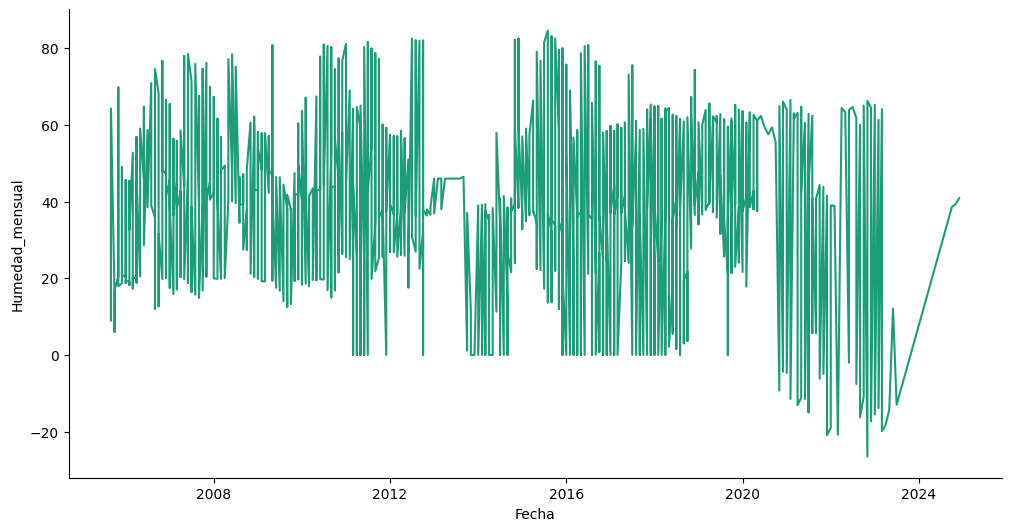

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series_hum(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Fecha']
  ys = series['Humedad']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = gjoind_hm.sort_values('Fecha', ascending=True)
_plot_series_hum(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Fecha')
_ = plt.ylabel('Humedad_mensual')

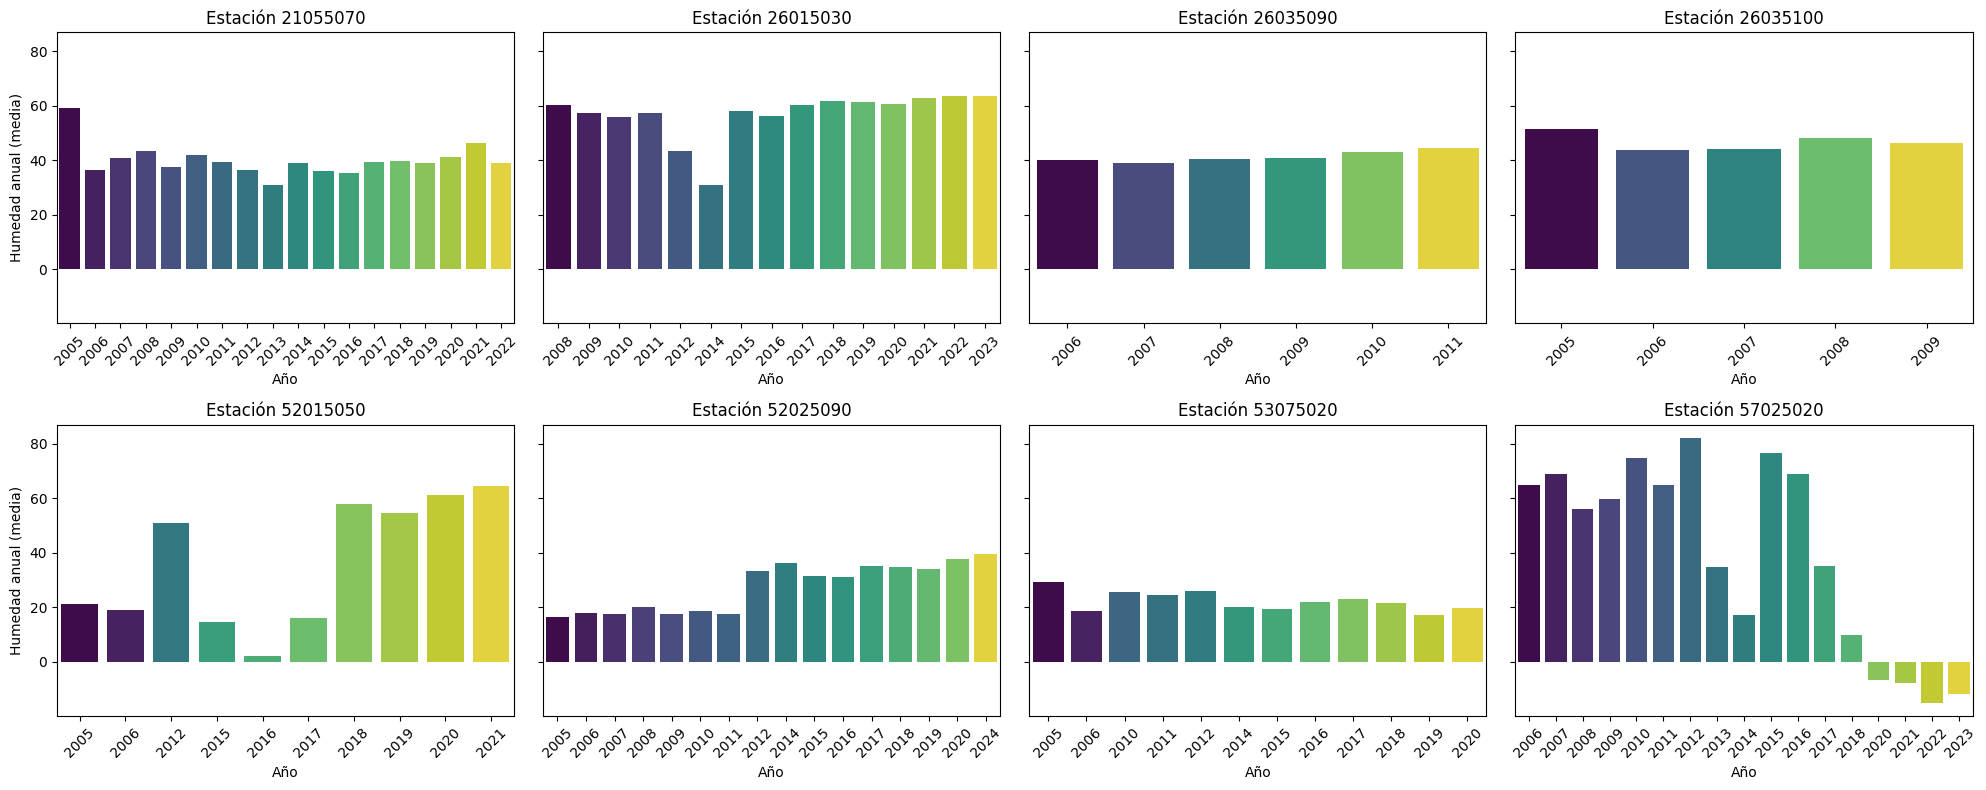

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

# Copia y limpieza mínima
df = gjoind_hm.copy()
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
df = df.dropna(subset=['Fecha', 'Humedad', 'EstacionID'])

# Lista ordenada de estaciones
estaciones = sorted(df['EstacionID'].unique())

# --- SIN límite ---
max_estaciones = None
if max_estaciones is not None:
    estaciones = estaciones[:max_estaciones]

# --- Crear subplots en grilla (p. ej., 4 por fila) ---
n = len(estaciones)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharey=True)
axes = np.ravel(axes)  # aplanar para iterar fácil

for ax, est in zip(axes, estaciones):
    dfe = df[df['EstacionID'] == est].copy()
    dfe['Year'] = dfe['Fecha'].dt.year

    annual_hum = (
        dfe.groupby('Year', as_index=False)['Humedad']
           .mean()     # usa .sum() si deseas acumulado anual
           .sort_values('Year')
    )
    if annual_hum.empty:
        ax.axis('off')
        continue

    sns.barplot(
        data=annual_hum,
        x='Year', y='Humedad',
        hue='Year',          # colores distintos por año
        dodge=False,
        palette='viridis',
        ax=ax
    )
    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_xlabel('Año')
    ax.set_ylabel('Humedad anual (media)')
    ax.set_title(f'Estación {est}')
    ax.tick_params(axis='x', rotation=45)

# Apaga ejes sobrantes si la grilla es mayor que n
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
dftemperatura['Fecha'] = pd.to_datetime(dftemperatura['Fecha'], errors='coerce')

# Select relevant columns from gdf and rename 'CODIGO' to 'EstacionID'
gdf_subsetdias2 = gdfestId[['Codigo', 'Nombre', 'geometry']].rename(columns={'Codigo': 'EstacionID'})

# Merge df with the modified gdf subset
gjoind_tmp = pd.merge(
    gdf_subsetdias2,
    dftemperatura,
    on='EstacionID',
    how='inner'
)

# Display the first few rows of the merged dataframe
display(gjoind_tmp.head(5))

,EstacionID,Nombre,geometry,Fecha,Humedad,EstacionGrupo
0,26015030,PNN PURACE - AUT [26015030],POINT (-76.40354 2.35685),2008-11-22,10.254545,TS30_MEDIA_D
1,26015030,PNN PURACE - AUT [26015030],POINT (-76.40354 2.35685),2008-11-23,10.695455,TS30_MEDIA_D
2,26015030,PNN PURACE - AUT [26015030],POINT (-76.40354 2.35685),2008-11-24,11.036364,TS30_MEDIA_D
3,26015030,PNN PURACE - AUT [26015030],POINT (-76.40354 2.35685),2008-11-25,11.104167,TS30_MEDIA_D
4,26015030,PNN PURACE - AUT [26015030],POINT (-76.40354 2.35685),2008-11-26,11.020833,TS30_MEDIA_D


In [ ]:
gjoind_tmp1=gjoind_tmp.rename(columns={'Humedad': 'Temperatura'})

In [ ]:
estaciones_unicas = (
    gjoind_tmp1[['EstacionID']]
      .drop_duplicates()
      .sort_values('EstacionID')
      .reset_index(drop=True)
)
print(estaciones_unicas)

  EstacionID
0   26015030
1   26035100
2   53075020
3   57025020


In [ ]:
gjoind_tmp1.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9122 entries, 0 to 9121
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   EstacionID     9122 non-null   object        
 1   Nombre         9122 non-null   object        
 2   geometry       9122 non-null   geometry      
 3   Fecha          9122 non-null   datetime64[ns]
 4   Temperatura    9122 non-null   float64       
 5   EstacionGrupo  9122 non-null   category      
dtypes: category(1), datetime64[ns](1), float64(1), geometry(1), object(2)
memory usage: 365.5+ KB


In [ ]:
print("Fecha mínima en df:", gjoind_tmp1['Fecha'].min())
print("Fecha máxima en df:", gjoind_tmp1['Fecha'].max())

Fecha mínima en df: 2005-09-12 00:00:00
Fecha máxima en df: 2023-07-26 00:00:00


In [ ]:
import os

output_dir = '/content/drive/MyDrive/TESIS/salida'
output_csv_path = os.path.join(output_dir, 'gjtemp.csv')

# Save the DataFrame to a CSV file
gjoind_tmp1.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"DataFrame saved successfully to: {output_csv_path}")

DataFrame saved successfully to: /content/drive/MyDrive/TESIS/salida/gjtemp.csv


In [ ]:
import os

gpkg_path = os.path.join('/content/drive/MyDrive/TESIS/salida', 'temp_suelo_diaria.gpkg')

# Define the layer name
layer_name = 'temp_diaria'

gjoind_tmp1.to_file(
    gpkg_path, layer=layer_name, driver='GPKG')

In [ ]:
# 1. Asegura que Fecha sea datetime
dftemperatura['Fecha'] = pd.to_datetime(dftemperatura['Fecha'], errors='coerce')

# 2. Crear columna año-mes
dftemperatura['YYYYMM'] = dftemperatura['Fecha'].dt.to_period('M')

# 3. Agrupar por estación y mes, promediando la temperatura
mensualtemp = (
    dftemperatura.groupby(['EstacionID','YYYYMM'], observed=True)['Humedad']
      .mean()
      .reset_index()
      .rename(columns={'Humedad':'Temperatura'})
)

# 4. Convertir YYYYMM a fecha (primer día del mes) si lo prefieres
mensualtemp['Fecha'] = mensualtemp['YYYYMM'].dt.to_timestamp()


mensualtemp.head(10)

,EstacionID,YYYYMM,Temperatura,Fecha
0,21195170,2005-07,16.377778,2005-07-01
1,21195170,2005-08,14.173611,2005-08-01
2,21195170,2005-09,14.387606,2005-09-01
3,21195170,2005-10,13.861132,2005-10-01
4,21195170,2005-11,13.796747,2005-11-01
5,21195170,2005-12,13.171285,2005-12-01
6,21195170,2006-01,13.129308,2006-01-01
7,21195170,2006-02,13.701833,2006-02-01
8,21195170,2006-03,13.642635,2006-03-01
9,21195170,2006-04,14.156123,2006-04-01


In [ ]:
mensualtemp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2344 entries, 0 to 2343
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   EstacionID   2344 non-null   category      
 1   YYYYMM       2344 non-null   period[M]     
 2   Temperatura  2344 non-null   float64       
 3   Fecha        2344 non-null   datetime64[ns]
dtypes: category(1), datetime64[ns](1), float64(1), period[M](1)
memory usage: 58.0 KB


In [ ]:
# Select relevant columns from gdf and rename 'CODIGO' to 'EstacionID'
gdf_subsetdias2 = gdfestId[['Codigo', 'Nombre', 'geometry']].rename(columns={'Codigo': 'EstacionID'})

# Merge df with the modified gdf subset
gjoind_tm = pd.merge(
    gdf_subsetdias2,
    mensualtemp,
    on='EstacionID',
    how='inner'
)

In [ ]:
display(gjoind_tm.head())

,EstacionID,Nombre,geometry,YYYYMM,Temperatura,Fecha
0,26015030,PNN PURACE - AUT [26015030],POINT (-76.40354 2.35685),2008-11,10.698737,2008-11-01
1,26015030,PNN PURACE - AUT [26015030],POINT (-76.40354 2.35685),2008-12,10.486839,2008-12-01
2,26015030,PNN PURACE - AUT [26015030],POINT (-76.40354 2.35685),2009-01,10.010403,2009-01-01
3,26015030,PNN PURACE - AUT [26015030],POINT (-76.40354 2.35685),2009-02,9.880256,2009-02-01
4,26015030,PNN PURACE - AUT [26015030],POINT (-76.40354 2.35685),2009-03,10.258147,2009-03-01


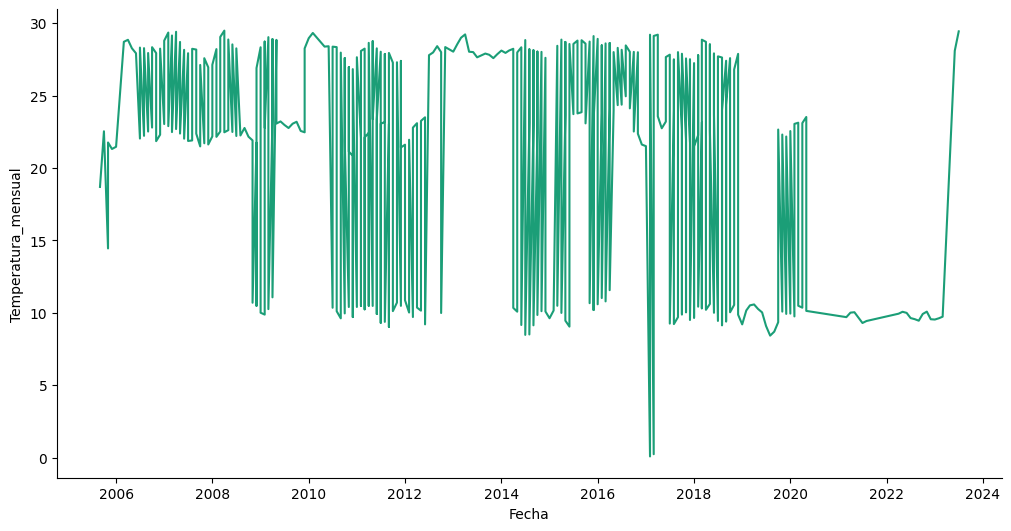

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series_temp(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Fecha']
  ys = series['Temperatura']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = gjoind_tm.sort_values('Fecha', ascending=True)
_plot_series_temp(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Fecha')
_ = plt.ylabel('Temperatura_mensual')

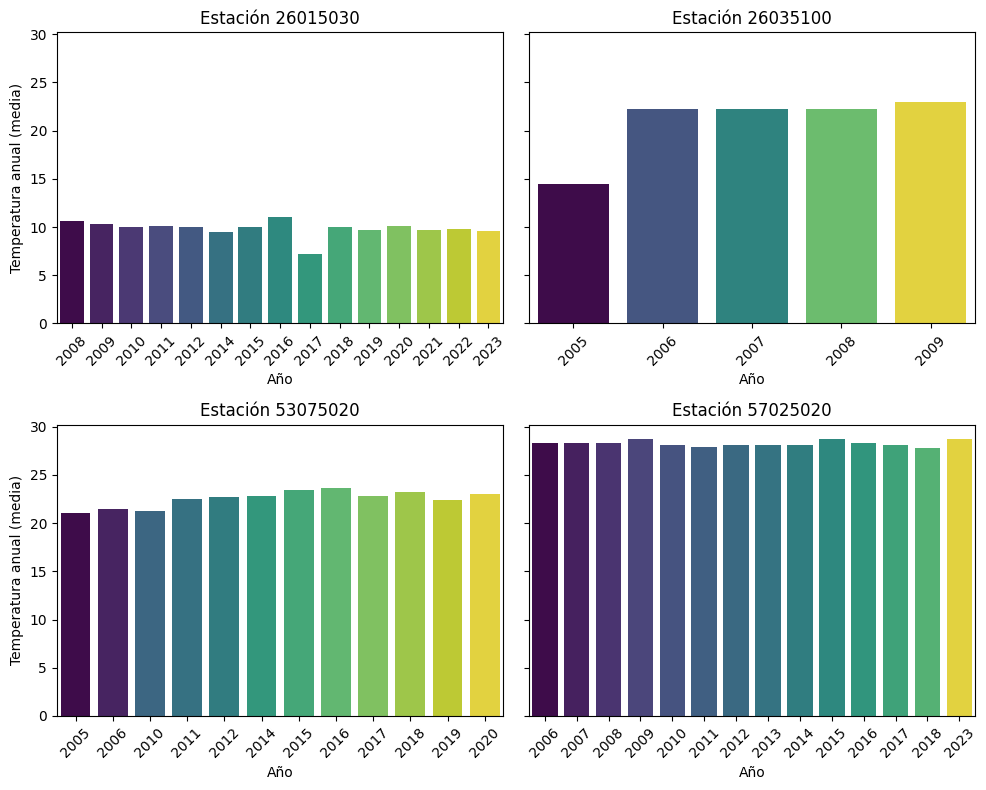

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

# Copia y limpieza mínima
df = gjoind_tm.copy()
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
df = df.dropna(subset=['Fecha', 'Temperatura', 'EstacionID'])

# Lista ordenada de estaciones
estaciones = sorted(df['EstacionID'].unique())

# --- SIN límite ---
max_estaciones = None
if max_estaciones is not None:
    estaciones = estaciones[:max_estaciones]

# --- Crear subplots en grilla (p. ej., 4 por fila) ---
n = len(estaciones)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharey=True)
axes = np.ravel(axes)  # aplanar para iterar fácil

for ax, est in zip(axes, estaciones):
    dfe = df[df['EstacionID'] == est].copy()
    dfe['Year'] = dfe['Fecha'].dt.year

    annual_temp = (
        dfe.groupby('Year', as_index=False)['Temperatura']
           .mean()     # usa .sum() si deseas acumulado anual
           .sort_values('Year')
    )
    if annual_temp.empty:
        ax.axis('off')
        continue

    sns.barplot(
        data=annual_temp,
        x='Year', y='Temperatura',
        hue='Year',          # colores distintos por año
        dodge=False,
        palette='viridis',
        ax=ax
    )
    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_xlabel('Año')
    ax.set_ylabel('Temperatura anual (media)')
    ax.set_title(f'Estación {est}')
    ax.tick_params(axis='x', rotation=45)

# Apaga ejes sobrantes si la grilla es mayor que n
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Al realizar este análisis inicial de datos, fue posible identificar que el número de estaciones con información diaria de humedad del suelo y temperatura dentro del departamento era insuficiente para realizar interpolaciones espaciales confiables a dicha resolución temporal. Por ello, se optó por realizar una nueva solicitud de datos asociados a la temperatura y humedad al IDEAM, considerando no solo las estaciones ubicadas en el departamento de estudio, sino también aquellas localizadas en los departamentos circundantes. Esta ampliación espacial buscó enriquecer la red de observaciones disponibles y, en consecuencia, mejorar la calidad y realismo de las interpolaciones generadas para las variables de interés.

## **NUEVA SOLICITUD IDEAM**

###**TRATAMIENTO HUMEDAD**


In [ ]:

from google.colab import drive
drive.mount('/content/drive')
RUTA_SHAPEHUM = '/content/drive/MyDrive/TESIS /Humedad/Humedad_Cauca.shp'
RUTA_HUMEDAD2 = '/content/drive/MyDrive/TESIS /humedad_suelo_unificado.csv'



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dfhumedadf = pd.read_csv(RUTA_HUMEDAD2)
gdf_esthum = gpd.read_file(RUTA_SHAPEHUM)

In [ ]:
dfhumedadf.head(5)

,Fecha,Valor,EstacionID
0,01-Jul-2005,83.5,21015040
1,02-Jul-2005,79.5,21015040
2,03-Jul-2005,79.3,21015040
3,04-Jul-2005,79.1,21015040
4,05-Jul-2005,NaN,21015040


In [ ]:
gdf_esthum.head(5)

,Codigo,Nombre,Categoria,Tecnologia,Estado,Departamen,Municipio,Altitud,LONGITUD,LATITUD,Area_Opera,Corriente,Area_Hidro,Zona_Hidro,Subzona_hi,Entidad,geometry
0,21015040,LA PRIMAVERA - AUT [21015040],Climática Principal,Automática con Telemetría,Activa,Huila,Saladoblanco,1919,-76.114333,2.021583,Area Operativa 04 - Huila-Caquetá,None,Magdalena Cauca,Alto Magdalena,Ríos Directos al Magdalena (mi),INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (4653634.186 1781739.064)
1,21015050,PURACE - AUT [21015050],Climática Principal,Automática con Telemetría,En Mantenimiento,Huila,San Agustín,1900,-76.427556,1.925917,Area Operativa 04 - Huila-Caquetá,None,Magdalena Cauca,Alto Magdalena,Alto Magdalena,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (4618736.936 1771220.416)
2,21015070,LOS GUACHAROS - AUT [21015070],Climática Principal,Automática con Telemetría,En Mantenimiento,Huila,Palestina,1590,-76.106841,1.675833,Area Operativa 04 - Huila-Caquetá,None,Magdalena Cauca,Alto Magdalena,Alto Magdalena,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (4654401.289 1743480.065)
3,21055070,INZA - AUT [21055070],Climática Principal,Automática con Telemetría,En Mantenimiento,Cauca,Inzá,1800,-76.063944,2.548194,Area Operativa 04 - Huila-Caquetá,None,Magdalena Cauca,Alto Magdalena,Río Páez,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (4659368.032 1839995.963)
4,26015030,PNN PURACE - AUT [26015030],Climática Principal,"Automática con Telemetría, Convencional",En Mantenimiento,Cauca,Puracé (Coconuco),3683,-76.403544,2.356849,Area Operativa 09 - Cauca-Valle-Caldas,None,Magdalena Cauca,Cauca,Alto Río Cauca,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (4621516.972 1818912.081)


In [ ]:
dfhumedadf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98638 entries, 0 to 98637
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fecha       98638 non-null  object 
 1   Valor       54711 non-null  float64
 2   EstacionID  98638 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 2.3+ MB


In [ ]:
dfhumedadf['Fecha'] = pd.to_datetime(dfhumedadf['Fecha'], errors='coerce')


In [ ]:
dfhumedadf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98638 entries, 0 to 98637
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Fecha       98638 non-null  datetime64[ns]
 1   Valor       54711 non-null  float64       
 2   EstacionID  98638 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 2.3 MB


In [ ]:
# Fecha mínima y máxima en tu DataFrame
print("Fecha mínima:", dfhumedadf['Fecha'].min())
print("Fecha máxima:", dfhumedadf['Fecha'].max())

Fecha mínima: 2005-05-19 00:00:00
Fecha máxima: 2025-10-31 00:00:00


In [ ]:
dfhumedadf['Fecha'] = pd.to_datetime(dfhumedadf['Fecha'], errors='coerce')

# Select relevant columns from gdf and rename 'CODIGO' to 'EstacionID'
gdf_subsetdias2 = gdf_esthum[['Codigo', 'Nombre', 'geometry']].rename(columns={'Codigo': 'EstacionID'})

# Merge df with the modified gdf subset
gjoind_hum = pd.merge(
    gdf_subsetdias2,
    dfhumedadf,
    on='EstacionID',
    how='inner'
)


gjoind_hum = gjoind_hum[gjoind_hum ['Fecha'] >= pd.Timestamp('2005-01-01')]

# Display the first few rows of the merged dataframe
display(gjoind_hum.head(20))

,EstacionID,Nombre,geometry,Fecha,Valor
0,21015040,LA PRIMAVERA - AUT [21015040],POINT (4653634.186 1781739.064),2005-07-01,83.5
1,21015040,LA PRIMAVERA - AUT [21015040],POINT (4653634.186 1781739.064),2005-07-02,79.5
2,21015040,LA PRIMAVERA - AUT [21015040],POINT (4653634.186 1781739.064),2005-07-03,79.3
3,21015040,LA PRIMAVERA - AUT [21015040],POINT (4653634.186 1781739.064),2005-07-04,79.1
4,21015040,LA PRIMAVERA - AUT [21015040],POINT (4653634.186 1781739.064),2005-07-05,NaN
5,21015040,LA PRIMAVERA - AUT [21015040],POINT (4653634.186 1781739.064),2005-07-06,NaN
6,21015040,LA PRIMAVERA - AUT [21015040],POINT (4653634.186 1781739.064),2005-07-07,NaN
7,21015040,LA PRIMAVERA - AUT [21015040],POINT (4653634.186 1781739.064),2005-07-08,NaN
8,21015040,LA PRIMAVERA - AUT [21015040],POINT (4653634.186 1781739.064),2005-07-09,NaN
9,21015040,LA PRIMAVERA - AUT [21015040],POINT (4653634.186 1781739.064),2005-07-10,NaN


In [ ]:
resumen_nan = gjoind_hum.groupby('EstacionID').agg(
    total_registros=('Valor', 'size'),
    total_nan=('Valor', lambda x: x.isna().sum()),
    porcentaje_nan=('Valor', lambda x: x.isna().mean() * 100)
)

resumen_nan


,total_registros,total_nan,porcentaje_nan
EstacionID,,,
21015040,7428,3749,50.471190
21015050,7430,3576,48.129206
21015070,7428,2587,34.827679
21055070,6281,2288,36.427320
26015030,6171,3425,55.501539
26055100,6918,2816,40.705406
26055110,6252,1001,16.010877
26085160,2262,509,22.502210
26095320,6487,2357,36.334207


In [ ]:
estaciones_unicas = (
    gjoind_hum[['EstacionID']]
      .drop_duplicates()
      .sort_values('EstacionID')
      .reset_index(drop=True)
)
print(estaciones_unicas)

    EstacionID
0     21015040
1     21015050
2     21015070
3     21055070
4     26015030
5     26055100
6     26055110
7     26085160
8     26095320
9     44015070
10    44035040
11    52025090
12    52055210
13    53075020
14    57025020


In [ ]:
import os

gpkg_path = os.path.join('/content/drive/MyDrive/TESIS/salida', 'humedad_suelo_diaria.gpkg')

# Define the layer name
layer_name = 'humedad_diaria'

gjoind_hum.to_file(
    gpkg_path, layer=layer_name, driver='GPKG')

In [ ]:
# 1. Asegura que Fecha sea datetime
dfhumedadf['Fecha'] = pd.to_datetime(dfhumedadf['Fecha'], errors='coerce')

# 2. Crear columna año-mes
dfhumedadf['YYYYMM'] = dfhumedadf['Fecha'].dt.to_period('M')

# 3. Agrupar por estación y mes, sumando la precipitación
mensualhum1 = (
    dfhumedadf.groupby(['EstacionID','YYYYMM'], observed=True)['Valor']
      .mean()
      .reset_index()
      .rename(columns={'Valor':'Humedad_mensual'}) # Corrected: Renaming 'Valor' to 'Humedad_mensual'
)

# 4. Convertir YYYYMM a fecha (primer día del mes) si lo prefieres
mensualhum1['Fecha'] = mensualhum1['YYYYMM'].dt.to_timestamp()

mensualhum1.head(100)

,EstacionID,YYYYMM,Humedad_mensual,Fecha
0,21015040,2005-07,67.600000,2005-07-01
1,21015040,2005-08,57.096000,2005-08-01
2,21015040,2005-09,57.666667,2005-09-01
3,21015040,2005-10,58.261538,2005-10-01
4,21015040,2005-11,58.505556,2005-11-01
...,...,...,...,...
95,21015040,2013-06,57.300000,2013-06-01
96,21015040,2013-07,60.006452,2013-07-01
97,21015040,2013-08,58.558065,2013-08-01
98,21015040,2013-09,58.603333,2013-09-01


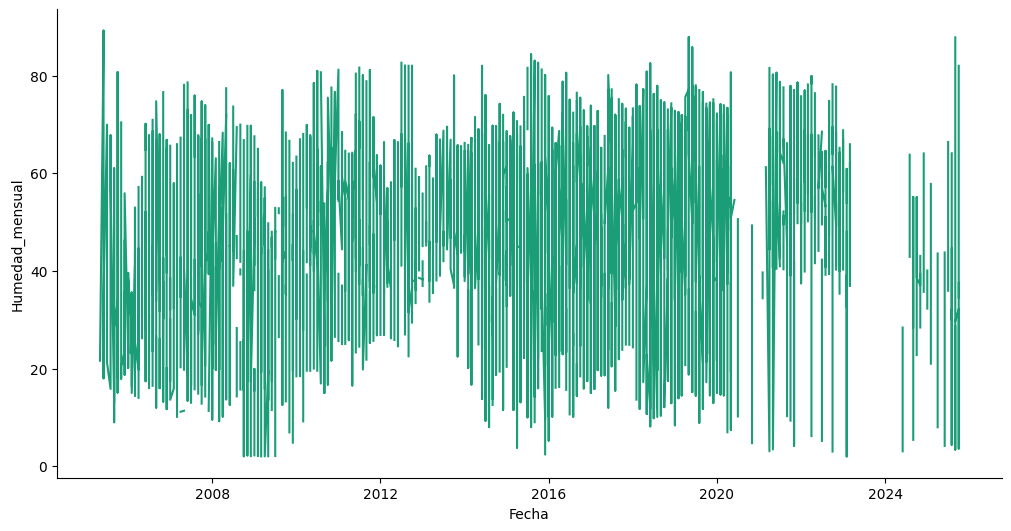

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

def _plot_series_hum(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Fecha']
  ys = series['Humedad_mensual'] # Changed from 'Humedad' to 'Humedad_mensual'

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

# Ensure gdf_subsetdias2 is defined for the current dataset
gdf_subsetdias2 = gdf_esthum[['Codigo', 'Nombre', 'geometry']].rename(columns={'Codigo': 'EstacionID'})

# Create a new merged GeoDataFrame for the monthly humidity from the current dataset
gjoind_hm_new = pd.merge(
    gdf_subsetdias2,
    mensualhum1,
    on='EstacionID',
    how='inner'
)

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = gjoind_hm_new.sort_values('Fecha', ascending=True) # Use the new GeoDataFrame
_plot_series_hum(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Fecha')
_ = plt.ylabel('Humedad_mensual')


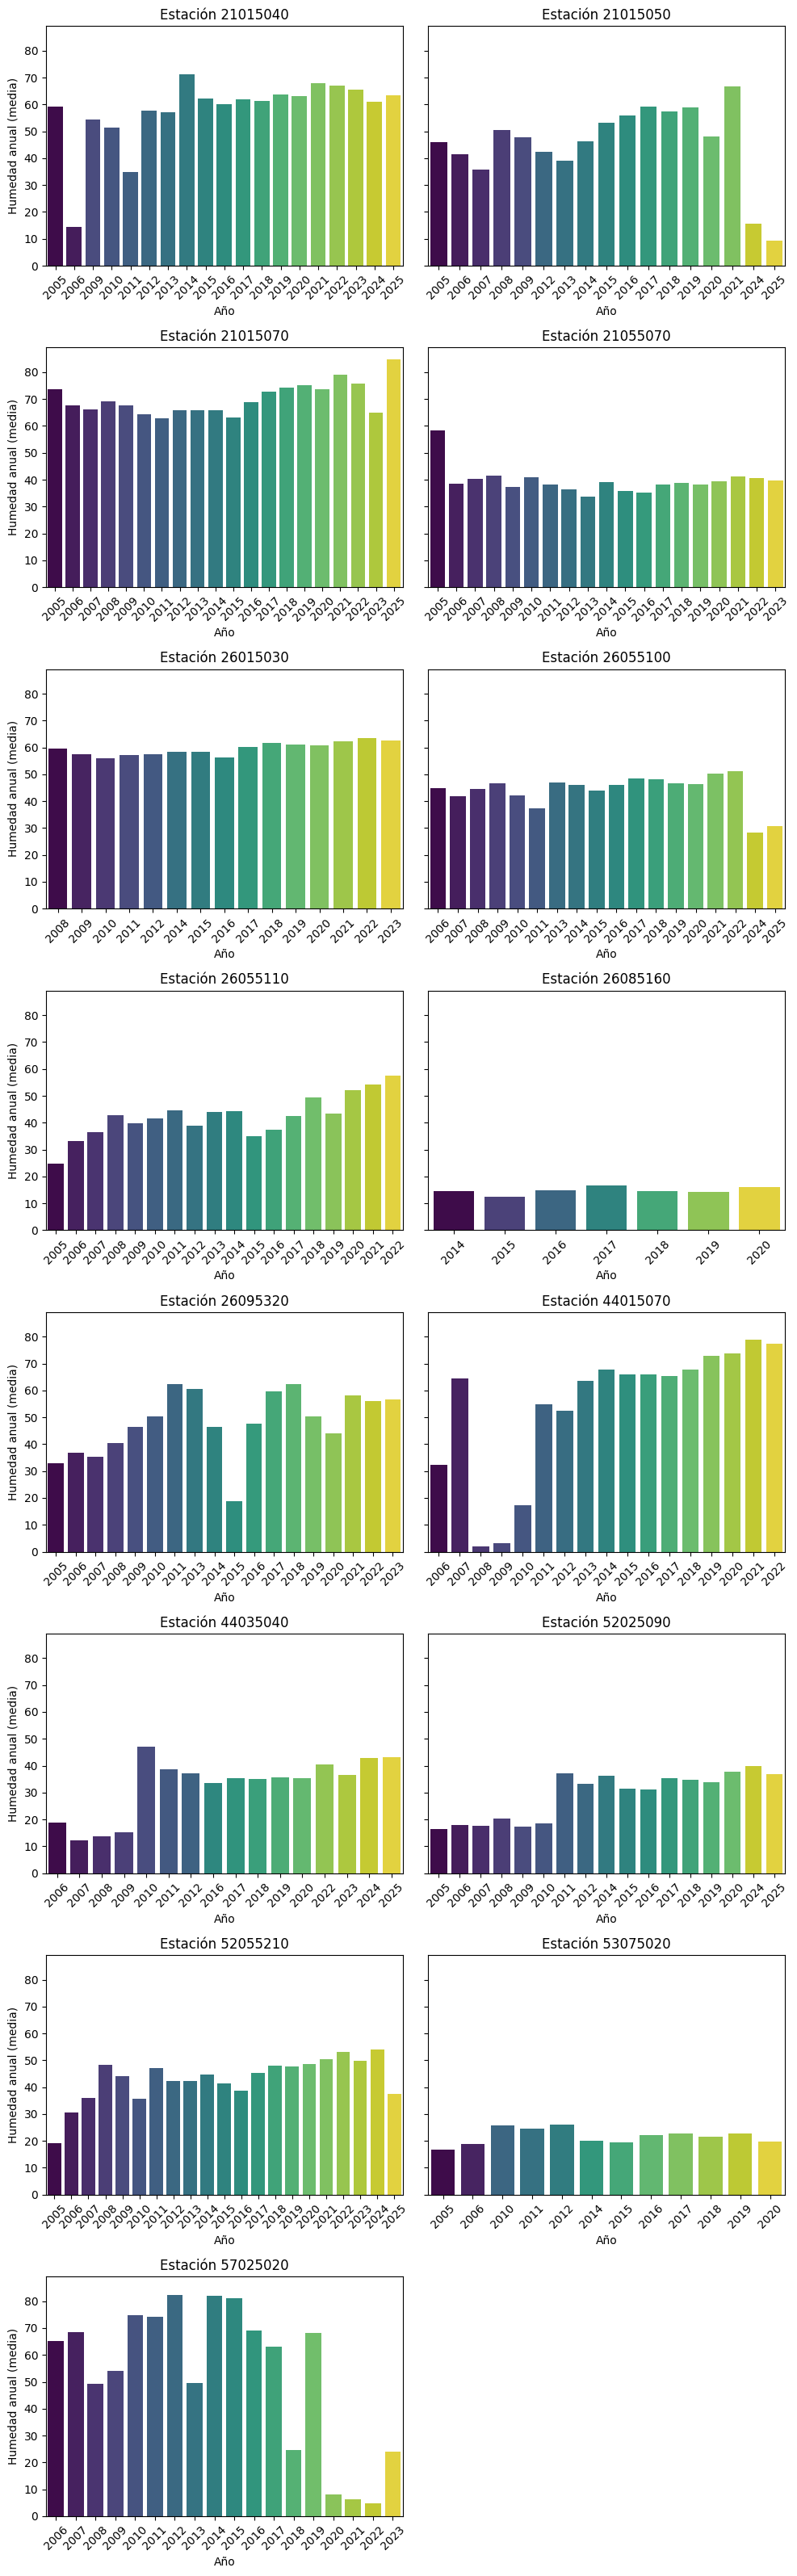

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

# Copia y limpieza mínima
df = gjoind_hm_new.copy()
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
df = df.dropna(subset=['Fecha', 'Humedad_mensual', 'EstacionID']) # Changed 'Temperatura' to 'Humedad_mensual'

# Lista ordenada de estaciones
estaciones = sorted(df['EstacionID'].unique())

# --- SIN límite ---
max_estaciones = None
if max_estaciones is not None:
    estaciones = estaciones[:max_estaciones]

# --- Crear subplots en grilla (p. ej., 4 por fila) ---
n = len(estaciones)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharey=True)
axes = np.ravel(axes)  # aplanar para iterar fácil

for ax, est in zip(axes, estaciones):
    dfe = df[df['EstacionID'] == est].copy()
    dfe['Year'] = dfe['Fecha'].dt.year

    annual_hum = ( # Renamed variable for clarity
        dfe.groupby('Year', as_index=False)['Humedad_mensual'] # Changed 'Temperatura' to 'Humedad_mensual'
           .mean()     # usa .sum() si deseas acumulado anual
           .sort_values('Year')
    )
    if annual_hum.empty:
        ax.axis('off')
        continue

    sns.barplot(
        data=annual_hum,
        x='Year', y='Humedad_mensual', # Changed 'Temperatura' to 'Humedad_mensual'
        hue='Year',          # colores distintos por año
        dodge=False,
        palette='viridis',
        ax=ax
    )
    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_xlabel('Año')
    ax.set_ylabel('Humedad anual (media)') # Changed label
    ax.set_title(f'Estación {est}')
    ax.tick_params(axis='x', rotation=45)

# Apaga ejes sobrantes si la grilla es mayor que n
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
gjoind_hum = gjoind_hum.sort_values(['EstacionID', 'Fecha'])


In [ ]:
gjoind_hum.tail(5)

,EstacionID,Nombre,geometry,Fecha,Valor
98633,57025020,GORGONA GUAPI AUT [57025020],POINT (4424433.858 1886761.985),2023-10-28,NaN
98634,57025020,GORGONA GUAPI AUT [57025020],POINT (4424433.858 1886761.985),2023-10-29,NaN
98635,57025020,GORGONA GUAPI AUT [57025020],POINT (4424433.858 1886761.985),2023-10-30,NaN
98636,57025020,GORGONA GUAPI AUT [57025020],POINT (4424433.858 1886761.985),2023-10-31,NaN
98637,57025020,GORGONA GUAPI AUT [57025020],POINT (4424433.858 1886761.985),2023-11-01,88.5


In [ ]:
gjoind_hum['Year'] = gjoind_hum['Fecha'].dt.year
gjoind_hum['Month'] = gjoind_hum['Fecha'].dt.month

hum_mensual = (
    gjoind_hum
    .groupby(['EstacionID','Year','Month'])['Valor']
    .mean()
    .reset_index()
    .rename(columns={'Valor':'Humedad_mensual'})
)


In [ ]:
gjoind_hum.tail(5)

,EstacionID,Nombre,geometry,Fecha,Valor,Year,Month
98633,57025020,GORGONA GUAPI AUT [57025020],POINT (4424433.858 1886761.985),2023-10-28,NaN,2023,10
98634,57025020,GORGONA GUAPI AUT [57025020],POINT (4424433.858 1886761.985),2023-10-29,NaN,2023,10
98635,57025020,GORGONA GUAPI AUT [57025020],POINT (4424433.858 1886761.985),2023-10-30,NaN,2023,10
98636,57025020,GORGONA GUAPI AUT [57025020],POINT (4424433.858 1886761.985),2023-10-31,NaN,2023,10
98637,57025020,GORGONA GUAPI AUT [57025020],POINT (4424433.858 1886761.985),2023-11-01,88.5,2023,11


In [ ]:
mensualhum1['Year'] = mensualhum1['YYYYMM'].dt.year
mensualhum1['Month'] = mensualhum1['YYYYMM'].dt.month

In [ ]:
mensualhum1.tail(1010)

,EstacionID,YYYYMM,Humedad_mensual,Fecha,Year,Month
2245,44035040,2020-03,36.045161,2020-03-01,2020,3
2246,44035040,2020-04,37.315000,2020-04-01,2020,4
2247,44035040,2020-05,NaN,2020-05-01,2020,5
2248,44035040,2020-06,NaN,2020-06-01,2020,6
2249,44035040,2020-07,NaN,2020-07-01,2020,7
...,...,...,...,...,...,...
3250,57025020,2023-07,NaN,2023-07-01,2023,7
3251,57025020,2023-08,NaN,2023-08-01,2023,8
3252,57025020,2023-09,NaN,2023-09-01,2023,9
3253,57025020,2023-10,NaN,2023-10-01,2023,10


###**TRATAMIENTO DATOS HUMEDAD DEL SUELO TRIMESTRAL**

Se identifica que mensualmente hay muchas estaciones sin informacion esto debido a que el IDEAM limita la información para que cumpla con ciertos estandares de calidad y/o por otras cuestienes.Como respuesta a esta limitación y teniendo en cuenta que la humedad no es tan variable en el tiempo se propone tomar información trimestral por año en los trimestres que ocurrieron eventos.Si aun sigue presentado inconvenientes de falta de información, se realiza un promedio del mismo trimestre en años anteriores que se remplazará en el trimestre faltante.

In [ ]:
import pandas as pd
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio folium

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 0. RUTAS A LOS ARCHIVOS CSV
# ============================================================
ruta_humedad_csv = '/content/drive/MyDrive/TESIS /humedad_suelo_unificado.csv'
ruta_evt_csv      = '/content/drive/MyDrive/TESIS/salida/INTERPOLACION/rasters_acumuladosdef/eventos_features_excluyentes_definitivos.csv'

# ============================================================
# 1. CARGA DE DATOS
# ============================================================

# Humedad diaria - Asegurando que la fecha sea de tipo datatime
dfhumedadf = pd.read_csv(ruta_humedad_csv)
dfhumedadf['Fecha'] = pd.to_datetime(dfhumedadf['Fecha'], errors='coerce')

# Eventos de deslizamiento -  Asegurando que la fecha sea de tipo datatime
evt = pd.read_csv(ruta_evt_csv)
evt['Fecha_even'] = pd.to_datetime(evt['Fecha_even'], errors='coerce')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# 2. DEFINIR AÑO Y TRIMESTRE EN EVENTOS
# ============================================================
# Extraccción de fechas por trimestres de eventos.
evt['Year'] = evt['Fecha_even'].dt.year
evt['Trimestre'] = evt['Fecha_even'].dt.quarter   # trimestre calendario

# Listado único de trimestres donde HAY eventos
trimestres_con_evento = (
    evt[['Year', 'Trimestre']]
    .dropna()
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .reset_index(drop=True)
)

trimestres_con_evento

,Year,Trimestre
0,2005,4
1,2006,1
2,2006,2
3,2006,4
4,2007,1
...,...,...
58,2023,4
59,2024,1
60,2024,2
61,2024,4


In [ ]:
# ============================================================
# 3. HUMEDAD TRIMESTRAL POR ESTACIÓN
# ============================================================
#Extracción de trimestres en información que contiene humedad.
dfhumedadf['Year'] = dfhumedadf['Fecha'].dt.year
dfhumedadf['Trimestre'] = dfhumedadf['Fecha'].dt.quarter

hum_trimestral = (
    dfhumedadf
    .groupby(['EstacionID', 'Year', 'Trimestre'])['Valor']
    .mean()
    .reset_index()
    .rename(columns={'Valor': 'Humedad_trimestral'})
)

# Limitar la humedad al rango temporal de los eventos
max_year_evt = trimestres_con_evento['Year'].max()
max_q_evt    = trimestres_con_evento[trimestres_con_evento['Year'] == max_year_evt]['Trimestre'].max()

hum_trimestral = hum_trimestral[
    (hum_trimestral['Year'] < max_year_evt) |
    ((hum_trimestral['Year'] == max_year_evt) &
     (hum_trimestral['Trimestre'] <= max_q_evt))
].copy()


In [ ]:
hum_trimestral

,EstacionID,Year,Trimestre,Humedad_trimestral
0,21015040,2005,3,58.810526
1,21015040,2005,4,58.204255
2,21015040,2006,1,14.733333
3,21015040,2006,2,14.000000
4,21015040,2006,3,NaN
...,...,...,...,...
1094,57025020,2022,4,3.000000
1095,57025020,2023,1,2.000000
1096,57025020,2023,2,2.750000
1097,57025020,2023,3,NaN


In [ ]:
# ============================================================
# 4. CONTAR ESTACIONES POR TRIMESTRE Y DEFINIR UMBRAL
# ============================================================
conteo_trimestre = (
    hum_trimestral
    .groupby(['Year', 'Trimestre'])['Humedad_trimestral']
    .apply(lambda x: x.notna().sum())   # solo estaciones con dato NO NaN
    .reset_index(name='N_estaciones')
)

UMBRAL_EST = 7   # umbral mínimo de estaciones con información viable por trimestres

trimestres_no_interpolables = conteo_trimestre[
    conteo_trimestre['N_estaciones'] < UMBRAL_EST
]

In [ ]:
trimestres_no_interpolables

,Year,Trimestre,N_estaciones
0,2005,2,5
61,2020,3,3
62,2020,4,3
63,2021,1,5
72,2023,2,2
73,2023,3,1
74,2023,4,1
75,2024,1,0
76,2024,2,5
77,2024,3,4


Tener en cuenta que:

```
hum_trimestral: humedad media por estación–año–trimestre
trimestres_con_evento: lista de año–trimestre donde hubo deslizamientos
trimestres_no_interpolables: lista de año–trimestre con pocas estaciones (por debajo del umbral)

```
El siguiente código permite determinar los trimestres problemáticos donde se ocasionaron eventos de deslizamientos, sin embargo el umbral de información de humedad es inferior a 7 estaciones con información valida; es decir donde no hay nan.
Si, sí hay trimestres críticos con eventos, entramos al else para calcular la climatología que hace referencia al promedio de humedad para ese trimestre a lo largo de todos los años disponible, es decir, el valor típico de humedad de esa estación en ese trimestre.

In [ ]:
# ============================================================
# 5.TRIMESTRES CRÍTICOS QUE TIENEN EVENTOS
# ============================================================
trimestres_con_evento = trimestres_con_evento.drop_duplicates(subset=['Year', 'Trimestre'])

trimestres_no_interpolables = (
    trimestres_no_interpolables
    .merge(trimestres_con_evento, on=['Year', 'Trimestre'], how='inner')
)

# Si no hay ninguno, hum_trimestral_final = hum_trimestral y se termina
if trimestres_no_interpolables.empty:
    hum_trimestral_final = hum_trimestral.copy()
else:
    clim_trimestral = (
        hum_trimestral
        .groupby(['EstacionID', 'Trimestre'])['Humedad_trimestral']
        .mean()
        .reset_index()
        .rename(columns={'Humedad_trimestral': 'Humedad_clim_trimestral'})
    )


In [ ]:
# ========================================================
# 6. MARCAR TRIMESTRES CRÍTICOS
# ========================================================
criticos = trimestres_no_interpolables[['Year', 'Trimestre']].drop_duplicates()
criticos['es_critico'] = True

hum_trimestral_flag = hum_trimestral.merge(
    criticos,
    on=['Year', 'Trimestre'],
    how='left'
)
hum_trimestral_flag['es_critico'] = hum_trimestral_flag['es_critico'].fillna(False)

# Separar buenos y críticos
base_ok = hum_trimestral_flag[~hum_trimestral_flag['es_critico']].copy()
base_critica = hum_trimestral_flag[hum_trimestral_flag['es_critico']].copy()

/tmp/ipython-input-3781505316.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hum_trimestral_flag['es_critico'] = hum_trimestral_flag['es_critico'].fillna(False)


In [ ]:
base_ok

,EstacionID,Year,Trimestre,Humedad_trimestral,es_critico
0,21015040,2005,3,58.810526,False
1,21015040,2005,4,58.204255,False
2,21015040,2006,1,14.733333,False
3,21015040,2006,2,14.000000,False
4,21015040,2006,3,NaN,False
...,...,...,...,...,...
1065,57025020,2022,1,NaN,False
1066,57025020,2022,2,5.178431,False
1067,57025020,2022,3,4.614634,False
1068,57025020,2022,4,3.000000,False


In [ ]:
base_critica

,EstacionID,Year,Trimestre,Humedad_trimestral,es_critico
60,21015040,2020,3,NaN,True
61,21015040,2020,4,NaN,True
62,21015040,2021,1,NaN,True
71,21015040,2023,2,NaN,True
72,21015040,2023,3,NaN,True
...,...,...,...,...,...
1060,57025020,2020,4,8.700000,True
1061,57025020,2021,1,6.506667,True
1070,57025020,2023,2,2.750000,True
1071,57025020,2023,3,NaN,True


In [ ]:
# ========================================================
# 7. REEMPLAZAR TRIMESTRES CRÍTICOS POR CLIMATOLOGÍA
# ========================================================
base_critica = base_critica.merge(
    clim_trimestral,
    on=['EstacionID', 'Trimestre'],
    how='left'
)

# Sustituir valor problemático por la climatología
base_critica['Humedad_trimestral'] = base_critica['Humedad_clim_trimestral']

# Asegurar mismas columnas que base_ok
base_critica = base_critica[base_ok.columns]

In [ ]:
base_critica

,EstacionID,Year,Trimestre,Humedad_trimestral,es_critico
0,21015040,2020,3,61.201678,True
1,21015040,2020,4,62.225030,True
2,21015040,2021,1,56.395635,True
3,21015040,2023,2,54.870898,True
4,21015040,2023,3,61.201678,True
...,...,...,...,...,...
103,57025020,2020,4,56.029033,True
104,57025020,2021,1,47.901233,True
105,57025020,2023,2,49.613730,True
106,57025020,2023,3,54.150966,True


In [ ]:
# ========================================================
# 9. UNIR TODO → SERIE TRIMESTRAL FINAL
# ========================================================
hum_trimestral_final = pd.concat(
        [base_ok, base_critica],
        ignore_index=True
    ).sort_values(['EstacionID', 'Year', 'Trimestre']).reset_index(drop=True)

# Eliminar filas donde Humedad_trimestral es NaN
hum_trimestral_final = hum_trimestral_final.dropna(subset=['Humedad_trimestral'])

# Revisar resultado
display(hum_trimestral_final.head(20))
print("Número de filas:", len(hum_trimestral_final))



,EstacionID,Year,Trimestre,Humedad_trimestral,es_critico
0,21015040,2005,3,58.810526,False
1,21015040,2005,4,58.204255,False
2,21015040,2006,1,14.733333,False
3,21015040,2006,2,14.000000,False
16,21015040,2009,3,54.966667,False
17,21015040,2009,4,53.844615,False
18,21015040,2010,1,49.960000,False
19,21015040,2010,2,55.095238,False
23,21015040,2011,2,16.533333,False
24,21015040,2011,3,53.050000,False


Número de filas: 871


In [ ]:
hum_trimestral_final

,EstacionID,Year,Trimestre,Humedad_trimestral,es_critico
0,21015040,2005,3,58.810526,False
1,21015040,2005,4,58.204255,False
2,21015040,2006,1,14.733333,False
3,21015040,2006,2,14.000000,False
16,21015040,2009,3,54.966667,False
...,...,...,...,...,...
1067,57025020,2022,3,4.614634,False
1068,57025020,2022,4,3.000000,False
1069,57025020,2023,1,2.000000,False
1070,57025020,2023,2,2.750000,True


In [ ]:
# Ruta donde quieres guardar el archivo
ruta_csv = "/content/drive/MyDrive/TESIS/salida/hum_trimestral_final.csv"

# Exportar a CSV
hum_trimestral_final.to_csv(ruta_csv, index=False)

print("Archivo exportado a:", ruta_csv)

Archivo exportado a: /content/drive/MyDrive/TESIS/salida/hum_trimestral_final.csv


###**TRATAMIENTO TEMPERATURA**


In [ ]:
!pip install geopandas
import geopandas as gpd
import pandas as pd


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
RUTA_SHAPETEM = '/content/drive/MyDrive/TESIS /Temperatura/Temperatura_Cauca.shp'
RUTA_TEMP2 = '/content/drive/MyDrive/TESIS /Temperatura_suelo_unificado.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dftemperaturaf = pd.read_csv(RUTA_TEMP2)
gdf_tem = gpd.read_file(RUTA_SHAPETEM)

In [ ]:
dftemperaturaf.head(5)


,Fecha,Valor,EstacionID
0,29-Jun-2005,15.7,21015050
1,30-Jun-2005,NaN,21015050
2,01-Jul-2005,NaN,21015050
3,02-Jul-2005,NaN,21015050
4,03-Jul-2005,NaN,21015050


In [ ]:
dftemperaturaf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91068 entries, 0 to 91067
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fecha       91068 non-null  object 
 1   Valor       53848 non-null  float64
 2   EstacionID  91068 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 2.1+ MB


In [ ]:
gdf_tem.head(5)

,Codigo,Nombre,Categoria,Tecnologia,Estado,Departamen,Municipio,Ubicación,Altitud,LONGITUD,LATITUD,Area_Opera,Corriente,Area_Hidro,Zona_Hidro,Subzona_hi,Entidad,geometry
0,21015050.0,PURACE - AUT [21015050],Climática Principal,Automática con Telemetría,En Mantenimiento,Huila,San Agustín,"(1.925916667, -76.42755556)",1900,-76.427556,1.925917,Area Operativa 04 - Huila-Caquetá,None,Magdalena Cauca,Alto Magdalena,Alto Magdalena,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (4618736.936 1771220.416)
1,21015070.0,LOS GUACHAROS - AUT [21015070],Climática Principal,Automática con Telemetría,En Mantenimiento,Huila,Palestina,"(1.675833, -76.106841)",1590,-76.106841,1.675833,Area Operativa 04 - Huila-Caquetá,None,Magdalena Cauca,Alto Magdalena,Alto Magdalena,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (4654401.289 1743480.065)
2,21115180.0,HACIENDA MANILA - AUT [21115180],Agrometeorológica,"Automática con Telemetría, Convencional",En Mantenimiento,Huila,Baraya,"(3.133091, -75.081536)",548,-75.081536,3.133091,Area Operativa 04 - Huila-Caquetá,None,Magdalena Cauca,Alto Magdalena,Rio Fortalecillas y otros,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (4768762.7 1904444.762)
3,22075050.0,PARAMO DE YERBABUENA - AUT [22075050],Climática Principal,"Automática con Telemetría, Convencional",En Mantenimiento,Tolima,Roncesvalles,"(4.075805556, -75.70083333)",3394,-75.700833,4.075806,Area Operativa 10 - Tolima,None,Magdalena Cauca,Saldaña,Rïo Cucuana,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (4700229.194 2008878.318)
4,26015030.0,PNN PURACE - AUT [26015030],Climática Principal,"Automática con Telemetría, Convencional",En Mantenimiento,Cauca,Puracé (Coconuco),"(2.356848889, -76.403544444)",3683,-76.403544,2.356849,Area Operativa 09 - Cauca-Valle-Caldas,None,Magdalena Cauca,Cauca,Alto Río Cauca,INSTITUTO DE HIDROLOGIA METEOROLOGIA Y ESTUDIO...,POINT (4621516.972 1818912.081)


In [ ]:
gdf_tem.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Codigo      15 non-null     float64 
 1   Nombre      15 non-null     object  
 2   Categoria   15 non-null     object  
 3   Tecnologia  15 non-null     object  
 4   Estado      15 non-null     object  
 5   Departamen  15 non-null     object  
 6   Municipio   15 non-null     object  
 7   Ubicación   15 non-null     object  
 8   Altitud     15 non-null     int64   
 9   LONGITUD    15 non-null     float64 
 10  LATITUD     15 non-null     float64 
 11  Area_Opera  15 non-null     object  
 12  Corriente   0 non-null      object  
 13  Area_Hidro  15 non-null     object  
 14  Zona_Hidro  15 non-null     object  
 15  Subzona_hi  15 non-null     object  
 16  Entidad     15 non-null     object  
 17  geometry    15 non-null     geometry
dtypes: float64(3), geometry(1), int64(1), object

In [ ]:
dftemperaturaf['Fecha'] = pd.to_datetime(dftemperaturaf['Fecha'], errors='coerce')
gdf_tem['Codigo'] = gdf_tem['Codigo'].astype('int')


In [ ]:
# Fecha mínima y máxima en tu DataFrame
print("Fecha mínima:", dftemperaturaf['Fecha'].min())
print("Fecha máxima:", dftemperaturaf['Fecha'].max())

Fecha mínima: 2005-04-06 00:00:00
Fecha máxima: 2025-10-31 00:00:00


In [ ]:
gdf_temp2 = gdf_tem[['Codigo', 'Nombre', 'geometry']].rename(columns={'Codigo': 'EstacionID'})

# Merge df with the modified gdf subset
gjoind_temp = pd.merge(
    gdf_temp2,
    dftemperaturaf,
    on='EstacionID',
    how='inner'
)


gjoind_temp = gjoind_temp[gjoind_temp ['Fecha'] >= pd.Timestamp('2005-01-01')]

# Display the first few rows of the merged dataframe
display(gjoind_temp.head(20))

,EstacionID,Nombre,geometry,Fecha,Valor
0,21015050,PURACE - AUT [21015050],POINT (4618736.936 1771220.416),2005-06-29,15.7
1,21015050,PURACE - AUT [21015050],POINT (4618736.936 1771220.416),2005-06-30,NaN
2,21015050,PURACE - AUT [21015050],POINT (4618736.936 1771220.416),2005-07-01,NaN
3,21015050,PURACE - AUT [21015050],POINT (4618736.936 1771220.416),2005-07-02,NaN
4,21015050,PURACE - AUT [21015050],POINT (4618736.936 1771220.416),2005-07-03,NaN
5,21015050,PURACE - AUT [21015050],POINT (4618736.936 1771220.416),2005-07-04,NaN
6,21015050,PURACE - AUT [21015050],POINT (4618736.936 1771220.416),2005-07-05,NaN
7,21015050,PURACE - AUT [21015050],POINT (4618736.936 1771220.416),2005-07-06,NaN
8,21015050,PURACE - AUT [21015050],POINT (4618736.936 1771220.416),2005-07-07,NaN
9,21015050,PURACE - AUT [21015050],POINT (4618736.936 1771220.416),2005-07-08,NaN


In [ ]:
resumen_nan = gjoind_temp.groupby('EstacionID').agg(
    total_registros=('Valor', 'size'),
    total_nan=('Valor', lambda x: x.isna().sum()),
    porcentaje_nan=('Valor', lambda x: x.isna().mean() * 100)
)

resumen_nan


,total_registros,total_nan,porcentaje_nan
EstacionID,,,
21015050,7430,3291,44.293405
21015070,7430,2352,31.655451
21115180,566,177,31.272085
22075050,5986,2877,48.062145
26015030,6171,3481,56.409010
26055100,6918,2742,39.635733
26055110,7431,2190,29.471134
26095320,6473,1861,28.750193
51025060,5060,2444,48.300395


In [ ]:
estaciones_unicas = (
    gjoind_temp[['EstacionID']]
      .drop_duplicates()
      .sort_values('EstacionID')
      .reset_index(drop=True)
)
print(estaciones_unicas)

    EstacionID
0     21015050
1     21015070
2     21115180
3     22075050
4     26015030
5     26055100
6     26055110
7     26095320
8     51025060
9     52055150
10    52055160
11    52055210
12    52055220
13    53075020
14    57025020


In [ ]:
# 1. Crear columna año-mes
dftemperaturaf['YYYYMM'] = dftemperaturaf['Fecha'].dt.to_period('M')

# 3. Agrupar por estación y mes, sumando la precipitación
mensualtemp1 = (
    dftemperaturaf.groupby(['EstacionID','YYYYMM'], observed=True)['Valor']
      .mean()
      .reset_index()
      .rename(columns={'Valor':'Temperatura_mensual'})
)

# 4. Convertir YYYYMM a fecha (primer día del mes) si lo prefieres
mensualtemp1['Fecha'] = mensualtemp1['YYYYMM'].dt.to_timestamp()

mensualtemp1.head(5)

,EstacionID,YYYYMM,Temperatura_mensual,Fecha
0,21015050,2005-06,15.700000,2005-06-01
1,21015050,2005-07,18.020000,2005-07-01
2,21015050,2005-08,18.284615,2005-08-01
3,21015050,2005-09,19.353571,2005-09-01
4,21015050,2005-10,20.037037,2005-10-01


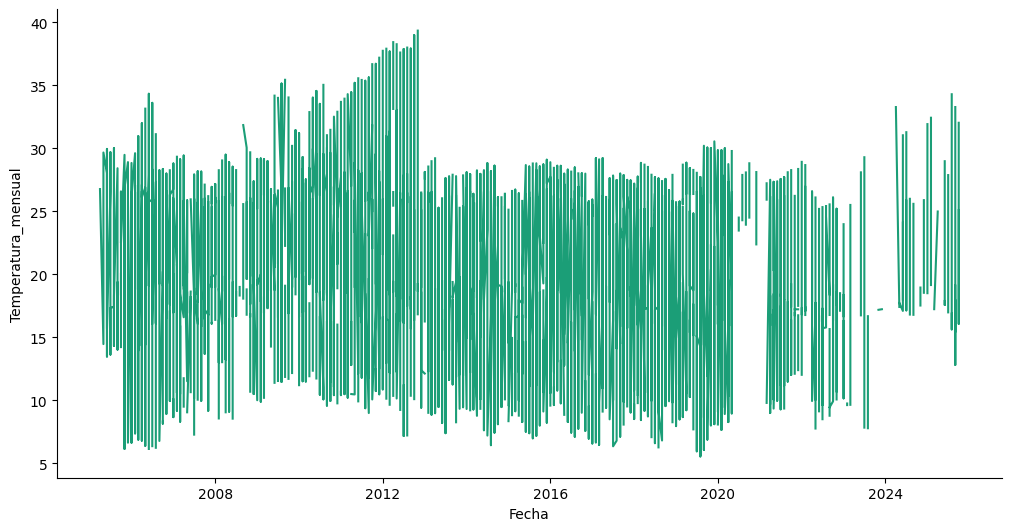

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

def _plot_series_temper(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Fecha']
  ys = series['Temperatura_mensual'] # Corrected typo here

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

# Ensure gdf_subsetdias2 is defined for the current dataset
gdf_subsetdiastm2 = gdf_temp2[['EstacionID', 'Nombre', 'geometry']] # 'Codigo' was already renamed to 'EstacionID'

# Create a new merged GeoDataFrame for the monthly humidity from the current dataset
gjoind_tm_new = pd.merge(
    gdf_subsetdiastm2,
    mensualtemp1,
    on='EstacionID',
    how='inner'
)

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = gjoind_tm_new.sort_values('Fecha', ascending=True) # Used gjoind_tm_new for temperature
_plot_series_temper(df_sorted, '') # Used _plot_series_temper for temperature
sns.despine(fig=fig, ax=ax)
plt.xlabel('Fecha')
_ = plt.ylabel('Temperatura_mensual') # Corrected y-axis label for temperature

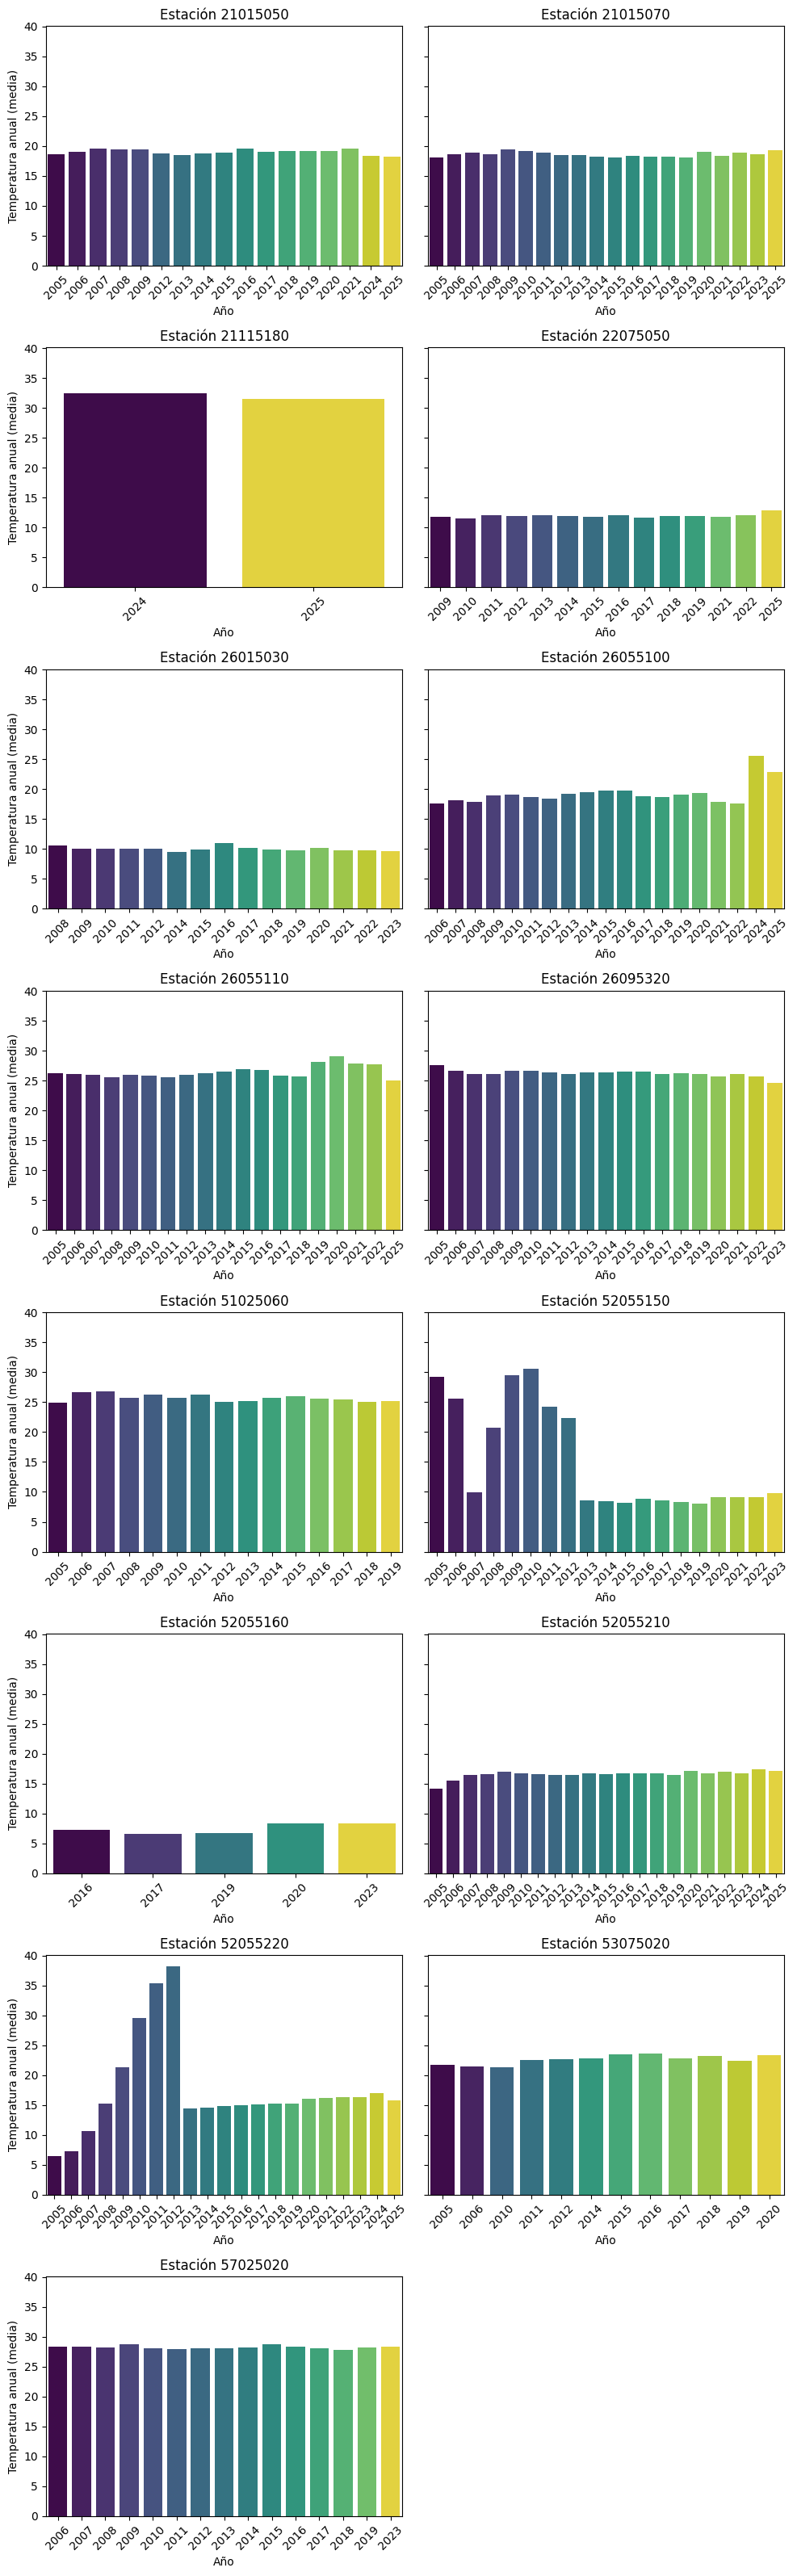

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

# Copia y limpieza mínima
df = gjoind_tm_new.copy()
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
df = df.dropna(subset=['Fecha', 'Temperatura_mensual', 'EstacionID'])

# Lista ordenada de estaciones
estaciones = sorted(df['EstacionID'].unique())

# --- SIN límite ---
max_estaciones = None
if max_estaciones is not None:
    estaciones = estaciones[:max_estaciones]

# --- Crear subplots en grilla (p. ej., 4 por fila) ---
n = len(estaciones)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharey=True)
axes = np.ravel(axes)  # aplanar para iterar fácil

for ax, est in zip(axes, estaciones):
    dfe = df[df['EstacionID'] == est].copy()
    dfe['Year'] = dfe['Fecha'].dt.year

    annual_hum = ( # Renamed variable for clarity
        dfe.groupby('Year', as_index=False)['Temperatura_mensual'] # Changed 'Temperatura' to 'Humedad_mensual'
           .mean()     # usa .sum() si deseas acumulado anual
           .sort_values('Year')
    )
    if annual_hum.empty:
        ax.axis('off')
        continue

    sns.barplot(
        data=annual_hum,
        x='Year', y='Temperatura_mensual', # Changed 'Temperatura' to 'Humedad_mensual'
        hue='Year',          # colores distintos por año
        dodge=False,
        palette='viridis',
        ax=ax
    )
    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_xlabel('Año')
    ax.set_ylabel('Temperatura anual (media)') # Changed label
    ax.set_title(f'Estación {est}')
    ax.tick_params(axis='x', rotation=45)

# Apaga ejes sobrantes si la grilla es mayor que n
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

###**TRATAMIENTO DATOS TEMPERATURA DEL SUELO TRIMESTRAL**

In [ ]:
import pandas as pd
!pip -q install geopandas pyogrio shapely pyproj rtree rasterio folium

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 0. RUTAS A LOS ARCHIVOS CSV
# ============================================================
ruta_temperatura_csv = '/content/drive/MyDrive/TESIS /Temperatura_suelo_unificado.csv'
ruta_evt_csv = '/content/drive/MyDrive/TESIS/salida/INTERPOLACION/rasters_acumuladosdef/eventos_features_excluyentes_definitivos.csv'

# ============================================================
# 1. CARGA DE DATOS
# ============================================================

# Humedad diaria - Asegurando que la fecha sea de tipo datatime
dftemperaturaf = pd.read_csv(ruta_temperatura_csv)
dftemperaturaf['Fecha'] = pd.to_datetime(dftemperaturaf['Fecha'], errors='coerce')

# Eventos de deslizamiento -  Asegurando que la fecha sea de tipo datatime
evt = pd.read_csv(ruta_evt_csv)
evt['Fecha_even'] = pd.to_datetime(evt['Fecha_even'], errors='coerce')

Mounted at /content/drive


In [ ]:
# ============================================================
# 2. DEFINIR AÑO Y TRIMESTRE EN EVENTOS
# ============================================================
# Extraccción de fechas por trimestres de eventos.
evt['Year'] = evt['Fecha_even'].dt.year
evt['Trimestre'] = evt['Fecha_even'].dt.quarter   # trimestre calendario

# Listado único de trimestres donde HAY eventos
trimestres_con_evento = (
    evt[['Year', 'Trimestre']]
    .dropna()
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .reset_index(drop=True)
)

trimestres_con_evento

,Year,Trimestre
0,2005,4
1,2006,1
2,2006,2
3,2006,4
4,2007,1
...,...,...
58,2023,4
59,2024,1
60,2024,2
61,2024,4


In [ ]:
# ============================================================
# 3. HUMEDAD TRIMESTRAL POR ESTACIÓN
# ============================================================
#Extracción de trimestres en información que contiene temperatura.
dftemperaturaf['Year'] = dftemperaturaf['Fecha'].dt.year
dftemperaturaf['Trimestre'] = dftemperaturaf['Fecha'].dt.quarter

tem_trimestral = (
    dftemperaturaf
    .groupby(['EstacionID', 'Year', 'Trimestre'])['Valor']
    .mean()
    .reset_index()
    .rename(columns={'Valor': 'Temperatura_trimestral'})
)

# Limitar la humedad al rango temporal de los eventos
max_year_evt = trimestres_con_evento['Year'].max()
max_q_evt    = trimestres_con_evento[trimestres_con_evento['Year'] == max_year_evt]['Trimestre'].max()

tem_trimestral = tem_trimestral[
    (tem_trimestral['Year'] < max_year_evt) |
    ((tem_trimestral['Year'] == max_year_evt) &
     (tem_trimestral['Trimestre'] <= max_q_evt))
].copy()


In [ ]:
# ============================================================
# 4. CONTAR ESTACIONES POR TRIMESTRE Y DEFINIR UMBRAL
# ============================================================
conteo_trimestretm = (
    tem_trimestral
    .groupby(['Year', 'Trimestre'])['Temperatura_trimestral']
    .apply(lambda x: x.notna().sum())   # solo estaciones con dato NO NaN
    .reset_index(name='N_estaciones')
)

UMBRAL_EST = 7   # umbral mínimo de estaciones con información viable por trimestres

trimestres_no_interpolables = conteo_trimestretm[
    conteo_trimestretm['N_estaciones'] < UMBRAL_EST
]

In [ ]:
trimestres_no_interpolables

,Year,Trimestre,N_estaciones
0,2005,2,6
61,2020,3,3
62,2020,4,3
63,2021,1,4
67,2022,1,6
68,2022,2,6
70,2022,4,6
71,2023,1,6
72,2023,2,4
73,2023,3,4


In [ ]:
# ============================================================
# 5.TRIMESTRES CRÍTICOS QUE TIENEN EVENTOS
# ============================================================
trimestres_con_evento = trimestres_con_evento.drop_duplicates(subset=['Year', 'Trimestre'])

trimestres_no_interpolables = (
    trimestres_no_interpolables
    .merge(trimestres_con_evento, on=['Year', 'Trimestre'], how='inner')
)

# Si no hay ninguno, hum_trimestral_final = hum_trimestral y se termina
if trimestres_no_interpolables.empty:
    hum_trimestral_final = tem_trimestral.copy()
else:
    clim_trimestral = (
        tem_trimestral
        .groupby(['EstacionID', 'Trimestre'])['Temperatura_trimestral']
        .mean()
        .reset_index()
        .rename(columns={'Temperatura_trimestral': 'Temp_clim_trimestral'})
    )


In [ ]:
# ========================================================
# 6. MARCAR TRIMESTRES CRÍTICOS
# ========================================================
criticostm = trimestres_no_interpolables[['Year', 'Trimestre']].drop_duplicates()
criticostm['es_critico'] = True

tem_trimestral_flag = tem_trimestral.merge(
    criticostm,
    on=['Year', 'Trimestre'],
    how='left'
)
tem_trimestral_flag['es_critico'] =tem_trimestral_flag['es_critico'].fillna(False)

# Separar buenos y críticos
base_oktm = tem_trimestral_flag[~tem_trimestral_flag['es_critico']].copy()
base_criticatm = tem_trimestral_flag[tem_trimestral_flag['es_critico']].copy()


/tmp/ipython-input-3242056194.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tem_trimestral_flag['es_critico'] =tem_trimestral_flag['es_critico'].fillna(False)


In [ ]:
base_oktm

,EstacionID,Year,Trimestre,Temperatura_trimestral,es_critico
0,21015050,2005,2,15.700000,False
1,21015050,2005,3,18.769492,False
2,21015050,2005,4,19.864706,False
3,21015050,2006,1,18.697436,False
4,21015050,2006,2,18.708989,False
...,...,...,...,...,...
977,57025020,2021,2,NaN,False
978,57025020,2021,3,NaN,False
979,57025020,2021,4,NaN,False
981,57025020,2022,2,NaN,False


In [ ]:
base_criticatm

,EstacionID,Year,Trimestre,Temperatura_trimestral,es_critico
61,21015050,2020,3,NaN,True
62,21015050,2020,4,NaN,True
63,21015050,2021,1,NaN,True
67,21015050,2022,1,NaN,True
70,21015050,2022,4,NaN,True
...,...,...,...,...,...
983,57025020,2022,4,NaN,True
984,57025020,2023,1,NaN,True
985,57025020,2023,2,28.10,True
986,57025020,2023,3,29.00,True


In [ ]:
# ========================================================
# 7. REEMPLAZAR TRIMESTRES CRÍTICOS POR CLIMATOLOGÍA
# ========================================================
base_criticatm = base_criticatm.merge(
    clim_trimestral,
    on=['EstacionID', 'Trimestre'],
    how='left'
)

# Sustituir valor problemático por la climatología
base_criticatm['Temperatura_trimestral'] = base_criticatm['Temp_clim_trimestral']

# Asegurar mismas columnas que base_ok
base_criticatm = base_criticatm[base_oktm.columns]

In [ ]:
base_criticatm

,EstacionID,Year,Trimestre,Temperatura_trimestral,es_critico
0,21015050,2020,3,18.382472,True
1,21015050,2020,4,19.607213,True
2,21015050,2021,1,19.268339,True
3,21015050,2022,1,19.268339,True
4,21015050,2022,4,19.607213,True
...,...,...,...,...,...
146,57025020,2022,4,27.671088,True
147,57025020,2023,1,28.644374,True
148,57025020,2023,2,28.513238,True
149,57025020,2023,3,28.168635,True


In [ ]:
# ========================================================
# 9. UNIR TODO → SERIE TRIMESTRAL FINAL
# ========================================================
temp_trimestral_final = pd.concat(
        [base_oktm, base_criticatm],
        ignore_index=True
    ).sort_values(['EstacionID', 'Year', 'Trimestre']).reset_index(drop=True)

# Eliminar filas donde Humedad_trimestral es NaN
temp_trimestral_final = temp_trimestral_final.dropna(subset=['Temperatura_trimestral'])

# Revisar resultado
display(temp_trimestral_final.head(20))
print("Número de filas:", len(temp_trimestral_final))


,EstacionID,Year,Trimestre,Temperatura_trimestral,es_critico
0,21015050,2005,2,15.700000,False
1,21015050,2005,3,18.769492,False
2,21015050,2005,4,19.864706,False
3,21015050,2006,1,18.697436,False
4,21015050,2006,2,18.708989,False
5,21015050,2006,3,18.715116,False
6,21015050,2006,4,20.249333,False
7,21015050,2007,1,20.447561,False
8,21015050,2007,2,19.643902,False
9,21015050,2007,3,18.667059,False


Número de filas: 848


In [ ]:
# Ruta donde quieres guardar el archivo
ruta_csv = "/content/drive/MyDrive/TESIS/salida/temp_trimestral_final.csv"

# Exportar a CSV
temp_trimestral_final.to_csv(ruta_csv, index=False)

print("Archivo exportado a:", ruta_csv)

Archivo exportado a: /content/drive/MyDrive/TESIS/salida/temp_trimestral_final.csv


#**INTERPOLACIONES TERRITORIALES**

###**Interpolación Humedad Trimestral**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================================
# 1) Instalación de librerías, rutas y parámetros generales
# ==========================================================
!pip -q install pykrige
import os, numpy as np, pandas as pd, geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from pykrige.ok import OrdinaryKriging
import rasterio
from rasterio.transform import from_origin

# --- Rutas de trabajo máscara del depto de Cauca y carpeta de salida donde se
#     guardará las interpolaciones.

RUTA_MASCARA    = '/content/drive/MyDrive/TESIS /CAUCA/CAUCA.shp'
RUTA_SHAPEHUM   = '/content/drive/MyDrive/TESIS /Humedad/Humedad_Cauca.shp'
RUTA_HUM_TR = '/content/drive/MyDrive/TESIS/salida/hum_trimestral_final.csv'
OUT_RASTERS_DIR = '/content/drive/MyDrive/TESIS/salida/INTERPOLACION/HUMEDAD_TRIM'

os.makedirs(OUT_RASTERS_DIR, exist_ok=True)

# --- CRS de trabajo Origen Único Nacional

CRS_TRABAJO = 9377

# --- Parámetros espaciales y de kriging ---
CELL   = 500          # tamaño de celda (m)
VARIO  = "spherical"  # 'spherical' | 'exponential' | 'gaussian'
NUGGET_FRACCION_DEL_SILL = 1e-5
RANGE_ESCALA = 1.45
N_MIN_PTS = 5         # mínimo de estaciones por trimestre
SKIP_IF_EXISTS = True # si el TIFF ya existe, no recalcula


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.7 MB/s eta 0:00:00


In [ ]:
# =====================
# 2) Máscara y rejilla
# =====================
gdf_masc = gpd.read_file(RUTA_MASCARA).to_crs(CRS_TRABAJO)
mask_poly = unary_union(gdf_masc.geometry)

minx, miny, maxx, maxy = gdf_masc.total_bounds #Límites del dpt.
nx = int(np.floor((maxx - minx)/CELL))
ny = int(np.floor((maxy - miny)/CELL)) #  Permite crear una especie de malla a través de puntos que se ajusta al territorio de acuerdo al
                                       #  tamaño de celda específicado para el procesamiento

xs = minx + CELL/2.0 + CELL*np.arange(nx)       # Crea las coordenadas de la malla
ys = maxy - CELL/2.0 - CELL*np.arange(ny)

grid_points, grid_idx = [], []             # Selecciona solo los puntos que caigan dentro del Cauca
for iy, yy in enumerate(ys):
    for ix, xx in enumerate(xs):
        p = Point(xx, yy)
        if mask_poly.contains(p):
            grid_points.append(p)
            grid_idx.append((iy, ix))

pred_x = np.array([p.x for p in grid_points], dtype="float64")      # Extrae las coordenadas X e Y para usarlas en el kriging
pred_y = np.array([p.y for p in grid_points], dtype="float64")


In [ ]:
# ============================================================
# 3) Funciones auxiliares (deduplicación, rango, IDW, kriging seguro)
# ============================================================
def dedup_trim_gdf(gdf, col_val, decimals=0):
    """Agrupa puntos casi coincidentes para evitar problemas numéricos."""
    tmp = gdf.copy()
    tmp["x"] = tmp.geometry.x
    tmp["y"] = tmp.geometry.y
    tmp["xr"] = tmp["x"].round(decimals)
    tmp["yr"] = tmp["y"].round(decimals)
    g = tmp.groupby(["xr", "yr"], as_index=False)[col_val].mean()
    x = g["xr"].to_numpy(float)
    y = g["yr"].to_numpy(float)
    z = g[col_val].to_numpy(float)
    return x, y, z

def suggest_range_xy(x, y):
    """Rango sugerido para el variograma a partir del 3er vecino más cercano."""
    xy = np.c_[x, y]
    if xy.shape[0] < 4:
        return 20000.0
    D = np.sqrt(((xy[None,:,:]-xy[:,None,:])**2).sum(axis=2))
    D.sort(axis=1)
    d3 = np.median(D[:,3]) if D.shape[1] > 3 else np.median(D[:,-1])
    return float(3.0 * d3)

def idw_predict(x, y, z, px, py, k=12, p=2.0):
    """IDW como respaldo en dado caso que kriging no funcione."""
    tree = cKDTree(np.c_[x,y])
    dists, idxs = tree.query(np.c_[px,py], k=min(k, len(x)))
    dists = np.atleast_2d(dists); idxs = np.atleast_2d(idxs)
    w = 1.0 / np.maximum(dists, 1e-6)**p
    num = (w * z[idxs]).sum(axis=1)
    den = w.sum(axis=1)
    return (num/den).astype("float32")

def krige_predict_safe(x, y, z, px, py, variogram_model, base_range, base_nugget, sill):
    """Kriging robusto con reintentos y fallback a IDW."""
    if sill < 1e-6:
        # Muy poca variabilidad: devuelve una constante (media)
        return np.full(len(px), float(np.mean(z)), dtype="float32"), {"mode":"const"}

    nug_scales = [1, 2, 4, 8, 16]
    rng_scales = [1.0, 1.5, 2.0]

    for rs in rng_scales:
        for ns in nug_scales:
            vrng = max(base_range * rs, 1.0)
            vnug = max(base_nugget * ns, 1e-6 * max(sill, 1.0))
            vsill = max(sill, 1e-6)
            try:
                OK = OrdinaryKriging(
                    x, y, z,
                    variogram_model=variogram_model,
                    variogram_parameters={"sill": vsill, "range": vrng, "nugget": vnug},
                    enable_plotting=False
                )
                z_pred, _ = OK.execute("points", px, py)
                return np.asarray(z_pred, dtype="float32"), {
                    "mode":"ok",
                    "sill":vsill,
                    "range":vrng,
                    "nugget":vnug
                }
            except Exception:
                pass

    # Si todo falla, usar IDW
        return idw_predict(x, y, z, px, py, k=min(12, len(x))), {"mode":"idw"}


In [ ]:
# ============================================================
# 4) Preparar datos de humedad con geometría
# ============================================================

gdf_esthum = gpd.read_file(RUTA_SHAPEHUM)

# Seleccionar columnar relevantes de las estaciones que proporcionan humedad del Suelo asi como renommbrar la columna 'CODIGO' a 'EstacionID'
gdf_subsetdias2 = gdf_esthum[['Codigo', 'Nombre', 'geometry']].rename(columns={'Codigo': 'EstacionID'})

hum_trimestral_final= pd.read_csv(RUTA_HUM_TR)

# Unir humedad trimestral con geometría de estaciones
gdf_hum = hum_trimestral_final.merge(
    gdf_subsetdias2[['EstacionID', 'geometry']],
    on='EstacionID',
    how='inner'
)

gdf_hum = gpd.GeoDataFrame(gdf_hum, geometry='geometry', crs=gdf_subsetdias2.crs).to_crs(CRS_TRABAJO)

# Eliminar posibles NaN residuales
gdf_hum = gdf_hum.dropna(subset=['Humedad_trimestral'])

# Lista de trimestres existentes (Year, Trimestre)
trimestres_unicos = (
    gdf_hum[['Year', 'Trimestre']]
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .to_records(index=False)
)

print("Número de trimestres a interpolar:", len(trimestres_unicos))


Número de trimestres a interpolar: 79


In [ ]:
# ==========================================
# 5) Bucle de interpolación por trimestre
# ==========================================
log_rows = []  # Lista donde se guardan diccionarios con inforjmación de cada trimestre
generados = omitidos = 0 #Contador de raster generados

for year, trim in trimestres_unicos:
    print(f"\n=== Interpolando {year}-T{trim} ===")
    out_tif = os.path.join(OUT_RASTERS_DIR, f"humedad_{year}_T{trim}.tif")

    if SKIP_IF_EXISTS and os.path.exists(out_tif):
        print("  -> Ya existe, se omite (reanudar).")
        generados += 1
        continue

    # Filtrar estaciones de ese trimestre
    sub = gdf_hum[
        (gdf_hum['Year'] == year) &
        (gdf_hum['Trimestre'] == trim)
    ].dropna(subset=['Humedad_trimestral'])

    n_est = len(sub)
    print("  Estaciones con dato:", n_est)

    if n_est < N_MIN_PTS:
        print("  -> Muy pocas estaciones, se omite trimestre.")
        omitidos += 1
        continue

    # Deduplicación espacial
    x, y, z = dedup_trim_gdf(sub, 'Humedad_trimestral', decimals=0)
    if len(x) < 3:
        print("  -> Menos de 3 puntos tras deduplicar, se omite.")
        omitidos += 1
        continue

    # Parámetros de variograma
    sill = float(np.var(z))
    rng0 = suggest_range_xy(x, y) * float(RANGE_ESCALA)
    nug0 = float(NUGGET_FRACCION_DEL_SILL) * max(sill, 1e-6)

    # Kriging seguro (con fallback a IDW si falla)
    z_pred, info = krige_predict_safe(
        x, y, z,
        pred_x, pred_y,
        variogram_model=VARIO,
        base_range=rng0,
        base_nugget=nug0,
        sill=sill
    )

    z_pred[z_pred < 0] = 0.0

    # Ensamblar al grid
    z_grid = np.full((ny, nx), np.nan, dtype="float32")
    for (iy, ix), v in zip(grid_idx, z_pred):
        z_grid[iy, ix] = v

    # Escribir GeoTIFF
    transform = from_origin(minx, maxy, CELL, CELL)
    with rasterio.open(
        out_tif, "w", driver="GTiff",
        height=ny, width=nx, count=1, dtype="float32",
        crs=gdf_masc.crs, transform=transform,
        nodata=np.nan, compress="DEFLATE"
    ) as dst:
        dst.write(z_grid, 1)

    print("  -> Ráster generado:", out_tif)
    print("     modo:", info.get("mode"),
          "| sill:", sill,
          "| rango_inicial:", rng0,
          "| nugget_inicial:", nug0)

    log_rows.append({
        "year": int(year),
        "trimestre": int(trim),
        "n_estaciones": int(n_est),
        "n_unicas": int(len(x)),
        "sill": sill,
        "range_inicial": rng0,
        "nugget_inicial": nug0,
        "modo": info.get("mode")
    })
    generados += 1

print("\nRásteres generados:", generados, "| Trimestres omitidos:", omitidos)

# Guardar log
if log_rows:
    df_log = pd.DataFrame(log_rows)
    log_path = os.path.join(OUT_RASTERS_DIR, "_log_parametros_por_trimestre.csv")
    df_log.to_csv(log_path, index=False)
    print("Log de parámetros guardado en:", log_path)



=== Interpolando 2005-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2005-T3 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2005-T4 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T1 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T3 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T4 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T1 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T3 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T4 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2008-T1 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2008-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2008-T3 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2008-T4 ===
  -> Ya existe, se omite (reanud

Las interpolaciones demuestran que no fue posible realizar la interpolación de 7 trimestres, esto debido a que no se cuenta con la información de al menos 5 estaciones; en algunos caso solo 1 estación tiene dato de humedad.

###**Interpolación Temperatura Trimestral**

In [ ]:
# ==========================================================
# 1) Instalación de librerías, rutas y parámetros generales
# ==========================================================
!pip -q install pykrige
import os, numpy as np, pandas as pd, geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from pykrige.ok import OrdinaryKriging
import rasterio
from rasterio.transform import from_origin

# --- Rutas de trabajo máscara del depto de Cauca y carpeta de salida donde se
#     guardará las interpolaciones.

RUTA_MASCARA    = '/content/drive/MyDrive/TESIS /CAUCA/CAUCA.shp'
RUTA_SHAPETEM   = '/content/drive/MyDrive/TESIS /Temperatura/Temperatura_Cauca.shp'
RUTA_TEMP_TR = '/content/drive/MyDrive/TESIS/salida/temp_trimestral_final.csv'
OUT_RASTERS_DIR = '/content/drive/MyDrive/TESIS/salida/INTERPOLACION/TEMPERATURA_TRIM'

os.makedirs(OUT_RASTERS_DIR, exist_ok=True)

# --- CRS de trabajo Origen Único Nacional

CRS_TRABAJO = 9377

# --- Parámetros espaciales y de kriging ---
CELL   = 500          # tamaño de celda (m)
VARIO  = "spherical"  # 'spherical' | 'exponential' | 'gaussian'
NUGGET_FRACCION_DEL_SILL = 1e-5
RANGE_ESCALA = 1.45
N_MIN_PTS = 5         # mínimo de estaciones por trimestre
SKIP_IF_EXISTS = True # si el TIFF ya existe, no recalcula

In [ ]:
# =====================
# 2) Máscara y rejilla
# =====================
gdf_masc = gpd.read_file(RUTA_MASCARA).to_crs(CRS_TRABAJO)
mask_poly = unary_union(gdf_masc.geometry)

minx, miny, maxx, maxy = gdf_masc.total_bounds #Límites del dpt.
nx = int(np.floor((maxx - minx)/CELL))
ny = int(np.floor((maxy - miny)/CELL)) #  Permite crear una especie de malla a través de puntos que se ajusta al territorio de acuerdo al
                                       #  tamaño de celda específicado para el procesamiento

xs = minx + CELL/2.0 + CELL*np.arange(nx)       # Crea las coordenadas de la malla
ys = maxy - CELL/2.0 - CELL*np.arange(ny)

grid_points, grid_idx = [], []             # Selecciona solo los puntos que caigan dentro del Cauca
for iy, yy in enumerate(ys):
    for ix, xx in enumerate(xs):
        p = Point(xx, yy)
        if mask_poly.contains(p):
            grid_points.append(p)
            grid_idx.append((iy, ix))

pred_x = np.array([p.x for p in grid_points], dtype="float64")      # Extrae las coordenadas X e Y para usarlas en el kriging
pred_y = np.array([p.y for p in grid_points], dtype="float64")


In [ ]:
# ============================================================
# 3) Funciones auxiliares (deduplicación, rango, IDW, kriging seguro)
# ============================================================
def dedup_trim_gdf(gdf, col_val, decimals=0):
    """Agrupa puntos casi coincidentes para evitar problemas numéricos."""
    tmp = gdf.copy()
    tmp["x"] = tmp.geometry.x
    tmp["y"] = tmp.geometry.y
    tmp["xr"] = tmp["x"].round(decimals)
    tmp["yr"] = tmp["y"].round(decimals)
    g = tmp.groupby(["xr", "yr"], as_index=False)[col_val].mean()
    x = g["xr"].to_numpy(float)
    y = g["yr"].to_numpy(float)
    z = g[col_val].to_numpy(float)
    return x, y, z

def suggest_range_xy(x, y):
    """Rango sugerido para el variograma a partir del 3er vecino más cercano."""
    xy = np.c_[x, y]
    if xy.shape[0] < 4:
        return 20000.0
    D = np.sqrt(((xy[None,:,:]-xy[:,None,:])**2).sum(axis=2))
    D.sort(axis=1)
    d3 = np.median(D[:,3]) if D.shape[1] > 3 else np.median(D[:,-1])
    return float(3.0 * d3)

def idw_predict(x, y, z, px, py, k=12, p=2.0):
    """IDW como respaldo en dado caso que kriging no funcione."""
    tree = cKDTree(np.c_[x,y])
    dists, idxs = tree.query(np.c_[px,py], k=min(k, len(x)))
    dists = np.atleast_2d(dists); idxs = np.atleast_2d(idxs)
    w = 1.0 / np.maximum(dists, 1e-6)**p
    num = (w * z[idxs]).sum(axis=1)
    den = w.sum(axis=1)
    return (num/den).astype("float32")

def krige_predict_safe(x, y, z, px, py, variogram_model, base_range, base_nugget, sill):
    """Kriging robusto con reintentos y fallback a IDW."""
    if sill < 1e-6:
        # Muy poca variabilidad: devuelve una constante (media)
        return np.full(len(px), float(np.mean(z)), dtype="float32"), {"mode":"const"}

    nug_scales = [1, 2, 4, 8, 16]
    rng_scales = [1.0, 1.5, 2.0]

    for rs in rng_scales:
        for ns in nug_scales:
            vrng = max(base_range * rs, 1.0)
            vnug = max(base_nugget * ns, 1e-6 * max(sill, 1.0))
            vsill = max(sill, 1e-6)
            try:
                OK = OrdinaryKriging(
                    x, y, z,
                    variogram_model=variogram_model,
                    variogram_parameters={"sill": vsill, "range": vrng, "nugget": vnug},
                    enable_plotting=False
                )
                z_pred, _ = OK.execute("points", px, py)
                return np.asarray(z_pred, dtype="float32"), {
                    "mode":"ok",
                    "sill":vsill,
                    "range":vrng,
                    "nugget":vnug
                }
            except Exception:
                pass

    # Si todo falla, usar IDW
        return idw_predict(x, y, z, px, py, k=min(12, len(x))), {"mode":"idw"}


In [ ]:
# ============================================================
# 4) Preparar datos de humedad con geometría
# ============================================================

gdf_estemp = gpd.read_file(RUTA_SHAPETEM)

# Seleccionar columnar relevantes de las estaciones que proporcionan humedad del Suelo asi como renommbrar la columna 'CODIGO' a 'EstacionID'
gdf_subsetdias2 = gdf_estemp[['Codigo', 'Nombre', 'geometry']].rename(columns={'Codigo': 'EstacionID'})

temp_trimestral_final= pd.read_csv(RUTA_TEMP_TR)

# Unir humedad trimestral con geometría de estaciones
gdf_tem = temp_trimestral_final.merge(
    gdf_subsetdias2[['EstacionID', 'geometry']],
    on='EstacionID',
    how='inner'
)

gdf_tem = gpd.GeoDataFrame(gdf_tem, geometry='geometry', crs=gdf_subsetdias2.crs).to_crs(CRS_TRABAJO)

# Eliminar posibles NaN residuales
gdf_tem = gdf_tem.dropna(subset=['Temperatura_trimestral'])

# Lista de trimestres existentes (Year, Trimestre)
trimestres_unicos = (
    gdf_tem[['Year', 'Trimestre']]
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .to_records(index=False)
)

print("Número de trimestres a interpolar:", len(trimestres_unicos))


Número de trimestres a interpolar: 80


In [ ]:
# ==========================================
# 5) Bucle de interpolación por trimestre
# ==========================================
log_rows = []  # Lista donde se guardan diccionarios con inforjmación de cada trimestre
generados = omitidos = 0 #Contador de raster generados

for year, trim in trimestres_unicos:
    print(f"\n=== Interpolando {year}-T{trim} ===")
    out_tif = os.path.join(OUT_RASTERS_DIR, f"temperatura_{year}_T{trim}.tif")

    if SKIP_IF_EXISTS and os.path.exists(out_tif):
        print("  -> Ya existe, se omite (reanudar).")
        generados += 1
        continue

    # Filtrar estaciones de ese trimestre
    sub = gdf_tem[
        (gdf_tem['Year'] == year) &
        (gdf_tem['Trimestre'] == trim)
    ].dropna(subset=['Temperatura_trimestral'])

    n_est = len(sub)
    print("  Estaciones con dato:", n_est)

    if n_est < N_MIN_PTS:
        print("  -> Muy pocas estaciones, se omite trimestre.")
        omitidos += 1
        continue

    # Deduplicación espacial
    x, y, z = dedup_trim_gdf(sub, 'Temperatura_trimestral', decimals=0)
    if len(x) < 3:
        print("  -> Menos de 3 puntos tras deduplicar, se omite.")
        omitidos += 1
        continue

    # Parámetros de variograma
    sill = float(np.var(z))
    rng0 = suggest_range_xy(x, y) * float(RANGE_ESCALA)
    nug0 = float(NUGGET_FRACCION_DEL_SILL) * max(sill, 1e-6)

    # Kriging seguro (con fallback a IDW si falla)
    z_pred, info = krige_predict_safe(
        x, y, z,
        pred_x, pred_y,
        variogram_model=VARIO,
        base_range=rng0,
        base_nugget=nug0,
        sill=sill
    )

    z_pred[z_pred < 0] = 0.0

    # Ensamblar al grid
    z_grid = np.full((ny, nx), np.nan, dtype="float32")
    for (iy, ix), v in zip(grid_idx, z_pred):
        z_grid[iy, ix] = v

    # Escribir GeoTIFF
    transform = from_origin(minx, maxy, CELL, CELL)
    with rasterio.open(
        out_tif, "w", driver="GTiff",
        height=ny, width=nx, count=1, dtype="float32",
        crs=gdf_masc.crs, transform=transform,
        nodata=np.nan, compress="DEFLATE"
    ) as dst:
        dst.write(z_grid, 1)

    print("  -> Ráster generado:", out_tif)
    print("     modo:", info.get("mode"),
          "| sill:", sill,
          "| rango_inicial:", rng0,
          "| nugget_inicial:", nug0)

    log_rows.append({
        "year": int(year),
        "trimestre": int(trim),
        "n_estaciones": int(n_est),
        "n_unicas": int(len(x)),
        "sill": sill,
        "range_inicial": rng0,
        "nugget_inicial": nug0,
        "modo": info.get("mode")
    })
    generados += 1

print("\nRásteres generados:", generados, "| Trimestres omitidos:", omitidos)

# Guardar log
if log_rows:
    df_log = pd.DataFrame(log_rows)
    log_path = os.path.join(OUT_RASTERS_DIR, "_log_parametros_por_trimestre.csv")
    df_log.to_csv(log_path, index=False)
    print("Log de parámetros guardado en:", log_path)



=== Interpolando 2005-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2005-T3 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2005-T4 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T1 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T3 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2006-T4 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T1 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T3 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2007-T4 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2008-T1 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2008-T2 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2008-T3 ===
  -> Ya existe, se omite (reanudar).

=== Interpolando 2008-T4 ===
  -> Ya existe, se omite (reanud

# **ASIGNACIÓN HUMEDAD Y TEMPERATURA A CADA EVENTO DE DESLIZAMIENTO**

## **Humedad del suelo**

In [ ]:
# ============================
# INSTALACIÓN DE LIBRERÍAS
# ============================

!pip install -q geopandas rasterio shapely fiona pyproj
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# =============================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =============================
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

# =================================
# 2. RUTAS Y PARÁMETROS GENERALES
# =================================

# Ruta del archivo de eventos

RUTA_EVENTOS = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/evt_precifinal.gpkg"

# Ruta HUMEDAD TRIMESTAL FINAL
ruta_humfinal = "/content/drive/MyDrive/TESIS/salida/hum_trimestral_final.csv"

# Ruta donde están los rásteres trimestrales de humedad
OUT_RASTERS_DIR = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/HUMEDAD_TRIM"


# CRS de trabajo
CRS_TRABAJO = 9377

# Nombre de la columna de fecha y opcionalmente del código del evento
COL_FECHA_EVT = "Fecha_even"
COL_ID_EVT    = "Código_SIMMA"

# Nombre de la columna donde se guardará el valor de humedad en el punto del evento
COL_HUM_EVT = "Humedad_trim_evt"




Mounted at /content/drive


In [ ]:
hum_trimestral_fina = pd.read_csv(ruta_humfinal)
gdf_evt = gpd.read_file(RUTA_EVENTOS)

In [ ]:
gdf_evt = gdf_evt.to_crs(CRS_TRABAJO)
print("Eventos reproyectados a CRS:", CRS_TRABAJO)

Eventos reproyectados a CRS: 9377


In [ ]:

# ===============================
# 3. AÑO Y TRIMESTRE DEL EVENTO
# ===============================
# Asegurar que la fecha está en formato datetime
gdf_evt[COL_FECHA_EVT] = pd.to_datetime(gdf_evt[COL_FECHA_EVT], errors='coerce')

# Año y trimestre
gdf_evt['Year'] = gdf_evt[COL_FECHA_EVT].dt.year
gdf_evt['Trimestre'] = gdf_evt[COL_FECHA_EVT].dt.quarter

# Inicializar columna de humedad en eventos
gdf_evt[COL_HUM_EVT] = np.nan


In [ ]:
# ============================================================
# 4. LISTA DE COMBINACIONES AÑO–TRIMESTRE PRESENTES EN LOS EVENTOS
# ============================================================
trims_evt = (
    gdf_evt[['Year', 'Trimestre']]
    .dropna()
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .to_records(index=False)
)

print("Combinaciones Año–Trimestre con eventos:", len(trims_evt))
print(trims_evt)

Combinaciones Año–Trimestre con eventos: 63
[(2005, 4) (2006, 1) (2006, 2) (2006, 4) (2007, 1) (2007, 2) (2008, 1)
 (2008, 2) (2008, 4) (2009, 1) (2009, 4) (2010, 1) (2010, 2) (2010, 3)
 (2010, 4) (2011, 1) (2011, 2) (2011, 4) (2012, 1) (2012, 2) (2012, 3)
 (2012, 4) (2013, 1) (2013, 2) (2013, 3) (2013, 4) (2014, 1) (2014, 2)
 (2014, 4) (2015, 1) (2015, 2) (2015, 4) (2016, 1) (2016, 2) (2016, 4)
 (2017, 1) (2017, 2) (2017, 3) (2017, 4) (2018, 1) (2018, 2) (2018, 4)
 (2019, 1) (2019, 2) (2019, 3) (2019, 4) (2020, 1) (2020, 2) (2020, 3)
 (2020, 4) (2021, 1) (2021, 2) (2022, 1) (2022, 3) (2022, 4) (2023, 1)
 (2023, 2) (2023, 3) (2023, 4) (2024, 1) (2024, 2) (2024, 4) (2025, 1)]


In [ ]:
# ============================================================
# 5. ASIGNAR HUMEDAD TRIMESTRAL A CADA EVENTO
# ============================================================
for year, trim in trims_evt:
    print(f"\n=== Asignando humedad a eventos de {year}-T{int(trim)} ===")

    # Subconjunto de eventos en ese trimestre
    mask = (gdf_evt['Year'] == year) & (gdf_evt['Trimestre'] == trim)
    sub_evt = gdf_evt[mask]

    if sub_evt.empty:
        print("  -> No hay eventos en este trimestre.")
        continue

    # Nombre y ruta del ráster trimestral correspondiente
    tif_name = f"humedad_{int(year)}_T{int(trim)}.tif"
    tif_path = os.path.join(OUT_RASTERS_DIR, tif_name)

    if not os.path.exists(tif_path):
        print(f"  -> No existe el ráster {tif_path}. Se dejan NaN para estos eventos.")
        continue

    print("  -> Usando ráster:", tif_path)

    # Abrir ráster y muestrear
    with rasterio.open(tif_path) as src:
        # Coordenadas X,Y de los eventos de cada trimestre
        xs = sub_evt.geometry.x.to_numpy()
        ys = sub_evt.geometry.y.to_numpy()

        coords = list(zip(xs, ys))

        # Extraer valores del pixel de las coordenadas de cada evento de acuerdo al trimestre en que suceden
        vals = list(src.sample(coords))
        vals = np.array([v[0] for v in vals], dtype="float32")

        # Manejo de nodata, si el evento cae fuera de la máscara o en una celda sin datos, el valor se convierte a NaN

        if src.nodata is not None:
             vals[vals == src.nodata] = np.nan

        # Asignar al GeoDataFrame original
        # Cada evento queda con un atributo:Humedad del suelo correspondiente al trimestre y ubicación del deslizamiento
        gdf_evt.loc[mask, COL_HUM_EVT] = vals

print("\nAsignación de humedad trimestral a eventos completada.")


=== Asignando humedad a eventos de 2005-T4 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/HUMEDAD_TRIM/humedad_2005_T4.tif

=== Asignando humedad a eventos de 2006-T1 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/HUMEDAD_TRIM/humedad_2006_T1.tif

=== Asignando humedad a eventos de 2006-T2 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/HUMEDAD_TRIM/humedad_2006_T2.tif

=== Asignando humedad a eventos de 2006-T4 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/HUMEDAD_TRIM/humedad_2006_T4.tif

=== Asignando humedad a eventos de 2007-T1 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/HUMEDAD_TRIM/humedad_2007_T1.tif

=== Asignando humedad a eventos de 2007-T2 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/HUMEDAD_TRIM/humedad_2007_T2.tif

=== Asignando humedad a eventos de 2008-T1 ===
  -> Usando ráster: /content/drive/MyDrive/TES

In [ ]:
nan_total = gdf_evt[ gdf_evt['Humedad_trim_evt'].isna() ]
print("Total de eventos con NaN:", len(nan_total))

Total de eventos con NaN: 74


In [ ]:
gdf_evt.head(5)

,Código_SIMMA,Fecha_even,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d,geometry,Year,Trimestre,Humedad_trim_evt
0,55407,2017-01-01,36.844872,5.874406,37.138309,40.220291,63.695595,115.281158,237.591827,480.294464,...,2016-12-29,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,POINT (4583098.897 1848740.684),2017,1,41.291389
1,54574,2017-01-01,6.179742,1.064228,5.577220,24.622925,24.642332,32.581276,84.214172,129.889084,...,2016-12-29,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,POINT (4597810.822 1787483.734),2017,1,47.675392
2,54577,2017-01-01,5.944658,0.377572,5.067153,23.586582,23.814753,32.441280,86.930855,134.534241,...,2016-12-29,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,POINT (4596153.46 1788280.035),2017,1,46.556534
3,50565,2017-01-01,6.797357,1.865946,14.819960,34.755085,41.031158,54.929142,145.380035,242.637421,...,2016-12-29,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,POINT (4588528.776 1798791.083),2017,1,40.749325
4,48975,2017-01-01,16.849848,16.388405,82.239388,113.653938,152.335983,194.263687,295.535828,541.196533,...,2016-12-29,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,POINT (4572103.415 1858110.179),2017,1,39.335461


In [ ]:
# 1. Subconjunto de eventos con NaN en humedad
nan_total = gdf_evt[gdf_evt['Humedad_trim_evt'].isna()]
print("Total de eventos con NaN:", len(nan_total))

# 2. Conteo por año y trimestre
nan_por_trim = (
    nan_total
    .groupby(['Year', 'Trimestre'])
    .size()
    .reset_index(name='N_eventos_NaN')
    .sort_values(['Year', 'Trimestre'])
)

print("\nNaN por año y trimestre:")
print(nan_por_trim)

# 3. Ver filas específicas (opcional)
nan_total[[COL_ID_EVT, COL_FECHA_EVT, 'Year', 'Trimestre', COL_HUM_EVT]].head(5)


Total de eventos con NaN: 74

NaN por año y trimestre:
   Year  Trimestre  N_eventos_NaN
0  2020          3             16
1  2020          4             32
2  2023          2             13
3  2023          3              1
4  2023          4              3
5  2024          1              1
6  2025          1              8


,Código_SIMMA,Fecha_even,Year,Trimestre,Humedad_trim_evt
367,55403,2020-07-01,2020,3,NaN
368,46198,2020-07-02,2020,3,NaN
369,46197,2020-07-02,2020,3,NaN
370,55729,2020-07-19,2020,3,NaN
371,55264,2020-08-01,2020,3,NaN


In [ ]:
est_problem = (
    nan_total
    .groupby('Código_SIMMA')
    .size()

)

print(est_problem)

Código_SIMMA
46197    1
46198    1
50583    1
51018    1
51966    1
        ..
70317    1
70325    1
70328    1
70332    1
70337    1
Length: 74, dtype: int64


**Dado a la inexistencia de información en al menos 6 estaciones, no fue posible generar todas las interpolaciones, por tal motivo, 74 eventos de deslizamientos, no tienen dato de humedad de suelo asociada, distinguiendo como trimestres problemáticos los dos últimos trimestres de 2020, el trimestre 2,3 y 4 de 2023 y el primer trimestre del año 2024 y 2025; en total son 7 trimestres con problemas.**

**Por tal razón, para estas situaciones problemáticas, se planteó calcular la  climatología trimestral de la humedad del suelo. Para ello, se recopilaron todas las observaciones históricas disponibles de humedad del suelo correspondientes a un mismo trimestre del año, independientemente del año de registro. Posteriormente, para cada estación, se calculó el promedio aritmético de la humedad del suelo considerando exclusivamente los registros válidos de dicho trimestre a lo largo de toda la serie temporal.**

**A partir de estos valores promedio trimestrales por estación, se generaron superficies espaciales continuas mediante interpolación geoestadística utilizando el método de kriging ordinario. De este modo, se construyó un ráster climatológico para cada trimestre del año, el cual representa el patrón espacial típico de la humedad del suelo bajo condiciones medias multianuales. Estas superficies climatológicas fueron empleadas únicamente en los casos en que no fue posible generar interpolaciones trimestrales específicas para un año determinado.**

In [ ]:
# 1) Trimestres únicos que requieren climatología (solo 1..4)
trimestres_clim_necesarios = sorted(nan_por_trim['Trimestre'].unique().astype(int).tolist())
print("\nTrimestres que requieren climatología:", trimestres_clim_necesarios)


Trimestres que requieren climatología: [1, 2, 3, 4]


In [ ]:
# ------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------
!pip install pykrige
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
from shapely.geometry import Point
from shapely.ops import unary_union
from pykrige.ok import OrdinaryKriging
from scipy.spatial import cKDTree

# ------------------------------------------------------------
# 2. PARÁMETROS GENERALES (AJUSTABLES)
# ------------------------------------------------------------
CRS_TRABAJO = 9377                 # MAGNA-SIRGAS / Colombia Bogota
CELL = 500                         # Tamaño de píxel (m)
VARIO = "spherical"                # Modelo de variograma
RANGE_ESCALA = 1.45                # Factor de ajuste del rango
NUGGET_FRACCION_DEL_SILL = 1e-5    # Nugget como fracción del sill
UMBRAL_ESTACIONES = 6
TRIMESTRES = trimestres_clim_necesarios         # Trimestres climatológicos

In [ ]:
RUTA_SHAPEHUM = '/content/drive/MyDrive/TESIS /Humedad/Humedad_Cauca.shp'
RUTA_MASCARA    = '/content/drive/MyDrive/TESIS /CAUCA/CAUCA.shp'
RUTA_HUM_TR      = '/content/drive/MyDrive/TESIS/salida/hum_trimestral_final.csv'
OUT_RASTERS_CLIM_HUM = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/CLIM_HUMEDAD_TRIM"
OUT_RASTERS_HUM = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/HUMEDAD_TRIM"
os.makedirs(OUT_RASTERS_CLIM_HUM, exist_ok=True)

In [ ]:
# ------------------------------------------------------------
# 3. CARGA DE DATOS
# ------------------------------------------------------------
#  Estaciones
gdf_est = gpd.read_file(RUTA_SHAPEHUM).to_crs(CRS_TRABAJO)

# Asegurar identificador de estación
if "EstacionID" not in gdf_est.columns:
    gdf_est = gdf_est.rename(columns={"Codigo": "EstacionID"})

# 4.2 Datos de humedad trimestral por estación
df_hum = pd.read_csv(RUTA_HUM_TR)


In [ ]:
# ------------------------------------------------------------
# 4. CÁLCULO DE CLIMATOLOGÍA TRIMESTRAL POR ESTACIÓN
# ------------------------------------------------------------
clim_hum = (
    df_hum
    .dropna(subset=["Humedad_trimestral"])
    .groupby(["EstacionID", "Trimestre"], observed=True)
    ["Humedad_trimestral"]
    .mean()
    .reset_index()
    .rename(columns={"Humedad_trimestral": "Humedad_clim"})
)

# Unir climatología con geometría
gdf_clim = clim_hum.merge(
    gdf_est[["EstacionID", "geometry"]],
    on="EstacionID",
    how="inner"
)
gdf_clim = gpd.GeoDataFrame(gdf_clim, geometry="geometry", crs=CRS_TRABAJO)

In [ ]:
gdf_clim.head(3)

,EstacionID,Trimestre,Humedad_clim,geometry
0,21015040,1,56.395635,POINT (4653634.186 1781739.064)
1,21015040,2,54.870898,POINT (4653634.186 1781739.064)
2,21015040,3,61.201678,POINT (4653634.186 1781739.064)


In [ ]:
# =====================
# 5) Máscara y rejilla
# =====================
gdf_mask = gpd.read_file(RUTA_MASCARA).to_crs(CRS_TRABAJO)
mask_poly = unary_union(gdf_mask.geometry)

minx, miny, maxx, maxy = gdf_mask.total_bounds #Límites del dpt.
nx = int(np.floor((maxx - minx)/CELL))
ny = int(np.floor((maxy - miny)/CELL)) #  Permite crear una especie de malla a través de puntos que se ajusta al territorio de acuerdo al
                                       #  tamaño de celda específicado para el procesamiento

xs = minx + CELL/2.0 + CELL*np.arange(nx)       # Crea las coordenadas de la malla
ys = maxy - CELL/2.0 - CELL*np.arange(ny)

grid_points, grid_idx = [], []             # Selecciona solo los puntos que caigan dentro del Cauca

for iy, yy in enumerate(ys):
    for ix, xx in enumerate(xs):
        p = Point(xx, yy)
        if mask_poly.contains(p):
            grid_points.append(p)
            grid_idx.append((iy, ix))

pred_x = np.array([p.x for p in grid_points], dtype="float64")      # Extrae las coordenadas X e Y para usarlas en el kriging
pred_y = np.array([p.y for p in grid_points], dtype="float64")

In [ ]:
# ============================================================
# 6) Funciones auxiliares de intgerpolación
# ============================================================
def dedup_trim_gdf(gdf, col_val, decimals=0):
    """Agrupa puntos casi coincidentes para evitar problemas numéricos."""
    tmp = gdf.copy()
    tmp["x"] = tmp.geometry.x
    tmp["y"] = tmp.geometry.y
    tmp["xr"] = tmp["x"].round(decimals)
    tmp["yr"] = tmp["y"].round(decimals)
    g = tmp.groupby(["xr", "yr"], as_index=False)[col_val].mean()
    x = g["xr"].to_numpy(float)
    y = g["yr"].to_numpy(float)
    z = g[col_val].to_numpy(float)
    return x, y, z

def suggest_range_xy(x, y):
    """Rango sugerido para el variograma a partir del 3er vecino más cercano."""
    xy = np.c_[x, y]
    if xy.shape[0] < 4:
        return 20000.0
    D = np.sqrt(((xy[None,:,:]-xy[:,None,:])**2).sum(axis=2))
    D.sort(axis=1)
    d3 = np.median(D[:,3]) if D.shape[1] > 3 else np.median(D[:,-1])
    return float(3.0 * d3)

def idw_predict(x, y, z, px, py, k=12, p=2.0):
    """IDW como respaldo en dado caso que kriging no funcione."""
    tree = cKDTree(np.c_[x,y])
    dists, idxs = tree.query(np.c_[px,py], k=min(k, len(x)))
    dists = np.atleast_2d(dists); idxs = np.atleast_2d(idxs)
    w = 1.0 / np.maximum(dists, 1e-6)**p
    num = (w * z[idxs]).sum(axis=1)
    den = w.sum(axis=1)
    return (num/den).astype("float32")

def krige_predict_safe(x, y, z, px, py, variogram_model, base_range, base_nugget, sill):
    """Kriging robusto con reintentos y fallback a IDW."""
    if sill < 1e-6:
        # Muy poca variabilidad: devuelve una constante (media)
        return np.full(len(px), float(np.mean(z)), dtype="float32"), {"mode":"const"}

    nug_scales = [1, 2, 4, 8, 16]
    rng_scales = [1.0, 1.5, 2.0]

    for rs in rng_scales:
        for ns in nug_scales:
            vrng = max(base_range * rs, 1.0)
            vnug = max(base_nugget * ns, 1e-6 * max(sill, 1.0))
            vsill = max(sill, 1e-6)
            try:
                OK = OrdinaryKriging(
                    x, y, z,
                    variogram_model=variogram_model,
                    variogram_parameters={"sill": vsill, "range": vrng, "nugget": vnug},
                    enable_plotting=False
                )
                z_pred, _ = OK.execute("points", px, py)
                return np.asarray(z_pred, dtype="float32"), {
                    "mode":"ok",
                    "sill":vsill,
                    "range":vrng,
                    "nugget":vnug
                }
            except Exception:
                pass

    # Si todo falla, usar IDW
        return idw_predict(x, y, z, px, py, k=min(12, len(x))), {"mode":"idw"}


In [ ]:
# ------------------------------------------------------------
# 8. INTERPOLACIÓN CLIMATOLÓGICA POR TRIMESTRE
# ------------------------------------------------------------

log_rows = []  # para registrar cómo se interpoló cada trimestre

for trim in TRIMESTRES:
    trim = int(trim)
    print(f"\nInterpolando climatología T{trim}")

    out_tif = os.path.join(OUT_RASTERS_CLIM_HUM, f"humedad_clim_T{trim}.tif")

    # (opcional) reanudar: si ya existe el tif, no recalcular
    if os.path.exists(out_tif):
        print("  -> Ya existe, se omite (reanudar).")
        continue

    # Subconjunto de estaciones para ese trimestre climatológico
    sub = (
        gdf_clim[gdf_clim["Trimestre"] == trim]
        .dropna(subset=["Humedad_clim"])   # asegurar que no haya NaN en el valor climatológico
        .copy()
    )

    n_est = len(sub)
    print("  Estaciones con dato:", n_est)

    # Umbral mínimo de estaciones
    if n_est < UMBRAL_ESTACIONES:
        print(f"  -> Muy pocas estaciones (<{UMBRAL_ESTACIONES}), se omite trimestre.")
        log_rows.append({
            "trimestre": trim,
            "generado": False,
            "motivo": "pocas_estaciones",
            "n_estaciones": int(n_est)
        })
        continue

    # Deduplicación espacial robusta (agrupa puntos casi coincidentes y promedia)
    x, y, z = dedup_trim_gdf(sub, col_val="Humedad_clim", decimals=0)
    n_unicas = len(x)

    if n_unicas < 3:
        print("  -> Menos de 3 puntos únicos tras deduplicar, se omite.")
        log_rows.append({
            "trimestre": trim,
            "generado": False,
            "motivo": "pocos_unicos",
            "n_estaciones": int(n_est),
            "n_unicas": int(n_unicas)
        })
        continue

    # Parámetros del variograma (base)
    sill = float(np.var(z))
    rng0 = suggest_range_xy(x, y) * float(RANGE_ESCALA)
    nug0 = float(NUGGET_FRACCION_DEL_SILL) * max(sill, 1e-6)

    # Kriging seguro (reintentos + fallback a IDW si falla)
    z_pred, info = krige_predict_safe(
        x, y, z,
        pred_x, pred_y,
        variogram_model=VARIO,
        base_range=rng0,
        base_nugget=nug0,
        sill=sill
    )

    # Ensamblar al grid (NaN fuera de la máscara)
    grid = np.full((ny, nx), np.nan, dtype="float32")
    for (iy, ix), val in zip(grid_idx, z_pred):
        grid[iy, ix] = val

    # Guardar GeoTIFF
    transform = from_origin(minx, maxy, CELL, CELL)
    with rasterio.open(
        out_tif, "w", driver="GTiff",
        height=ny, width=nx, count=1,
        dtype="float32",
        crs=gdf_masc.crs if "gdf_masc" in globals() else CRS_TRABAJO,
        transform=transform,
        nodata=np.nan,
        compress="DEFLATE"
    ) as dst:
        dst.write(grid, 1)

    print("  -> Ráster generado:", out_tif)
    print("     modo:", info.get("mode"),
          "| sill:", sill,
          "| range_inicial:", rng0,
          "| nugget_inicial:", nug0)

    # Guardar log del trimestre
    log_rows.append({
        "trimestre": trim,
        "generado": True,
        "n_estaciones": int(n_est),
        "n_unicas": int(n_unicas),
        "modo": info.get("mode"),
        "sill": float(sill),
        "range_inicial": float(rng0),
        "nugget_inicial": float(nug0),
        # (opcional) si el kriging reintentó, info puede contener range/nugget finales:
        "range_usado": float(info.get("range")) if info.get("range") is not None else np.nan,
        "nugget_usado": float(info.get("nugget")) if info.get("nugget") is not None else np.nan
    })

print("\nClimatología trimestral finalizada.")

# (opcional) guardar log a CSV para anexos/metodología
if len(log_rows) > 0:
    df_log = pd.DataFrame(log_rows).sort_values(["trimestre"])
    log_path = os.path.join(OUT_RASTERS_CLIM_HUM, "_log_climatologia_por_trimestre.csv")
    df_log.to_csv(log_path, index=False)
    print("Log guardado en:", log_path)



Interpolando climatología T1
  -> Ya existe, se omite (reanudar).

Interpolando climatología T2
  -> Ya existe, se omite (reanudar).

Interpolando climatología T3
  -> Ya existe, se omite (reanudar).

Interpolando climatología T4
  -> Ya existe, se omite (reanudar).

Climatología trimestral finalizada.


**Una vez tenidos los 4 raster de climatologia se asignara a la tabla de eventos remplazando los nan con el valor del pixel al trimestre al que corresponda el evento**

In [ ]:
gdf_evt.head(2)

,Código_SIMMA,Fecha_even,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d,geometry,Year,Trimestre,Humedad_trim_evt
0,55407,2017-01-01,36.844872,5.874406,37.138309,40.220291,63.695595,115.281158,237.591827,480.294464,...,2016-12-29,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,POINT (4583098.897 1848740.684),2017,1,41.291389
1,54574,2017-01-01,6.179742,1.064228,5.577220,24.622925,24.642332,32.581276,84.214172,129.889084,...,2016-12-29,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,POINT (4597810.822 1787483.734),2017,1,47.675392


In [ ]:
# Ruta donde están los rásteres trimestrales de humedad
COL_YEAR, COL_TRIM, COL_HUM = "Year", "Trimestre", "Humedad_trim_evt"
OUT_RASTERS_HUM = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/HUMEDAD_TRIM"
OUT_RASTERS_CLIM_HUM = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/CLIM_HUMEDAD_TRIM"
PREF_REAL, PREF_CLIM = "humedad", "humedad_clim"



In [ ]:

def raster_path(year, trim):
    p_real = os.path.join(OUT_RASTERS_HUM, f"{PREF_REAL}_{int(year)}_T{int(trim)}.tif")
    if os.path.exists(p_real):
        return p_real, "real"
    p_clim = os.path.join(OUT_RASTERS_CLIM_HUM, f"{PREF_CLIM}_T{int(trim)}.tif")
    if os.path.exists(p_clim):
        return p_clim, "clim"
    return None, "missing"

def sample_points(tif, gdf_sub):
    with rasterio.open(tif) as src:
        g = gdf_sub.to_crs(src.crs) if gdf_sub.crs != src.crs else gdf_sub
        coords = list(zip(g.geometry.x.to_numpy(), g.geometry.y.to_numpy()))
        vals = np.array([v[0] for v in src.sample(coords)], dtype="float32")
        if src.nodata is not None:
            vals[vals == src.nodata] = np.nan
    return vals



In [ ]:
# --- RELLENO SOLO NaN ---
mask = gdf_evt[COL_HUM].isna() & gdf_evt[COL_YEAR].notna() & gdf_evt[COL_TRIM].notna()
combos = gdf_evt.loc[mask, [COL_YEAR, COL_TRIM]].drop_duplicates().sort_values([COL_YEAR, COL_TRIM]).to_numpy()

print("Eventos NaN a rellenar:", int(mask.sum()))

for year, trim in combos:
    m = mask & (gdf_evt[COL_YEAR] == year) & (gdf_evt[COL_TRIM] == trim)
    tif, modo = raster_path(year, trim)
    if tif is None:
        print(f"{int(year)}-T{int(trim)}: sin ráster (real ni clim) -> quedan NaN | N={int(m.sum())}")
        continue

    vals = sample_points(tif, gdf_evt.loc[m])
    gdf_evt.loc[m, COL_HUM] = vals
    print(f"{int(year)}-T{int(trim)}: relleno con {modo} | N={len(vals)}")

print("NaN restantes:", int(gdf_evt[COL_HUM].isna().sum()))


Eventos NaN a rellenar: 74
2020-T3: relleno con clim | N=16
2020-T4: relleno con clim | N=32
2023-T2: relleno con clim | N=13
2023-T3: relleno con clim | N=1
2023-T4: relleno con clim | N=3
2024-T1: relleno con clim | N=1
2025-T1: relleno con clim | N=8
NaN restantes: 0


In [ ]:
out_path = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/evt_Final.gpkg"

gdf_evt.to_file(out_path, layer="eventos", driver="GPKG")
print("Guardado en:", out_path)

Guardado en: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/evt_Final.gpkg


## **Temperatura del suelo**

In [ ]:
ruta_tempfinal='/content/drive/MyDrive/TESIS/salida/temp_trimestral_final.csv'
OUT_RASTERS_DIR = '/content/drive/MyDrive/TESIS/salida/INTERPOLACION/TEMPERATURA_TRIM'
RUTA_EVENTOS = '/content/drive/MyDrive/TESIS/salida/INTERPOLACION/evt_Final.gpkg'
CRS_TRABAJO = 9377

In [ ]:
temp_trimestral_fina = pd.read_csv(ruta_tempfinal)
gdf_evtf = gpd.read_file(RUTA_EVENTOS)

In [ ]:
gdf_evtf = gdf_evtf.to_crs(CRS_TRABAJO)
print("Eventos reproyectados a CRS:", CRS_TRABAJO)

Eventos reproyectados a CRS: 9377


In [ ]:

# ===============================
# 3. AÑO Y TRIMESTRE DEL EVENTO
# ===============================
# Asegurar que la fecha está en formato datetime
gdf_evtf[COL_FECHA_EVT] = pd.to_datetime(gdf_evtf[COL_FECHA_EVT], errors='coerce')

# Año y trimestre
gdf_evtf['Year'] = gdf_evtf[COL_FECHA_EVT].dt.year
gdf_evtf['Trimestre'] = gdf_evtf[COL_FECHA_EVT].dt.quarter

# Inicializar columna de temperatura en eventos
gdf_evtf[COL_TEMP_EVT] = np.nan


In [ ]:
# ============================================================
# 4. LISTA DE COMBINACIONES AÑO–TRIMESTRE PRESENTES EN LOS EVENTOS
# ============================================================
trims_evt = (
    gdf_evtf[['Year', 'Trimestre']]
    .dropna()
    .drop_duplicates()
    .sort_values(['Year', 'Trimestre'])
    .to_records(index=False)
)

print("Combinaciones Año–Trimestre con eventos:", len(trims_evt))
print(trims_evt)

Combinaciones Año–Trimestre con eventos: 63
[(2005, 4) (2006, 1) (2006, 2) (2006, 4) (2007, 1) (2007, 2) (2008, 1)
 (2008, 2) (2008, 4) (2009, 1) (2009, 4) (2010, 1) (2010, 2) (2010, 3)
 (2010, 4) (2011, 1) (2011, 2) (2011, 4) (2012, 1) (2012, 2) (2012, 3)
 (2012, 4) (2013, 1) (2013, 2) (2013, 3) (2013, 4) (2014, 1) (2014, 2)
 (2014, 4) (2015, 1) (2015, 2) (2015, 4) (2016, 1) (2016, 2) (2016, 4)
 (2017, 1) (2017, 2) (2017, 3) (2017, 4) (2018, 1) (2018, 2) (2018, 4)
 (2019, 1) (2019, 2) (2019, 3) (2019, 4) (2020, 1) (2020, 2) (2020, 3)
 (2020, 4) (2021, 1) (2021, 2) (2022, 1) (2022, 3) (2022, 4) (2023, 1)
 (2023, 2) (2023, 3) (2023, 4) (2024, 1) (2024, 2) (2024, 4) (2025, 1)]


In [ ]:
# ============================================================
# 5. ASIGNAR TEMPERATURA TRIMESTRAL A CADA EVENTO
# ============================================================
for year, trim in trims_evt:
    print(f"\n=== Asignando temperatura a eventos de {year}-T{int(trim)} ===")

    # Subconjunto de eventos en ese trimestre
    mask = (gdf_evtf['Year'] == year) & (gdf_evtf['Trimestre'] == trim)
    sub_evt = gdf_evtf[mask]

    if sub_evt.empty:
        print("  -> No hay eventos en este trimestre.")
        continue

    # Nombre y ruta del ráster trimestral correspondiente
    tif_name = f"temperatura_{int(year)}_T{int(trim)}.tif"
    tif_path = os.path.join(OUT_RASTERS_DIR, tif_name)

    if not os.path.exists(tif_path):
        print(f"  -> No existe el ráster {tif_path}. Se dejan NaN para estos eventos.")
        continue

    print("  -> Usando ráster:", tif_path)

    # Abrir ráster y muestrear
    with rasterio.open(tif_path) as src:
        # Coordenadas X,Y de los eventos de cada trimestre
        xs = sub_evt.geometry.x.to_numpy()
        ys = sub_evt.geometry.y.to_numpy()

        coords = list(zip(xs, ys))

        # Extraer valores del pixel de las coordenadas de cada evento de acuerdo al trimestre en que suceden
        vals = list(src.sample(coords))
        vals = np.array([v[0] for v in vals], dtype="float32")

        # Manejo de nodata, si el evento cae fuera de la máscara o en una celda sin datos, el valor se convierte a NaN

        if src.nodata is not None:
             vals[vals == src.nodata] = np.nan

        # Asignar al GeoDataFrame original
        # Cada evento queda con un atributo:Humedad del suelo correspondiente al trimestre y ubicación del deslizamiento
        gdf_evtf.loc[mask, COL_TEMP_EVT] = vals

print("\nAsignación de temperatura trimestral a eventos completada.")


=== Asignando temperatura a eventos de 2005-T4 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/TEMPERATURA_TRIM/temperatura_2005_T4.tif

=== Asignando temperatura a eventos de 2006-T1 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/TEMPERATURA_TRIM/temperatura_2006_T1.tif

=== Asignando temperatura a eventos de 2006-T2 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/TEMPERATURA_TRIM/temperatura_2006_T2.tif

=== Asignando temperatura a eventos de 2006-T4 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/TEMPERATURA_TRIM/temperatura_2006_T4.tif

=== Asignando temperatura a eventos de 2007-T1 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/TEMPERATURA_TRIM/temperatura_2007_T1.tif

=== Asignando temperatura a eventos de 2007-T2 ===
  -> Usando ráster: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/TEMPERATURA_TRIM/temperatura_2007_T2.tif

=== Asignando tempera

In [ ]:
nan_total = gdf_evtf[ gdf_evtf['Temperatura_trim_evt'].isna() ]
print("Total de eventos con NaN:", len(nan_total))

Total de eventos con NaN: 0


In [ ]:
gdf_evtf.head(5)

,Código_SIMMA,Fecha_even,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,...,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d,Year,Trimestre,Humedad_trim_evt,geometry,Temperatura_trim_evt
0,55407,2017-01-01,36.844872,5.874406,37.138309,40.220291,63.695595,115.281158,237.591827,480.294464,...,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,2017,1,41.291389,POINT (4583098.897 1848740.684),18.831522
1,54574,2017-01-01,6.179742,1.064228,5.577220,24.622925,24.642332,32.581276,84.214172,129.889084,...,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,2017,1,47.675392,POINT (4597810.822 1787483.734),16.999500
2,54577,2017-01-01,5.944658,0.377572,5.067153,23.586582,23.814753,32.441280,86.930855,134.534241,...,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,2017,1,46.556534,POINT (4596153.46 1788280.035),17.010174
3,50565,2017-01-01,6.797357,1.865946,14.819960,34.755085,41.031158,54.929142,145.380035,242.637421,...,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,2017,1,40.749325,POINT (4588528.776 1798791.083),16.784613
4,48975,2017-01-01,16.849848,16.388405,82.239388,113.653938,152.335983,194.263687,295.535828,541.196533,...,2016-12-27,2016-12-25,2016-12-17,2016-12-02,2016-07-05,2017,1,39.335461,POINT (4572103.415 1858110.179),20.425951


**Para la variable temperatura no se requirió el cálculo de valores promedio, debido a la disponibilidad completa de los rásteres para todos los periodos considerados.**

In [ ]:
out_path = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/Eventos_Finales.gpkg"

gdf_evtf.to_file(out_path, layer="eventos", driver="GPKG")
print("Guardado en:", out_path)

Guardado en: /content/drive/MyDrive/TESIS/salida/INTERPOLACION/Eventos_Finales.gpkg


# **TRATAMIENTO DE PUNTOS DE NO DESLIZAMIENTOS**

En esta fase se asignó una referencia temporal a los puntos identificados como no deslizamientos, mediante su emparejamiento con las fechas de ocurrencia de los eventos de remoción en masa registrados en el departamento del Cauca durante el periodo 2005–2025. Este procedimiento permitió mantener la coherencia espacio-temporal del conjunto de datos y evitar el reprocesamiento de las variables hidroclimáticas previamente calculadas. De esta manera, los valores correspondientes a las precipitaciones acumuladas, la temperatura y la humedad del suelo fueron extraídos directamente de las superficies ya generadas para cada ventana temporal, garantizando consistencia metodológica y eficiencia computacional.

In [ ]:
# Imports

import os
import numpy as np
import pandas as pd

import geopandas as gpd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# 1) RUTAS

EVENTOS_GPKG = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/Eventos_Finales.gpkg"
NO_DESL_1499_SHP = "/content/drive/MyDrive/TESIS/asignacion_var_nodes/PTSNODESLIZAMIENTO_1499V2.shp"

OUT_DIR = "/content/drive/MyDrive/TESIS/SALIDAS_PN_SHAPES"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_NO_GPKG = os.path.join(OUT_DIR, "NO_DESL_1499_CON_FECHASV2.gpkg")
OUT_NO_SHP  = os.path.join(OUT_DIR, "NO_DESL_1499_CON_FECHASV2.shp")  # opcional


In [ ]:
# 2) CARGAR CAPAS
import os
os.environ['SHAPE_RESTORE_SHX'] = 'YES'
eventos = gpd.read_file(EVENTOS_GPKG)
no_desl = gpd.read_file(NO_DESL_1499_SHP)

print("eventos:", eventos.shape)
print("no_desl:", no_desl.shape)

eventos: (1499, 25)
no_desl: (1499, 15)


In [ ]:
# PARÁMETROS
# -----------------------------
COL_FECHA_EVT = "Fecha_even"
ID_EVT = "Código_SIMMA"
ID_ND = "ID_NDES"

In [ ]:
eventos[COL_FECHA_EVT] = pd.to_datetime(eventos[COL_FECHA_EVT], errors="coerce")

if len(eventos) != len(no_desl):
    raise ValueError("Eventos y no-deslizamientos no tienen la misma cantidad")

In [ ]:
# -----------------------------
# ORDEN PARA EMPAREJAR 1:1
# -----------------------------
eventos_ordenados = eventos.sort_values([COL_FECHA_EVT, ID_EVT]).reset_index(drop=True)
no_desl_ordenados = no_desl.sort_values(ID_ND).reset_index(drop=True)

In [ ]:
no_desl_ordenados["Fecha_ref"] = eventos_ordenados[COL_FECHA_EVT].values


In [ ]:
# CALCULO FECHAS HACIA ATRÁS

ventanas = [1, 3, 5, 7, 9, 15, 30, 180]

for d in ventanas:
    col = f"Fecha_t0_{d}d"
    no_desl_ordenados[col] = (
        pd.to_datetime(no_desl_ordenados["Fecha_ref"]) -
        pd.to_timedelta(d, unit="D")
    )

# -----------------------------
# AÑO Y TRIMESTRE
# -----------------------------
no_desl_ordenados["Year"] = pd.to_datetime(no_desl_ordenados["Fecha_ref"]).dt.year
no_desl_ordenados["Trimestre"] = pd.to_datetime(no_desl_ordenados["Fecha_ref"]).dt.quarter

# (opcional) Fecha sin hora
no_desl_ordenados["Fecha_ref_txt"] = pd.to_datetime(
    no_desl_ordenados["Fecha_ref"]
).dt.strftime("%Y-%m-%d")


In [ ]:
no_desl_ordenados.head(2)

,ID_NDES,Dist_vias,Dist_DD,Dist_Falla,Geologia_U,Elevacion,CurvaturaN,CurvaturaT,TWI,Eastness,...,Fecha_t0_3d,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_9d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d,Year,Trimestre,Fecha_ref_txt
0,33,38964.1,5129.65,1266.06,177,3447,-0.004476,0.002544,4.70884,-0.259973,...,2005-10-02,2005-09-30,2005-09-28,2005-09-26,2005-09-20,2005-09-05,2005-04-08,2005,4,2005-10-05
1,35,31261.7,6128.01,4521.35,34,2995,0.000967,-0.001135,5.86780,-0.590510,...,2005-10-09,2005-10-07,2005-10-05,2005-10-03,2005-09-27,2005-09-12,2005-04-15,2005,4,2005-10-12


In [ ]:
no_desl_ordenados.columns

Index(['ID_NDES', 'Dist_vias', 'Dist_DD', 'Dist_Falla', 'Geologia_U',
       'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness',
       'Pendiente', 'Acum_flujo', 'PU_prob_oo', 'geometry', 'Fecha_ref',
       'Fecha_t0_1d', 'Fecha_t0_3d', 'Fecha_t0_5d', 'Fecha_t0_7d',
       'Fecha_t0_9d', 'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d', 'Year',
       'Trimestre', 'Fecha_ref_txt'],
      dtype='object')

In [ ]:
# GUARDAR COMO CAPA FINAL

output_gpkg_path = os.path.join(OUT_DIR, "no_desl_1499_con_fechasV2.gpkg")

no_desl_ordenados.to_file(output_gpkg_path, layer="no_desl_1499", driver="GPKG")

print("Capa final guardada en:", output_gpkg_path)


Capa final guardada en: /content/drive/MyDrive/TESIS/SALIDAS_PN_SHAPES/no_desl_1499_con_fechasV2.gpkg


## **Asignación de valores de precipitación**




En este ítem fue necesario asignar a cada uno de los puntos clasificados como no deslizamiento los valores de precipitación correspondientes, teniendo en cuenta la fecha de referencia asociada a cada punto. Para ello, se realizó una búsqueda sistemática en los rásteres previamente generados durante la etapa de interpolación de los eventos, los cuales corresponden a los acumulados de precipitación efectivamente calculados para cada ventana temporal. De esta manera, se garantizó que la asignación de valores se efectuara únicamente a partir de información climática existente y coherente con la fecha y ubicación espacial de cada punto.

In [ ]:
import os, re
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd

from collections import defaultdict
import time


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
nodesl= "/content/drive/MyDrive/TESIS/SALIDAS_PN_SHAPES/no_desl_1499_con_fechasV2.gpkg"
RASTER_DIR = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/rasters_acumuladosdef"

In [ ]:
no_desl = gpd.read_file(nodesl)


In [ ]:
display(no_desl.head(2))

,ID_NDES,Dist_vias,Dist_DD,Dist_Falla,Geologia_U,Elevacion,CurvaturaN,CurvaturaT,TWI,Eastness,...,Fecha_t0_5d,Fecha_t0_7d,Fecha_t0_9d,Fecha_t0_15d,Fecha_t0_30d,Fecha_t0_180d,Year,Trimestre,Fecha_ref_txt,geometry
0,33,38964.1,5129.65,1266.06,177,3447,-0.004476,0.002544,4.70884,-0.259973,...,2005-09-30,2005-09-28,2005-09-26,2005-09-20,2005-09-05,2005-04-08,2005,4,2005-10-05,POINT (4563690.993 1710642.209)
1,35,31261.7,6128.01,4521.35,34,2995,0.000967,-0.001135,5.86780,-0.590510,...,2005-10-07,2005-10-05,2005-10-03,2005-09-27,2005-09-12,2005-04-15,2005,4,2005-10-12,POINT (4572850.46 1721048.05)


In [ ]:
# Se crean las nuevas columnas asociads a la precipitacion y sus ventanas ecluyentes.
cols_precip = [
    "P0_evento",
    "P1_excl", "P3_excl", "P5_excl", "P7_excl",
    "P9_excl", "P15_excl", "P30_excl", "P180_excl"
]

# crear columnas si no existen (float)
for c in cols_precip:
    if c not in no_desl.columns:
        no_desl[c] = np.nan
    no_desl[c] = no_desl[c].astype("float32")


In [ ]:
no_desl.columns

Index(['ID_NDES', 'Dist_vias', 'Dist_DD', 'Dist_Falla', 'Geologia_U',
       'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI', 'Eastness', 'Northness',
       'Pendiente', 'Acum_flujo', 'PU_prob_oo', 'Fecha_ref', 'Fecha_t0_1d',
       'Fecha_t0_3d', 'Fecha_t0_5d', 'Fecha_t0_7d', 'Fecha_t0_9d',
       'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d', 'Year', 'Trimestre',
       'Fecha_ref_txt', 'geometry', 'P0_evento', 'P1_excl', 'P3_excl',
       'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl'],
      dtype='object')

In [ ]:
# Se fija como fecha de referencia la columna "Fecha_ref_txt"
COL_T0_TXT = "Fecha_ref_txt"

In [ ]:
# 2) Indexar TODOS los rasters UNA sola vez: fecha -> {var -> path}

idx_rasters = defaultdict(dict)

rx_p0  = re.compile(r"^P0_evento_t0_(\d{4}-\d{2}-\d{2})_.*\.tif$") # Expresión para identificar rasters de la precipitación del dia del evento.
rx_acc = re.compile(r"^accum_P(\d+)_excl_t0_(\d{4}-\d{2}-\d{2})_.*\.tif$") # Expresión para identificar rasters de la precipitación acumulada excluyente.

for fn in os.listdir(RASTER_DIR):
    m0 = rx_p0.match(fn)
    if m0:
        fecha = m0.group(1)
        idx_rasters[fecha]["P0_evento"] = os.path.join(RASTER_DIR, fn)
        continue

    m1 = rx_acc.match(fn)
    if m1:
        N = m1.group(1)
        fecha = m1.group(2)
        var = f"P{N}_excl"
        idx_rasters[fecha][var] = os.path.join(RASTER_DIR, fn)




In [ ]:
# 3) Función de muestreo
# La función extrae los valores de un ráster en las ubicaciones de un conjunto de puntos geográficos y
# devuelve dichos valores como un arreglo numérico

def sample_raster(tif_path, gdf_points):
    with rasterio.open(tif_path) as src:
        coords = [(geom.x, geom.y) for geom in gdf_points.geometry]
        vals = np.array([v[0] for v in src.sample(coords)], dtype="float32")
        if src.nodata is not None:
            vals = np.where(vals == src.nodata, np.nan, vals)
    return vals


In [ ]:
# 4) Procesar POR FECHA (grupo de puntos) + PROGRESO
# Recorre las fechas únicas de los puntos de no deslizamiento y, para cada fecha,
# identifica los rásteres de precipitación correspondientes, extrae sus valores
# en la ubicación de los puntos mediante muestreo espacial y los asigna como
# variables

fechas = pd.Series(no_desl[COL_T0_TXT]).dropna().astype(str).unique()
t0 = time.time()

for i, fecha_str in enumerate(fechas, 1):

    if fecha_str not in idx_rasters:
        continue

    idx_pts = no_desl.index[no_desl[COL_T0_TXT].astype(str) == fecha_str]
    gsub = no_desl.loc[idx_pts]

    for var in cols_precip:
        tif = idx_rasters[fecha_str].get(var, None)
        if tif is None:
            continue
        no_desl.loc[idx_pts, var] = sample_raster(tif, gsub)

    if i % 1 == 0:
        print(f"{i}/{len(fechas)} fechas procesadas — {(time.time()-t0)/60:.1f} min")


1/392 fechas procesadas — 0.4 min
2/392 fechas procesadas — 0.9 min
3/392 fechas procesadas — 1.3 min
4/392 fechas procesadas — 1.8 min
5/392 fechas procesadas — 2.3 min
6/392 fechas procesadas — 2.8 min
7/392 fechas procesadas — 3.3 min
8/392 fechas procesadas — 3.8 min
9/392 fechas procesadas — 4.2 min
10/392 fechas procesadas — 4.6 min
11/392 fechas procesadas — 5.0 min
12/392 fechas procesadas — 5.4 min
13/392 fechas procesadas — 5.8 min
14/392 fechas procesadas — 6.2 min
15/392 fechas procesadas — 6.6 min
16/392 fechas procesadas — 7.1 min
17/392 fechas procesadas — 7.5 min
18/392 fechas procesadas — 8.1 min
19/392 fechas procesadas — 8.6 min
20/392 fechas procesadas — 9.0 min
21/392 fechas procesadas — 9.5 min
22/392 fechas procesadas — 10.0 min
23/392 fechas procesadas — 10.4 min
24/392 fechas procesadas — 10.9 min
25/392 fechas procesadas — 11.4 min
26/392 fechas procesadas — 11.8 min
27/392 fechas procesadas — 12.3 min
28/392 fechas procesadas — 12.8 min
29/392 fechas procesad

In [ ]:
# Se exporta el resultado en un geopackge.

import os

OUT_GPKG = "/content/drive/MyDrive/TESIS/resultados/no_deslizamientos_precipitacionV2.gpkg"

# Ensure the output directory exists
os.makedirs(os.path.dirname(OUT_GPKG), exist_ok=True)

no_desl.to_file(
    OUT_GPKG,
    layer="no_desliz",
    driver="GPKG"
)

**Se revisa que el archivo generado, tenga toda la información relacionada con la precipitación, en caso de no tenerla, se identifica el problema y se resuelve**

In [ ]:
nodesl_precip= '/content/drive/MyDrive/TESIS/resultados/no_deslizamientos_precipitacionV2.gpkg'
nodesl_precip=gpd.read_file(nodesl_precip)

In [ ]:
nodesl_precip.head(2)

,ID_NDES,Dist_vias,Dist_DD,Dist_Falla,Geologia_U,Elevacion,CurvaturaN,CurvaturaT,TWI,Eastness,...,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,geometry
0,33,38964.1,5129.65,1266.06,177,3447,-0.004476,0.002544,4.70884,-0.259973,...,15.787413,13.565686,36.037598,52.715294,78.962311,98.942970,155.927002,233.136475,1579.797974,POINT (4563690.993 1710642.209)
1,35,31261.7,6128.01,4521.35,34,2995,0.000967,-0.001135,5.86780,-0.590510,...,13.975219,15.304306,35.707489,63.846016,85.499695,101.796753,161.680115,260.312469,1509.530640,POINT (4572850.46 1721048.05)


In [ ]:
cols_precip = ["P0_evento","P1_excl","P3_excl","P5_excl","P7_excl",
               "P9_excl","P15_excl","P30_excl","P180_excl"]

registros_con_nan = nodesl_precip.loc[
    nodesl_precip[cols_precip].isna().any(axis=1), ["ID_NDES","Fecha_ref_txt"] + cols_precip
    ]
registros_con_nan.head()

,ID_NDES,Fecha_ref_txt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl
314,2135,2010-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1136,7231,2017-11-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1492,9901,2025-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cols_precip = ["P0_evento","P1_excl","P3_excl","P5_excl","P7_excl",
               "P9_excl","P15_excl","P30_excl","P180_excl"]

nodesl_precip.loc[
    nodesl_precip["Fecha_ref_txt"].isin(["2019-09-08","2019-12-05"]),
    ["ID_NDES","Fecha_ref_txt"] + cols_precip
]


,ID_NDES,Fecha_ref_txt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl
1267,7322,2019-09-08,0.140531,1.427251,4.561756,47.035316,53.630100,100.586220,140.329239,360.496796,3190.104248
1268,7325,2019-09-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1288,7393,2019-12-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1289,7396,2019-12-05,19.169098,30.398821,93.365189,133.625137,235.025085,332.237488,559.311584,1154.176636,6356.734375


Como se observa anteriormente, existen dos registros con problemas, se va optar por aplicar un codigo que buscará especificamente esas fechas en intentará llenar los valores de precipitación con Nan

In [ ]:
import rasterio
import numpy as np

def sample_raster(tif_path, gdf_points):
    with rasterio.open(tif_path) as src:
        coords = [(geom.x, geom.y) for geom in gdf_points.geometry]
        vals = np.array([v[0] for v in src.sample(coords)], dtype="float32")
        if src.nodata is not None:
            vals = np.where(vals == src.nodata, np.nan, vals)
    return vals

fechas_objetivo = ["2019-09-08", "2019-12-05"]

for fecha_str in fechas_objetivo:

    # si no hay ningún raster indexado para esa fecha, no se puede llenar
    if fecha_str not in idx_rasters:
        print(f"No existen rásteres indexados para {fecha_str}")
        continue

    # filas correspondientes a esa fecha
    idx_pts = no_desl.index[no_desl["Fecha_ref_txt"] == fecha_str]
    gsub = no_desl.loc[idx_pts]

    for var in cols_precip:
        # solo intentar llenar si está NaN
        if not no_desl.loc[idx_pts, var].isna().any():
            continue

        tif = idx_rasters[fecha_str].get(var, None)
        if tif is None:
            print(f"Falta raster {var} para {fecha_str}")
            continue

        no_desl.loc[idx_pts, var] = sample_raster(tif, gsub)
        print(f"Llenado {var} para fecha {fecha_str}")


Llenado P0_evento para fecha 2019-09-08
Llenado P1_excl para fecha 2019-09-08
Llenado P3_excl para fecha 2019-09-08
Llenado P5_excl para fecha 2019-09-08
Llenado P7_excl para fecha 2019-09-08
Llenado P9_excl para fecha 2019-09-08
Llenado P15_excl para fecha 2019-09-08
Llenado P30_excl para fecha 2019-09-08
Llenado P180_excl para fecha 2019-09-08
Llenado P0_evento para fecha 2019-12-05
Llenado P1_excl para fecha 2019-12-05
Llenado P3_excl para fecha 2019-12-05
Llenado P5_excl para fecha 2019-12-05
Llenado P7_excl para fecha 2019-12-05
Llenado P9_excl para fecha 2019-12-05
Llenado P15_excl para fecha 2019-12-05
Llenado P30_excl para fecha 2019-12-05
Llenado P180_excl para fecha 2019-12-05


In [ ]:
import rasterio
import numpy as np

def sample_raster(tif_path, gdf_points):
    with rasterio.open(tif_path) as src:
        coords = [(geom.x, geom.y) for geom in gdf_points.geometry]
        vals = np.array([v[0] for v in src.sample(coords)], dtype="float32")
        if src.nodata is not None:
            vals = np.where(vals == src.nodata, np.nan, vals)
    return vals

fechas_objetivo = ["2010-12-01", "2017-11-17", "2025-01-05"]

for fecha_str in fechas_objetivo:

    # si no hay ningún raster indexado para esa fecha, no se puede llenar
    if fecha_str not in idx_rasters:
        print(f"No existen rásteres indexados para {fecha_str}")
        continue

    # filas correspondientes a esa fecha
    idx_pts = no_desl.index[no_desl["Fecha_ref_txt"] == fecha_str]
    gsub = no_desl.loc[idx_pts]

    for var in cols_precip:
        # solo intentar llenar si está NaN
        if not no_desl.loc[idx_pts, var].isna().any():
            continue

        tif = idx_rasters[fecha_str].get(var, None)
        if tif is None:
            print(f"Falta raster {var} para {fecha_str}")
            continue

        no_desl.loc[idx_pts, var] = sample_raster(tif, gsub)
        print(f"Llenado {var} para fecha {fecha_str}")


Llenado P0_evento para fecha 2010-12-01
Llenado P1_excl para fecha 2010-12-01
Llenado P3_excl para fecha 2010-12-01
Llenado P5_excl para fecha 2010-12-01
Llenado P7_excl para fecha 2010-12-01
Llenado P9_excl para fecha 2010-12-01
Llenado P15_excl para fecha 2010-12-01
Llenado P30_excl para fecha 2010-12-01
Llenado P180_excl para fecha 2010-12-01
Llenado P0_evento para fecha 2017-11-17
Llenado P1_excl para fecha 2017-11-17
Llenado P3_excl para fecha 2017-11-17
Llenado P5_excl para fecha 2017-11-17
Llenado P7_excl para fecha 2017-11-17
Llenado P9_excl para fecha 2017-11-17
Llenado P15_excl para fecha 2017-11-17
Llenado P30_excl para fecha 2017-11-17
Llenado P180_excl para fecha 2017-11-17
Llenado P0_evento para fecha 2025-01-05
Llenado P1_excl para fecha 2025-01-05
Llenado P3_excl para fecha 2025-01-05
Llenado P5_excl para fecha 2025-01-05
Llenado P7_excl para fecha 2025-01-05
Llenado P9_excl para fecha 2025-01-05
Llenado P15_excl para fecha 2025-01-05
Llenado P30_excl para fecha 2025-01

In [ ]:
cols_precip = ["P0_evento","P1_excl","P3_excl","P5_excl","P7_excl",
               "P9_excl","P15_excl","P30_excl","P180_excl"]

registros_con_nan = nodesl_precip.loc[
    nodesl_precip[cols_precip].isna().any(axis=1), ["ID_NDES","Fecha_ref_txt"] + cols_precip
    ]
registros_con_nan.head()

,ID_NDES,Fecha_ref_txt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl
314,2135,2010-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1136,7231,2017-11-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1492,9901,2025-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cols_precip = ["P0_evento","P1_excl","P3_excl","P5_excl","P7_excl",
               "P9_excl","P15_excl","P30_excl","P180_excl"]

no_desl.loc[
    no_desl["Fecha_ref_txt"].isin(["2019-09-08","2019-12-05"]),
    ["ID_NDES","Fecha_ref_txt"] + cols_precip
]


,ID_NDES,Fecha_ref_txt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl
1267,7322,2019-09-08,0.140531,1.427251,4.561756,47.035316,53.630100,100.586220,140.329239,360.496796,3190.104248
1268,7325,2019-09-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1288,7393,2019-12-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1289,7396,2019-12-05,19.169098,30.398821,93.365189,133.625137,235.025085,332.237488,559.311584,1154.176636,6356.734375


Sin embargo, al verificar los puntos problemáticos en ArcGIS Pro, se observa que estos se enecuentran localizados fuera de la extensión espacial de los rásteres generados para las fechas específicas analizadas. Por lo tanto, se optó por ajustar manualmente la ubicación de dichos puntos dentro del área de cobertura de los rásteres correspondientes. Posteriormente, el archivo GeoPackage fue actualizado y recargado incorporando estos ajustes para continuar con el procesamiento de los datos.



In [ ]:
OUT_GPKG = '/content/drive/MyDrive/TESIS/resultados/no_deslizamientos precipitacion2.gpkg'
nodesl_precip = gpd.read_file(OUT_GPKG)

In [ ]:
nodesl_precip["ID_NDES"] = nodesl_precip["ID_NDES"].fillna(0).astype(int).astype(str)

In [ ]:
nodesl_precip.columns

Index(['OBJECTID', 'ID_NDES', 'Dist_vias', 'Dist_DD', 'Dist_Falla',
       'Geologia_U', 'Paisaje', 'Elevacion', 'CurvaturaN', 'CurvaturaT', 'TWI',
       'Eastness', 'Northness', 'Pendiente', 'Acum_flujo', 'PU_prob_oo',
       'Fecha_ref', 'Fecha_t0_1d', 'Fecha_t0_3d', 'Fecha_t0_5d', 'Fecha_t0_7d',
       'Fecha_t0_9d', 'Fecha_t0_15d', 'Fecha_t0_30d', 'Fecha_t0_180d', 'Year',
       'Trimestre', 'Fecha_ref_txt', 'P0_evento', 'P1_excl', 'P3_excl',
       'P5_excl', 'P7_excl', 'P9_excl', 'P15_excl', 'P30_excl', 'P180_excl',
       'geometry'],
      dtype='object')

In [ ]:
nodesl_precip.head(1)

,OBJECTID,ID_NDES,Dist_vias,Dist_DD,Dist_Falla,Geologia_U,Paisaje,Elevacion,CurvaturaN,CurvaturaT,...,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl,geometry
0,1,33,38964.132812,5129.648926,1266.056885,6,1,3447,-0.004476,0.002544,...,15.787413,13.565686,36.037598,52.715294,78.962311,98.94297,155.927002,233.136475,1579.797974,POINT (4563690.993 1710642.209)


In [ ]:
nodesl_precip.loc[
    nodesl_precip[cols_precip].isna().any(axis=1),
    "Fecha_ref_txt"
].value_counts().head(10)


,count
Fecha_ref_txt,
2010-12-01,1
2017-11-17,1
2025-01-05,1


In [ ]:
import rasterio
import numpy as np

def sample_raster(tif_path, gdf_points):
    with rasterio.open(tif_path) as src:
        coords = [(geom.x, geom.y) for geom in gdf_points.geometry]
        vals = np.array([v[0] for v in src.sample(coords)], dtype="float32")
        if src.nodata is not None:
            vals = np.where(vals == src.nodata, np.nan, vals)
    return vals

fechas_objetivo = ["2010-12-01", "2017-11-17", "2025-01-05"]

for fecha_str in fechas_objetivo:

    # si no hay ningún raster indexado para esa fecha, no se puede llenar
    if fecha_str not in idx_rasters:
        print(f"No existen rásteres indexados para {fecha_str}")
        continue

    # filas correspondientes a esa fecha
    idx_pts = nodesl_precip.index[nodesl_precip["Fecha_ref_txt"] == fecha_str]
    gsub = nodesl_precip.loc[idx_pts]

    for var in cols_precip:
        # solo intentar llenar si está NaN
        if not nodesl_precip.loc[idx_pts, var].isna().any():
            continue

        tif = idx_rasters[fecha_str].get(var, None)
        if tif is None:
            print(f"Falta raster {var} para {fecha_str}")
            continue

        nodesl_precip.loc[idx_pts, var] = sample_raster(tif, gsub)
        print(f"Llenado {var} para fecha {fecha_str}")

Llenado P0_evento para fecha 2010-12-01
Llenado P1_excl para fecha 2010-12-01
Llenado P3_excl para fecha 2010-12-01
Llenado P5_excl para fecha 2010-12-01
Llenado P7_excl para fecha 2010-12-01
Llenado P9_excl para fecha 2010-12-01
Llenado P15_excl para fecha 2010-12-01
Llenado P30_excl para fecha 2010-12-01
Llenado P180_excl para fecha 2010-12-01
Llenado P0_evento para fecha 2017-11-17
Llenado P1_excl para fecha 2017-11-17
Llenado P3_excl para fecha 2017-11-17
Llenado P5_excl para fecha 2017-11-17
Llenado P7_excl para fecha 2017-11-17
Llenado P9_excl para fecha 2017-11-17
Llenado P15_excl para fecha 2017-11-17
Llenado P30_excl para fecha 2017-11-17
Llenado P180_excl para fecha 2017-11-17
Llenado P0_evento para fecha 2025-01-05
Llenado P1_excl para fecha 2025-01-05
Llenado P3_excl para fecha 2025-01-05
Llenado P5_excl para fecha 2025-01-05
Llenado P7_excl para fecha 2025-01-05
Llenado P9_excl para fecha 2025-01-05
Llenado P15_excl para fecha 2025-01-05
Llenado P30_excl para fecha 2025-01

In [ ]:
fechas_problema = ["2010-12-01", "2017-11-17", "2025-01-05"]

ids_interes = ["2135", "7231", "9901"]

cols_precip = ["P0_evento","P1_excl","P3_excl","P5_excl","P7_excl",
               "P9_excl","P15_excl","P30_excl","P180_excl"]

nodesl_precip.loc[
    (nodesl_precip["Fecha_ref_txt"].isin(fechas_problema)) &
    (nodesl_precip["ID_NDES"].isin(ids_interes)),
    ["ID_NDES", "Fecha_ref_txt"] + cols_precip
]

,ID_NDES,Fecha_ref_txt,P0_evento,P1_excl,P3_excl,P5_excl,P7_excl,P9_excl,P15_excl,P30_excl,P180_excl
321,2135,2010-12-01,21.971361,2.595915,18.513863,37.056721,49.196739,57.590961,114.513474,225.595917,861.691406
1150,7231,2017-11-17,25.269325,20.328794,102.350578,155.703476,230.505768,268.334869,372.579315,798.223328,5843.502441
1493,9901,2025-01-05,0.000000,17.260626,44.102562,55.474506,123.158783,174.909363,296.128235,393.214691,1265.373779


In [ ]:
# Se exporta el resultado en un geopackge.

import os

OUT_GPKG = "/content/drive/MyDrive/TESIS/resultados/no_deslizamientos_precipitacion_defv2.gpkg"

# Ensure the output directory exists
os.makedirs(os.path.dirname(OUT_GPKG), exist_ok=True)

nodesl_precip.to_file(
    OUT_GPKG,
    layer="no_desliz_def",
    driver="GPKG"
)

##**Asignación de valores de humedad y temperatura trimestral**



In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

#===========
# 1) RUTAS
#===========

ruta_climatologia = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/CLIM_HUMEDAD_TRIM"
ruta_humedad      = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/HUMEDAD_TRIM"
ruta_temperatura  = "/content/drive/MyDrive/TESIS/salida/INTERPOLACION/TEMPERATURA_TRIM"

# GeoPackage actual
GPKG_IN   = "/content/drive/MyDrive/TESIS/resultados/no_deslizamientos_precipitacion_defv2.gpkg"

# GeoPackage final
GPKG_OUT  =  "/content/drive/MyDrive/TESIS/resultados/no_deslizamientos_precipitacion_defv2.gpkg"
LAYER_OUT = "no_desliz_final"



In [ ]:
#=========================
# 2) PATRONES DE NOMBRES
#=========================

HUM_REAL  = "humedad_{year}_T{tri}.tif"
HUM_CLIM  = "humedad_clim_T{tri}.tif"
TMP_REAL  = "temperatura_{year}_T{tri}.tif" # Corrected: Added f-string like formatting

# 3) LEER GPKG (con soporte si no sabes layer)
gdf = gpd.read_file(GPKG_IN)

# Asegurar tipos numéricos
gdf["Year"] = pd.to_numeric(gdf["Year"], errors="coerce").astype("Int64")
gdf["Trimestre"] = pd.to_numeric(gdf["Trimestre"], errors="coerce").astype("Int64")

In [ ]:
#===============
# 4) FUNCIONES
#===============

def hum_real_path(year, tri):
    return os.path.join(ruta_humedad, HUM_REAL.format(year=year, tri=tri))

def hum_clim_path(tri):
    return os.path.join(ruta_climatologia, HUM_CLIM.format(tri=tri))

def tmp_real_path(year, tri):
    return os.path.join(ruta_temperatura, TMP_REAL.format(year=year, tri=tri))

def choose_hum_raster(year, tri):
    """Prioriza humedad real; si no existe usa climatología trimestral."""
    rp = hum_real_path(year, tri)
    cp = hum_clim_path(tri)
    if os.path.exists(rp):
        return rp, "real"
    if os.path.exists(cp):
        return cp, "clim"
    return None, "missing"

def sample_raster_value(raster_path, geom):
    """Extrae valor de píxel en el punto; devuelve NaN si NoData o falla."""
    try:
        with rasterio.open(raster_path) as src:
            x, y = geom.x, geom.y
            row, col = src.index(x, y)
            val = src.read(1)[row, col]
            if src.nodata is not None and val == src.nodata:
                return np.nan
            return float(val)
    except Exception:
        return np.nan


In [ ]:
# Visualización del avance
try:
    from tqdm.auto import tqdm
    USE_TQDM = True
except Exception:
    USE_TQDM = False

#=========================================
# 5) EXTRAER: HUMEDAD y TEMPERATURA (real)
#=========================================

# Crea columnas para guardad humedad y temperatura trimestral
gdf["Humedad_T"] = np.nan
gdf["Temp_T"]    = np.nan

# Columnas de asignación de temperatura y humedad
gdf["HUM_src"]   = None  # real/clim/missing
gdf["TMP_src"]   = None  # real/missing
gdf["proc_step"] = None  # marca de procesamiento

# ---- (A) Define la columna ID para seguimiento ----
# Ajusta aquí si ya sabes el nombre exacto

ID_CANDIDATES = ["ID_NDES", "ObjectID", "OBJECTID", "CODIGO", "Codigo", "id"]
id_col = next((c for c in ID_CANDIDATES if c in gdf.columns), None)

def _get_id(i):
    # si existe columna id, úsala; si no, usa el índice
    return gdf.at[i, id_col] if id_col is not None else i

missing_hum_groups = []
missing_temp_groups = []

# Para mensajes de avance
total_pts = len(gdf)
processed_pts = 0
PRINT_EVERY = 200  # cambia a 50/100/500 según tu tamaño

# Extraer por grupos Year-Trimestre (más eficiente y consistente)
groups = list(gdf.groupby(["Year", "Trimestre"]).groups.items())

if USE_TQDM:
    groups_iter = tqdm(groups, desc="Grupos Year-Trimestre")
else:
    groups_iter = groups

for (yy, tt), idx in groups_iter:
    if pd.isna(yy) or pd.isna(tt):
        continue

    yy, tt = int(yy), int(tt)

    # ---------- Humedad (real o climatología) ----------
    rh, src_h = choose_hum_raster(yy, tt)
    if rh is None:
        missing_hum_groups.append((yy, tt, hum_real_path(yy, tt), hum_clim_path(tt)))

    # ---------- Temperatura ----------------------------
    rt = tmp_real_path(yy, tt)
    if not os.path.exists(rt):
        missing_temp_groups.append((yy, tt, rt))
        rt = None

    # ---------- Muestreo por punto ----------

    if USE_TQDM:
        pts_iter = tqdm(list(idx), desc=f"Puntos {yy}-T{tt}", leave=False)
    else:
        pts_iter = idx

    for i in pts_iter:
        geom = gdf.geometry.iloc[i]
        this_id = _get_id(i)

        # Humedad
        if rh is not None:
            gdf.at[i, "Humedad_T"] = sample_raster_value(rh, geom)
            gdf.at[i, "HUM_src"]   = src_h
        else:
            gdf.at[i, "HUM_src"]   = "missing"

        # Temperatura
        if rt is not None:
            gdf.at[i, "Temp_T"]  = sample_raster_value(rt, geom)
            gdf.at[i, "TMP_src"] = "real"
        else:
            gdf.at[i, "TMP_src"] = "missing"

        # Marca de auditoría (opcional)
        gdf.at[i, "proc_step"] = f"{yy}-T{tt}"

        # ---- (B) Seguimiento explícito por ID (prints) ----
        processed_pts += 1
        if (not USE_TQDM) and (processed_pts % PRINT_EVERY == 0):
            print(f"[{processed_pts}/{total_pts}] Procesado ID={this_id} | {yy}-T{tt} | HUM={gdf.at[i,'HUM_src']} TMP={gdf.at[i,'TMP_src']}")

# Resumen de nulos
print("Nulos Humedad_T:", gdf["Humedad_T"].isna().sum())
print("Nulos Temp_T   :", gdf["Temp_T"].isna().sum())

# Reportes de faltantes
if missing_hum_groups:
    print("\nFaltan rásteres de humedad (ni real ni clim) para estos Year-Trimestre (primeros 20):")
    for item in missing_hum_groups[:20]:
        print("Year,Tri:", item[0], item[1], "| real:", item[2], "| clim:", item[3])

if missing_temp_groups:
    print("\nFaltan rásteres de temperatura para estos Year-Trimestre (primeros 20):")
    for item in missing_temp_groups[:20]:
        print("Year,Tri:", item[0], item[1], "| temp:", item[2])


Grupos Year-Trimestre:   0%|          | 0/63 [00:00<?, ?it/s]

Puntos 2005-T4:   0%|          | 0/7 [00:00<?, ?it/s]

Puntos 2006-T1:   0%|          | 0/1 [00:00<?, ?it/s]

Puntos 2006-T2:   0%|          | 0/1 [00:00<?, ?it/s]

Puntos 2006-T4:   0%|          | 0/4 [00:00<?, ?it/s]

...

Puntos 2024-T1:   0%|          | 0/1 [00:00<?, ?it/s]

Puntos 2024-T2:   0%|          | 0/5 [00:00<?, ?it/s]

Puntos 2024-T4:   0%|          | 0/2 [00:00<?, ?it/s]

Puntos 2025-T1:   0%|          | 0/8 [00:00<?, ?it/s]

Nulos Humedad_T: 0
Nulos Temp_T   : 0


In [ ]:
# Cantidad de puntos donde se tomo la climatologia como humedad.
gdf_hum_no_real = gdf[gdf["HUM_src"] != "real"]
print(len(gdf_hum_no_real))

74


In [ ]:
# Informacion de donde se tomo la climatología.
cols = [id_col] if id_col is not None else []
cols += ["Year","Trimestre","Humedad_T","HUM_src"]

gdf_hum_no_real[cols].head(74)


,ID_NDES,Year,Trimestre,Humedad_T,HUM_src
1036,9788,2023,2,41.802650,clim
1278,8977,2020,3,36.534023,clim
1279,9795,2023,2,44.730583,clim
1372,8847,2020,3,38.734962,clim
1373,8849,2020,3,42.845699,clim
...,...,...,...,...,...
1494,9904,2025,1,41.885868,clim
1495,9906,2025,1,41.410896,clim
1496,9951,2025,1,46.424858,clim
1497,9925,2025,1,46.851814,clim


In [ ]:
# ======================
# 6) GUARDAR RESULTADO
# ======================
gdf.to_file(GPKG_OUT, layer="no_desliz_final", driver="GPKG")
print("\nGuardado:", GPKG_OUT)


Guardado: /content/drive/MyDrive/TESIS/resultados/no_deslizamientos_precipitacion_defv2.gpkg


In [ ]:
# ============================================================
# 1. CORREGIR NOTEBOOK PARA GITHUB SIN BORRAR SALIDAS
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
import nbformat
from pathlib import Path
import shutil

# Ruta del notebook original en Drive
ruta_original = Path("/content/drive/MyDrive/Colab Notebooks/Tratamiento_Precipitacion_Humedad.ipynb")

# Crear una copia corregida para GitHub
ruta_corregida = ruta_original.with_name(ruta_original.stem + "_GH.ipynb")

# Crear copia de seguridad adicional
ruta_backup = ruta_original.with_name(ruta_original.stem + "_BACKUP.ipynb")
shutil.copy(ruta_original, ruta_backup)

# Leer notebook
nb = nbformat.read(ruta_original, as_version=4)

# Eliminar SOLO el metadato problemático
# Esto NO borra salidas, gráficos, tablas ni resultados de celdas
nb.metadata.pop("widgets", None)

# Guardar versión corregida
nbformat.write(nb, ruta_corregida)

print("Notebook corregido correctamente.")
print("Archivo original:", ruta_original)
print("Copia de seguridad:", ruta_backup)
print("Archivo para subir a GitHub:", ruta_corregida)

Mounted at /content/drive
Notebook corregido correctamente.
Archivo original: /content/drive/MyDrive/Colab Notebooks/Dataset_imagenessatelitales.ipynb
Copia de seguridad: /content/drive/MyDrive/Colab Notebooks/Dataset_imagenessatelitales_BACKUP.ipynb
Archivo para subir a GitHub: /content/drive/MyDrive/Colab Notebooks/Dataset_imagenessatelitales_GH.ipynb
